# Processing of the dataset from Luleå city center cite

Here I perform a few steps to prepare dataset for further use in my data analysis and research

## Modules

In [1]:
# IPython and Widgets Imports
from IPython.display import display, HTML
import ipywidgets as widgets
from ipywidgets import (IntSlider, Dropdown, RadioButtons, HBox, Checkbox, 
                        ToggleButtons, Layout, Box, Button, Label, FloatSlider)

# Standard Library Imports
import sys
import os
from pathlib import Path
import random
import math
import ast
import pickle

# Third-Party Imports
import gdown
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import butter, filtfilt

# Plot Settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150

# Project Directory and Data Path Settings
home_dir = Path.cwd().parent
sys.path.append(f"{home_dir}/data_preprocessing/utilities")
data_path = f"{home_dir}/data"

# Adding modules for different parts of data preparation and formatting
from data_cleaning_functions import find_nan_periods, replace_values_with_nan
from flow_correction_bb import plot_par, identify_wet_flow, plot_wet_event
from graphs_data_bb import plot_m_raw, m_month, plot_m_corr, plot_wet_dry_flow, plot_event_par, graph_par_range
from sampling_data_bb import sampled_events_month, sd_list, avg_cont_par_list, sd

## Data download from the cloud

In [2]:
def download_data_from_drive(file_id, output):
    """
    Download a file from Google Drive only if it doesn't already exist.
    
    Parameters:
    - file_id str : id of the file obtained from the sharable link to the file
    - output: str : The desired local file name to save the downloaded file.
    """
    # The Google Drive file URL.
    url = f'https://drive.google.com/uc?id={file_id}'
    
    # Check if the file already exists
    if os.path.exists(output):
        print(f"This file already exists. To redownload the file from the cloud delete or rename the original one: \n'{output}'.")
    else:
        print(f"Downloading '{output}' from Google Drive...")
        gdown.download(url, output, quiet=False)
        print(f"Download completed: '{output}'")

In [3]:
# First part of the dataset
id_raw_data = '1Scd7twhmwlBRDGNP7S5CxjolXs-Bx6c6'
raw_data_path = f'{data_path}/raw_data/raw_data.dat'
download_data_from_drive(id_raw_data, raw_data_path)

# Second part of the dataset
id_raw_data_2024 = '1x3dfK7gl1Yl-OTgynFzOiiGK6phaKx0t'
raw_data_2024_path = f'{data_path}/raw_data/raw_data_2024.dat'
download_data_from_drive(id_raw_data_2024, raw_data_2024_path)

# Collection of sampled events
id_sampling_data = '1FAD_8LKBQOemJtNkevNOp_P60Ax60Hlt'
sampling_data_path = f'{data_path}/sampling_data/sample_analysis.xlsx'
download_data_from_drive(id_sampling_data, sampling_data_path)

# Event type classification
id_event_type = '1moa5U3NmIHdagF0yFzbkpoqo4J56wZgL'
event_type_path = f'{data_path}/sampling_data/event_type.xlsx'
download_data_from_drive(id_event_type, event_type_path)

# Ambient temperature from SMHI weather portal
id_ambient_temperature = '1IswWKVns5IiQ-hzYjKFQvwfF2vPQ6vz0'
ambient_temperature_path = f'{data_path}/SMHI_data/ambient_temperature_processed.csv'
download_data_from_drive(id_ambient_temperature, ambient_temperature_path)

This file already exists. To redownload the file from the cloud delete or rename the original one: 
'H:\Work\Data analysis in Python\ML_paper1\imputation-research/data/raw_data/raw_data.dat'.
This file already exists. To redownload the file from the cloud delete or rename the original one: 
'H:\Work\Data analysis in Python\ML_paper1\imputation-research/data/raw_data/raw_data_2024.dat'.
This file already exists. To redownload the file from the cloud delete or rename the original one: 
'H:\Work\Data analysis in Python\ML_paper1\imputation-research/data/sampling_data/sample_analysis.xlsx'.
This file already exists. To redownload the file from the cloud delete or rename the original one: 
'H:\Work\Data analysis in Python\ML_paper1\imputation-research/data/sampling_data/event_type.xlsx'.
This file already exists. To redownload the file from the cloud delete or rename the original one: 
'H:\Work\Data analysis in Python\ML_paper1\imputation-research/data/SMHI_data/ambient_temperature_processe

## Raw data import
Some of the data are logged but I don’t import them from the data file:<br>
•	Conduc_TDS_Kcl_Avg<br>
•	Conduc_salinity_Avg<br>
•	DO_perc_sat_Avg<br>
•	DO_ppm_Avg<br>
•	Turb_NTU_Avg<br>
•	Turb_mg_L_Avg<br>
•	pH_redox_Avg<br>
•	pH_mV_Avg<br>
•	Level_mA_Avg<br>


### Old data file (before 2024), requires processing and resampling

In [4]:
raw_data = pd.read_csv(
    raw_data_path,                 
    skiprows=[0, 2, 3, 4],                      
    usecols=[0, 1, 3, 4, 7, 9, 11, 13, 15, 16, 20, 21, 22],                      
    low_memory=False
)

# Fixing data type in the table
raw_data["TIMESTAMP"] = pd.to_datetime(raw_data["TIMESTAMP"])

In [5]:
print("\nLet's look into the structure of the original dataset\n")
raw_data.head(3)


Let's look into the structure of the original dataset



,TIMESTAMP,RECORD,Conduc_temp_Avg,Conduc_conduc_Avg,DO_temp_Avg,DO_mg_L_Avg,Turb_temp_Avg,Turb_FNU_Avg,pH_temp_Avg,pH_pH_Avg,Level_mm_Avg,Flow_ls_Avg,Flow_m3h_Avg
0,2021-10-01 18:40:40,1,9.61,416.2,9.95,8.99,9.78,548.4,10.04,7.375,196.7,0.002,0.007
1,2021-10-01 18:40:45,2,9.61,416.2,9.95,8.98,9.78,548.6,10.04,7.373,195.7,0.002,0.007
2,2021-10-01 18:41:05,3,9.61,416.3,9.95,8.98,9.78,548.1,10.04,7.373,195.8,0.002,0.007


<br>This dataset has two indexes let's make a function to return the number of the row corresponding to the Datetime index<br><br>

In [6]:
def ind(time_ind):
    """
    This function returns numerical index for the TimeSeriesIndex
    Parameters
    ----------
    time_ind : str
        TimeSeriesIndex.

    Returns
    -------
    ind_num : int
        int index.

    """
    ind_num = raw_data[raw_data['TIMESTAMP'] == time_ind].index[0]
    return ind_num

<br>**Timeshifts**

For the purposes of my analysis I've chosen to stick to local time instead of UTC to allow easier use of metadata

Thus, due to yearly daylight saving time shifts and sometimes wrongly set inner timer of the datalogger I had to manually shift some of the data slices back and forth

In [7]:
# There is a 2 hours offset, as logger is syncronized with UTC, so I shift time
# forward here for two hours
raw_data.TIMESTAMP += pd.Timedelta('2 hour')

# Winter time data shift (-1 hour). October 31 at 3 in the morning
# Dropping the overlapping hour
raw_data = raw_data.drop(range(ind('2021-10-31 03:00:05'), ind('2021-10-31 04:00:05')))
# Shifting back
raw_data.loc[ind('2021-10-31 04:00:05'):, 'TIMESTAMP'] -= pd.Timedelta('1 hour')

# Summer data shift (+1 hour).
# Shifting forward
raw_data.loc[ind('2022-03-27 02:00:15'):, 'TIMESTAMP'] += pd.Timedelta('1 hour')

# Malfunction of the logger - jumped forward for 2 hours
# Shifting back (-2 hour)
raw_data.loc[ind('2022-05-04 14:22:35'):, 'TIMESTAMP'] -= pd.Timedelta('2 hour')

# Reset to the UTC - jumped back for 2 hours
# DON'T USE TimeSeriesIndex !!!, as there is overlap
# Shifting forward (+2 hour)
raw_data.loc[1256737:, 'TIMESTAMP'] += pd.Timedelta('2 hour')

# Winter time data shift (-1 hour). October 31 at 3 in the morning
# Dropping the overlapping hour
raw_data = raw_data.drop(range(ind('2022-10-30 03:00:15'), ind('2022-10-30 04:00:15')))
# Shifting back
raw_data.loc[ind('2022-10-30 04:00:15'):, 'TIMESTAMP'] -= pd.Timedelta('1 hour')

# Summer data shift (+1 hour).
# Shifting forward
raw_data.loc[ind('2023-03-28 07:46:55'):, 'TIMESTAMP'] += pd.Timedelta('1 hour')

# New logger after flood
# Shifting forward (-1 hour)
raw_data.loc[ind('2023-08-07 11:35:25'):, 'TIMESTAMP'] -= pd.Timedelta('1 hour')

# Reset to the UTC - jumped back for 2 hours
# DON'T USE TimeSeriesIndex !!!, as there is overlap
# Shifting forward (+2 hour)
raw_data.loc[2364863:, 'TIMESTAMP'] += pd.Timedelta('2 hour')

# Setting DateTime index as the only index of the df and adjusting datatype for the rest of the columns, as all of them numerical
raw_data = raw_data.set_index("TIMESTAMP")
raw_data = raw_data.astype(float)

In [8]:
print("\nLet's look into the new structure of the dataset\n")
raw_data.head(7)


Let's look into the new structure of the dataset



,RECORD,Conduc_temp_Avg,Conduc_conduc_Avg,DO_temp_Avg,DO_mg_L_Avg,Turb_temp_Avg,Turb_FNU_Avg,pH_temp_Avg,pH_pH_Avg,Level_mm_Avg,Flow_ls_Avg,Flow_m3h_Avg
TIMESTAMP,,,,,,,,,,,,
2021-10-01 20:40:40,1.0,9.61,416.2,9.95,8.99,9.78,548.4,10.04,7.375,196.7,0.002,0.007
2021-10-01 20:40:45,2.0,9.61,416.2,9.95,8.98,9.78,548.6,10.04,7.373,195.7,0.002,0.007
2021-10-01 20:41:05,3.0,9.61,416.3,9.95,8.98,9.78,548.1,10.04,7.373,195.8,0.002,0.007
2021-10-01 20:41:10,4.0,9.61,416.3,9.95,8.99,9.78,548.6,10.04,7.373,195.7,0.002,0.007
2021-10-01 20:41:30,5.0,9.61,416.4,9.95,8.98,9.78,549.8,10.04,7.374,196.5,0.002,0.007
2021-10-01 20:41:35,6.0,9.62,416.4,9.95,8.97,9.78,551.1,10.04,7.375,196.3,0.002,0.007
2021-10-01 20:41:55,7.0,9.61,416.5,9.95,8.99,9.78,551.1,10.04,7.374,196.3,0.002,0.007


<br><br>**Automatic checks for outliers (pre-validation)**<br>
Code 7999:

In [9]:
# Turbidity
list_of_dates_turb = raw_data[raw_data['Turb_FNU_Avg'] == 7999]
groupped_list_turb = list_of_dates_turb.groupby(list_of_dates_turb.index.to_period('D')).size()

# Replacing all 7999 with NaNs
if groupped_list_turb.empty:
    print('There are no errors of this type in turbidity data')
else:
    raw_data.loc[list_of_dates_turb.index, 'Turb_FNU_Avg'] = np.nan
    print(f'{len(list_of_dates_turb)} turbidity datapoints were replaced with NaN')

30 turbidity datapoints were replaced with NaN


In [10]:
# Conductivity
list_of_dates_cond = raw_data[raw_data['Conduc_conduc_Avg'] == 7999]
groupped_list_cond = list_of_dates_cond.groupby(list_of_dates_cond.index.to_period('D')).size()

# Replacing all 7999 with NaNs
if groupped_list_cond.empty:
    print('There are no errors of this type in conductivity data')
else:
    raw_data.loc[list_of_dates_cond.index, 'Conduc_conduc_Avg'] = np.nan
    print(f'{len(list_of_dates_cond)} conductivity datapoints were replaced with NaN')

72521 conductivity datapoints were replaced with NaN


<br>Temperature is above 23 degrees - site maintenance:

<div class="alert-danger">
    NEED TO DISCUSS WITH SUPERVISORS:
</div>

The temperatures that are left correspond to the periods when it was snowmelt right after maintenance of the site, it is unclear how I should interpret it. As on one hand it means that the measured water isn't 100% runoff + incorrect temperature compensation, I might have smaples at those periods and then I have to drop them. On other hand we can see change in parameters... 

In [11]:
list_of_dates_temp = raw_data[raw_data['DO_temp_Avg'] > 23]
groupped_list_temp = list_of_dates_temp.groupby(list_of_dates_temp.index.to_period('D')).size()

if groupped_list_temp.empty:
    print('There are no errors of this type in conductivity data')
else:
    print('\nHere is the list of dates where temperature excided 23 degrees, check them for representativness:\n\n')
    print(list_of_dates_temp)


Here is the list of dates where temperature excided 23 degrees, check them for representativness:


                       RECORD  Conduc_temp_Avg  Conduc_conduc_Avg  DO_temp_Avg  DO_mg_L_Avg  Turb_temp_Avg  Turb_FNU_Avg  pH_temp_Avg  pH_pH_Avg  Level_mm_Avg  Flow_ls_Avg  Flow_m3h_Avg
TIMESTAMP                                                                                                                                                                                
2021-10-26 16:37:35  165352.0            26.20              0.000        25.97        9.250          16.63         2.275        21.27      7.325         183.7        0.012         0.044
2021-10-26 16:37:40  165353.0            24.36              0.000        25.41        9.250          16.38         1.883        20.12      7.367         184.7        0.011         0.038
2021-10-26 16:38:00  165354.0            21.81              0.000        24.13        9.150          15.93         1.443        18.41      7.451         18

### Resampling

In [12]:
# New uniform interval for resampling
new_interval = '30s'

In [13]:
raw_data_resampled = raw_data.copy()
# data is taken like this - [)
raw_data_resampled = raw_data_resampled.resample(new_interval, label = 'right').mean()
# We consider pre-processing is over here, so this is the original dataset
original_dataset_len = len(raw_data_resampled)

print('\nOriginal dataset length:', len(raw_data))
print('Length of the resampled dataset includding NaN-filled rows:', len(raw_data_resampled))
print('\nAll dataset has been resampled with a 30 sec interval, which created a lot of rows filled with NaN values, where data just didn\'t exist before\n')

raw_data_resampled[:3]


Original dataset length: 2745739
Length of the resampled dataset includding NaN-filled rows: 2153775

All dataset has been resampled with a 30 sec interval, which created a lot of rows filled with NaN values, where data just didn't exist before



,RECORD,Conduc_temp_Avg,Conduc_conduc_Avg,DO_temp_Avg,DO_mg_L_Avg,Turb_temp_Avg,Turb_FNU_Avg,pH_temp_Avg,pH_pH_Avg,Level_mm_Avg,Flow_ls_Avg,Flow_m3h_Avg
TIMESTAMP,,,,,,,,,,,,
2021-10-01 20:41:00,1.5,9.610000,416.200000,9.95,8.985,9.78,548.500000,10.04,7.374000,196.200000,0.002,0.007
2021-10-01 20:41:30,3.5,9.610000,416.300000,9.95,8.985,9.78,548.350000,10.04,7.373000,195.750000,0.002,0.007
2021-10-01 20:42:00,6.0,9.613333,416.433333,9.95,8.980,9.78,550.666667,10.04,7.374333,196.366667,0.002,0.007


In [14]:
def dataset_len_reduction(current_dataset):
    num_rows_with_NaN = current_dataset.isnull().all(axis=1).sum()
    non_NaN_data = original_dataset_len - num_rows_with_NaN
    non_NaN_data_per = round(non_NaN_data/original_dataset_len*100, 3)
    reduction_td = str(pd.Timedelta(days = round(non_NaN_data/2880, 2)))
    print(f'Monitoring campaign length: {original_dataset_len} datapoints /', str(pd.Timedelta(days = round(original_dataset_len/2880, 2))))
    print(f'Current dataset length (non-NaN values): {non_NaN_data} datapoints /', str(pd.Timedelta(days = round(non_NaN_data/2880, 2))))
    return None

In [15]:
dataset_len_reduction(raw_data_resampled)

Monitoring campaign length: 2153775 datapoints / 747 days 20:09:36
Current dataset length (non-NaN values): 1144077 datapoints / 397 days 06:00:00


<br>Function for tracking of how much of original dataset got unusable through different stage of processing<br><br>

<br>**Monotonicity**

Let's check if dataset is monotonic. This automatic check is needed to see if some of the parts of timeseries got mixed up at the previous manual adjustments – time index should be monotonically increasing through the entire dataset

**Not-resampled dataset**

In [16]:
# Checking if dataset is monotonic
print()
print(f"Dataset is Monotonic Increasing: {raw_data.index.is_monotonic_increasing}")
print()

# Find non-monotonic parts of the index, if previous statement returns "False"
index_diff = raw_data.index.to_series().diff()
non_monotonic_parts = raw_data.index[index_diff < pd.Timedelta(0)]
if non_monotonic_parts.empty:
    print('None non-monotonic parts were found in the dataset')
else:
    print(non_monotonic_parts)

print()


Dataset is Monotonic Increasing: False

DatetimeIndex(['2022-08-09 15:12:20', '2023-08-14 10:17:50'], dtype='datetime64[ns]', name='TIMESTAMP', freq=None)



**Resampled dataset**

In [17]:
# Checking if dataset is monotonic
print()
print(f"Dataset is Monotonic Increasing: {raw_data_resampled.index.is_monotonic_increasing}")
print()

# Find non-monotonic parts of the index, if previous statement returns "False"
index_diff = raw_data_resampled.index.to_series().diff()
non_monotonic_parts = raw_data_resampled.index[index_diff < pd.Timedelta(0)]
if non_monotonic_parts.empty:
    print('None non-monotonic parts were found in the dataset')
else:
    print(non_monotonic_parts)

print()


Dataset is Monotonic Increasing: True

None non-monotonic parts were found in the dataset



### Raw dataset after 2024

In [18]:
# Read the file
raw_data_2024 = pd.read_csv(
    raw_data_2024_path,
    skiprows=[0, 2, 3],
    usecols=[0, 1, 3, 4, 7, 9, 11, 13, 15, 16, 20, 21, 22],
    low_memory=False
    )

# Fixing data type in the table
raw_data_2024["TIMESTAMP"] = pd.to_datetime(raw_data_2024["TIMESTAMP"])

In [19]:
# There is a 2 hours offset, as logger is syncronized with UTC, so I shift time
# forward here for two hours
raw_data_2024.TIMESTAMP += pd.Timedelta('2 hour')

# Setting DateTime index as the only index of the df and adjusting datatype for the rest of the columns, as all of them numerical
raw_data_2024 = raw_data_2024.set_index("TIMESTAMP")
raw_data_2024 = raw_data_2024.astype(float)

<br><br>**Automatic checks for outliers (pre-validation)**<br>
Code 7999:

In [20]:
# Turbidity
list_of_dates_turb = raw_data_2024[raw_data_2024['Turb_FNU_Avg'] == 7999]
groupped_list_turb = list_of_dates_turb.groupby(list_of_dates_turb.index.to_period('D')).size()

# Replacing all 7999 with NaNs
if groupped_list_turb.empty:
    print('There are no errors of this type in turbidity data')
else:
    raw_data_2024.loc[list_of_dates_turb.index, 'Turb_FNU_Avg'] = np.nan
    print(f'{len(list_of_dates_turb)} turbidity datapoints were replaced with NaN')

There are no errors of this type in turbidity data


In [21]:
# Conductivity
list_of_dates_cond = raw_data_2024[raw_data_2024['Conduc_conduc_Avg'] == 7999]
groupped_list_cond = list_of_dates_cond.groupby(list_of_dates_cond.index.to_period('D')).size()

# Replacing all 7999 with NaNs
if groupped_list_cond.empty:
    print('There are no errors of this type in conductivity data')
else:
    raw_data_2024.loc[list_of_dates_cond.index, 'Conduc_conduc_Avg'] = np.nan
    print(f'{len(list_of_dates_cond)} conductivity datapoints were replaced with NaN')

There are no errors of this type in conductivity data


In [22]:
list_of_dates_temp = raw_data_2024[raw_data_2024['DO_temp_Avg'] > 23]
groupped_list_temp = list_of_dates_temp.groupby(list_of_dates_temp.index.to_period('D')).size()

if groupped_list_temp.empty:
    print('There are no errors of this type in conductivity data')
else:
    print('\nHere is the list of dates where temperature excided 23 degrees, check them for representativness:\n\n')
    print(list_of_dates_temp)


Here is the list of dates where temperature excided 23 degrees, check them for representativness:


                       RECORD  Conduc_temp_Avg  Conduc_conduc_Avg  DO_temp_Avg  DO_mg_L_Avg  Turb_temp_Avg  Turb_FNU_Avg  pH_temp_Avg  pH_pH_Avg  Level_mm_Avg  Flow_ls_Avg  Flow_m3h_Avg
TIMESTAMP                                                                                                                                                                                
2024-04-23 10:38:30   31108.0            26.96              0.000        27.33        7.530          18.29        148.50        28.76      7.726         181.7        0.052         0.187
2024-04-23 10:39:00   31109.0            28.79              4.588        29.02        7.295          22.20        116.50        30.42      7.714         211.7        0.002         0.008
2024-04-23 10:39:30   31110.0            29.89             12.740        29.09        7.347          24.28        113.90        31.19      7.703         19

<br>**Monotonicity**

In [23]:
# Checking if dataset is monotonic
print()
print(f"Dataset is Monotonic Increasing: {raw_data_2024.index.is_monotonic_increasing}")
print()

# Find non-monotonic parts of the index, if previous statement returns "False"
index_diff = raw_data_2024.index.to_series().diff()
non_monotonic_parts = raw_data_2024.index[index_diff < pd.Timedelta(0)]
if non_monotonic_parts.empty:
    print('None non-monotonic parts were found in the dataset')
else:
    print(non_monotonic_parts)

print()


Dataset is Monotonic Increasing: True

None non-monotonic parts were found in the dataset



### Merging two datasets

In [24]:
raw_data_merged = pd.concat([raw_data_resampled, raw_data_2024])
raw_data_merged

,RECORD,Conduc_temp_Avg,Conduc_conduc_Avg,DO_temp_Avg,DO_mg_L_Avg,Turb_temp_Avg,Turb_FNU_Avg,pH_temp_Avg,pH_pH_Avg,Level_mm_Avg,Flow_ls_Avg,Flow_m3h_Avg
TIMESTAMP,,,,,,,,,,,,
2021-10-01 20:41:00,1.5,9.610000,416.200000,9.95,8.985000,9.78,548.500000,10.04,7.374000,196.200000,0.002,0.007
2021-10-01 20:41:30,3.5,9.610000,416.300000,9.95,8.985000,9.78,548.350000,10.04,7.373000,195.750000,0.002,0.007
2021-10-01 20:42:00,6.0,9.613333,416.433333,9.95,8.980000,9.78,550.666667,10.04,7.374333,196.366667,0.002,0.007
2021-10-01 20:42:30,8.0,9.610000,416.400000,9.95,9.090000,9.78,549.400000,10.04,7.375000,195.200000,0.002,0.007
2021-10-01 20:43:00,10.0,9.610000,416.533333,9.96,8.976667,9.78,547.133333,10.04,7.374667,194.966667,0.002,0.007
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-15 15:13:30,270698.0,14.550000,169.200000,15.19,5.390000,14.54,0.644000,14.12,6.693000,174.200000,0.088,0.318
2024-07-15 15:14:00,270699.0,14.550000,169.200000,15.18,5.391000,14.54,0.651000,14.12,6.693000,173.900000,0.090,0.325
2024-07-15 15:14:30,270700.0,14.550000,169.200000,15.18,5.392000,14.54,0.656000,14.12,6.693000,173.600000,0.092,0.331


## Initial cleansing of dataset

Multiple activities and events on site end up in the dataset, as sensors keep measuring.

Here I manually exclude corresponding datapoints from further analysis using as reference metadata (pictures and notes) and the data patterns themselves. 

From now on the data is **not raw** anymore, as we correcting it

In [25]:
data = raw_data_merged.copy()

# Calibration of sensors 21-10-07 - 2021-10-08
data = replace_values_with_nan(data, '2021-10-07 09:01:30', '2021-10-08 07:21:30')

# Checking and cleaning flow sensor
data = replace_values_with_nan(data, '2021-10-22 13:31:00', '2021-10-22 13:45:30')

# Installing chicken wire net to fix flow, cleaning, tap water
data = replace_values_with_nan(data, '2021-10-26 16:32:00', '2021-10-28 05:00:00')

# It is the end of the first measuring season and there was a lot of
# installation - uninstallation for calibration and cleaning, and then
# it was too cold and calibration and installation of sensors after winter
# Tap water after re-installation
data = replace_values_with_nan(data, '2021-11-19 13:13:30', '2022-03-20 14:49:00')

# Conductivity sensor gets unsubmerged due to taking sample
data = replace_values_with_nan(data, '2022-03-25 17:24:30', '2022-03-25 17:41:00')

# Conductivity sensor gets unsubmerged due to taking sample
data = replace_values_with_nan(data, '2022-03-30 14:59:30', '2022-03-30 15:05:00')
data = replace_values_with_nan(data, '2022-03-30 16:26:30', '2022-03-30 16:52:00')

# Snow around manhole was melting and flowing through the hatch,
# and it short-circuited the fuse box
data = replace_values_with_nan(data, '2022-04-01 10:36:00', '2022-04-09 16:40:30')
data = replace_values_with_nan(data, '2022-04-13 12:44:30', '2022-04-25 15:51:30')

# It was just tap water, also there was cleaning with TMA truck and
# installation router and charger and replacing battery
data = replace_values_with_nan(data, '2022-05-04 13:26:00', '2022-05-18 18:28:30')

# Cleaning the site before vacation, tap water
data = replace_values_with_nan(data, '2022-06-28 16:20:30', '2022-07-04 22:39:00')

# Visiting site for Drizzle video and playing with sensors
# Taking sensors out for recalibration and installing them back,
# well was filled with tap water
data = replace_values_with_nan(data, '2022-08-16 15:32:00', '2022-09-13 12:12:00')

# Cleaning with TMA truck - tap water
data = replace_values_with_nan(data, '2022-10-14 10:02:30', '2022-10-15 02:00:30')

# Biased data while installing a tube for sampling
data = replace_values_with_nan(data, '2022-10-16 12:52:30', '2022-10-16 12:58:30')

# Cleaning with TMA truck and tap water
data = replace_values_with_nan(data, '2022-10-28 10:54:30', '2022-10-29 06:41:30')

# Winter break and maintenance before first sampling
data = replace_values_with_nan(data, '2022-10-31 15:30:00', '2023-03-20 12:05:30')

# Students visit and uninstalling sensors because it got cold again
data = replace_values_with_nan(data, '2023-03-21 14:03:00', '2023-03-31 12:20:00')

# Recalibration and tap water
data = replace_values_with_nan(data, '2023-04-17 17:39:30', '2023-04-22 11:57:00')

# TMA truck, tap water
data = replace_values_with_nan(data, '2023-04-26 09:34:00', '2023-04-26 22:18:00')

# Battery discharge, tap water
data = replace_values_with_nan(data, '2023-05-04 16:42:30', '2023-05-16 22:00:00')

# Site was partially flooded - insane flow
data = replace_values_with_nan(data, '2023-06-22 23:21:30', '2023-06-22 23:28:30')

# Flood - logger replacement, tap water
data = replace_values_with_nan(data, '2023-06-30 14:21:00', '2023-08-11 17:47:00')

# Site was partially flooded - insane flow
data = replace_values_with_nan(data, '2023-08-29 03:20:30', '2023-08-29 03:31:30')

# Site was partially flooded - insane flow
data = replace_values_with_nan(data, '2023-09-03 10:50:00', '2023-09-03 11:09:00')

# Site cleaning - tap water
data = replace_values_with_nan(data, '2023-09-05 10:11:30', '2023-09-12 20:27:30')

# Flood, site cleaning - tap water
data = replace_values_with_nan(data, '2023-09-15 15:42:00', '2023-09-28 23:35:30')

# TMA truck - tap water
data = replace_values_with_nan(data, '2024-04-23 10:00', '2024-04-23 12:08:30')

# Site maintenance (Shadi) - tap water
data = replace_values_with_nan(data, '2024-05-02 16:20:00', '2024-05-14 07:30:00')

# Site wasn't maintained and sensors got covered with sediment, site maintenance 2024.07.04, also tap water
data = replace_values_with_nan(data, '2024-06-11 17:30:00', '2024-07-04 23:59:30')

# Site got flooded
data = replace_values_with_nan(data, '2024-07-09 11:40:00', '2024-07-09 12:05:00')

# Maintenance and tap water, extend it later
data = replace_values_with_nan(data, '2024-07-12 15:20:00', '2024-07-15 15:15:30')

In [26]:
dataset_len_reduction(data)

Monitoring campaign length: 2153775 datapoints / 747 days 20:09:36
Current dataset length (non-NaN values): 822986 datapoints / 285 days 18:14:24


<br>Maintenance before sampling also ends up in the data, should be excluded. The most common reference - peaks in temperature of water<br><br>

In [27]:
# Event 1
data = replace_values_with_nan(data, '2021-10-20 09:12:00', '2021-10-20 09:58:00')

# Event 2
data = replace_values_with_nan(data, '2021-11-04 09:09:30', '2021-11-04 09:28:00')

# Event 3
data = replace_values_with_nan(data, '2021-11-09 10:56:00', '2021-11-09 11:04:00')

# Event 4
data = replace_values_with_nan(data, '2022-03-25 10:51:30', '2022-03-25 11:28:30')

# Event 5 - no cleaning

# Event 6 - no cleaning

# Event 7 - head of the rain is lost due to shortcircuit

# Event 8 - no cleaning

# Event 9
data = replace_values_with_nan(data, '2022-06-02 17:53:00', '2022-06-02 18:10:00')

# Event 10 - cleaned after recalibration

# Event 11
data = replace_values_with_nan(data, '2022-09-17 16:24:00', '2022-09-17 17:07:00')

# Event 12
data = replace_values_with_nan(data, '2022-10-04 12:51:00', '2022-10-05 08:32:00')

# Event 13 - system was cleaned the day before with TMA truck

# Event 14 - system was cleaned the day before with TMA truck

# Event 15 - system was cleaned the day before with TMA truck

# Event 16 - system was cleaned, it is accounted for in winter break

# Event 17 - no cleaning, as was cleaned the day before

# Event 18 - system was cleaned, it is accounted for in the break

# Event 19
data = replace_values_with_nan(data, '2023-04-04 11:02:00', '2023-04-04 11:21:00')

# Event 20
data = replace_values_with_nan(data, '2023-04-25 16:03:30', '2023-04-25 17:29:30')

# Event 21
data = replace_values_with_nan(data, '2023-04-28 07:04:30', '2023-04-28 08:57:30')

# Event 22 Peter was cleaning in the morning and sampling in the evening
data = replace_values_with_nan(data, '2023-05-17 07:33:00', '2023-05-17 16:44:30')

# Event 23
data = replace_values_with_nan(data, '2023-06-23 11:57:30', '2023-06-23 12:50:00')

# Event 24 - no cleaning

# Event 25
data = replace_values_with_nan(data, '2023-10-12 15:12:00', '2023-10-12 15:29:30')

In [28]:
dataset_len_reduction(data)

Monitoring campaign length: 2153775 datapoints / 747 days 20:09:36
Current dataset length (non-NaN values): 818619 datapoints / 284 days 05:45:36


### Logs

In [29]:
gaps_data = find_nan_periods(data, new_interval)

# Logs
logs = pd.Series([np.nan] * len(gaps_data), dtype=object)

logs[0] = 'Calibration of sensors'
logs[1] = 'Maintenance, event 1'
logs[2] = 'Checking flow and cleaning the weir'
logs[3] = 'Tap water, installing chicken wire net'
logs[4] = 'Maintenance, event 2'
logs[5] = 'Maintenance, event 3'
logs[6] = 'Winter break, tap water'
logs[7] = 'Maintenance, event 4'
logs[8] = 'Sampling - sensors unsubmerged'
logs[9] = 'Spring timeshift (daylight saving)'
logs[10] = 'Sampling - sensors unsubmerged'
logs[11] = 'Sampling - sensors unsubmerged'
logs[12] = 'Shortcircuit'
logs[13] = 'Shortcircuit'
logs[14] = 'Tap water, TMA, new program, battery charger'
logs[15] = 'Maintenance, event 9'
logs[16] = 'Tap water, cleaning before vacation'
logs[17] = 'Drizzle video, tap water, recalibration'
logs[18] = 'Maintenance, event 11'
logs[19] = 'Maintenance, event 12, TMA truck'
logs[20] = 'Tap water, TMA truck'
logs[21] = 'Installation of the sampling tube'
logs[22] = 'Tap water, TMA truck'
logs[23] = 'Winter break, maintenance'
logs[24] = 'Reconnecting power cables'
logs[25] = 'Cold weather, students, maintenance'
logs[26] = 'Maintenance, event 19'
logs[27] = 'Tap water, recalibration'
logs[28] = 'Maintenance, event 20'
logs[29] = 'Tap water, TMA truck'
logs[30] = 'Maintenance, event 21'
logs[31] = 'Tap water, battery discharge'
logs[32] = 'Maintenance, event 22, tap water'
logs[33] = 'Maintenance, event 23'
logs[34] = 'Site was partially flooded'
logs[35] = 'Flood - logger replacement, tap water'
logs[36] = 'Site was partially flooded'
logs[37] = 'Site was partially flooded'
logs[38] = 'Maintenance, tap water'
logs[39] = 'Flood, maintenance, tap water'
logs[40] = 'Maintenance, event 25, tap water'
logs[41] = 'Tap water, TMA truck'
logs[42] = 'Maintenance, tap water'
logs[43] = 'No maintenance - sensors covered with sediment, tap water'
logs[44] = 'Site got flooded'
logs[45] = 'Maintenance after flood, tap water'

# adding comments about gaps in data
gaps_data['Comments'] = logs

In [30]:
gaps_data

,Start,End,Duration,Comments
0,2021-10-07 09:02:00,2021-10-08 07:21:00,0 days 22:19:30,Calibration of sensors
1,2021-10-20 09:12:30,2021-10-20 09:57:30,0 days 00:45:30,"Maintenance, event 1"
2,2021-10-22 13:31:30,2021-10-22 13:45:00,0 days 00:14:00,Checking flow and cleaning the weir
3,2021-10-26 16:32:30,2021-10-28 04:59:30,1 days 12:27:30,"Tap water, installing chicken wire net"
4,2021-11-04 09:10:00,2021-11-04 09:27:30,0 days 00:18:00,"Maintenance, event 2"
5,2021-11-09 10:56:30,2021-11-09 11:03:30,0 days 00:07:30,"Maintenance, event 3"
6,2021-11-19 13:14:00,2022-03-20 14:48:30,121 days 01:35:00,"Winter break, tap water"
7,2022-03-25 10:52:00,2022-03-25 11:28:00,0 days 00:36:30,"Maintenance, event 4"
8,2022-03-25 17:25:00,2022-03-25 17:40:30,0 days 00:16:00,Sampling - sensors unsubmerged
9,2022-03-27 02:00:30,2022-03-27 03:00:00,0 days 01:00:00,Spring timeshift (daylight saving)


## Identifying and separating actual data - separating wet-flow from dry-flow
Manually splitting events between wet and dry flow by looking at the hydrographs

<div class="alert-warning">
    Use this to add new wet events to the list:
</div> 


(Timestamp('2024-07-09 11:40:00'), Timestamp('2024-07-09 12:05:00'))


''

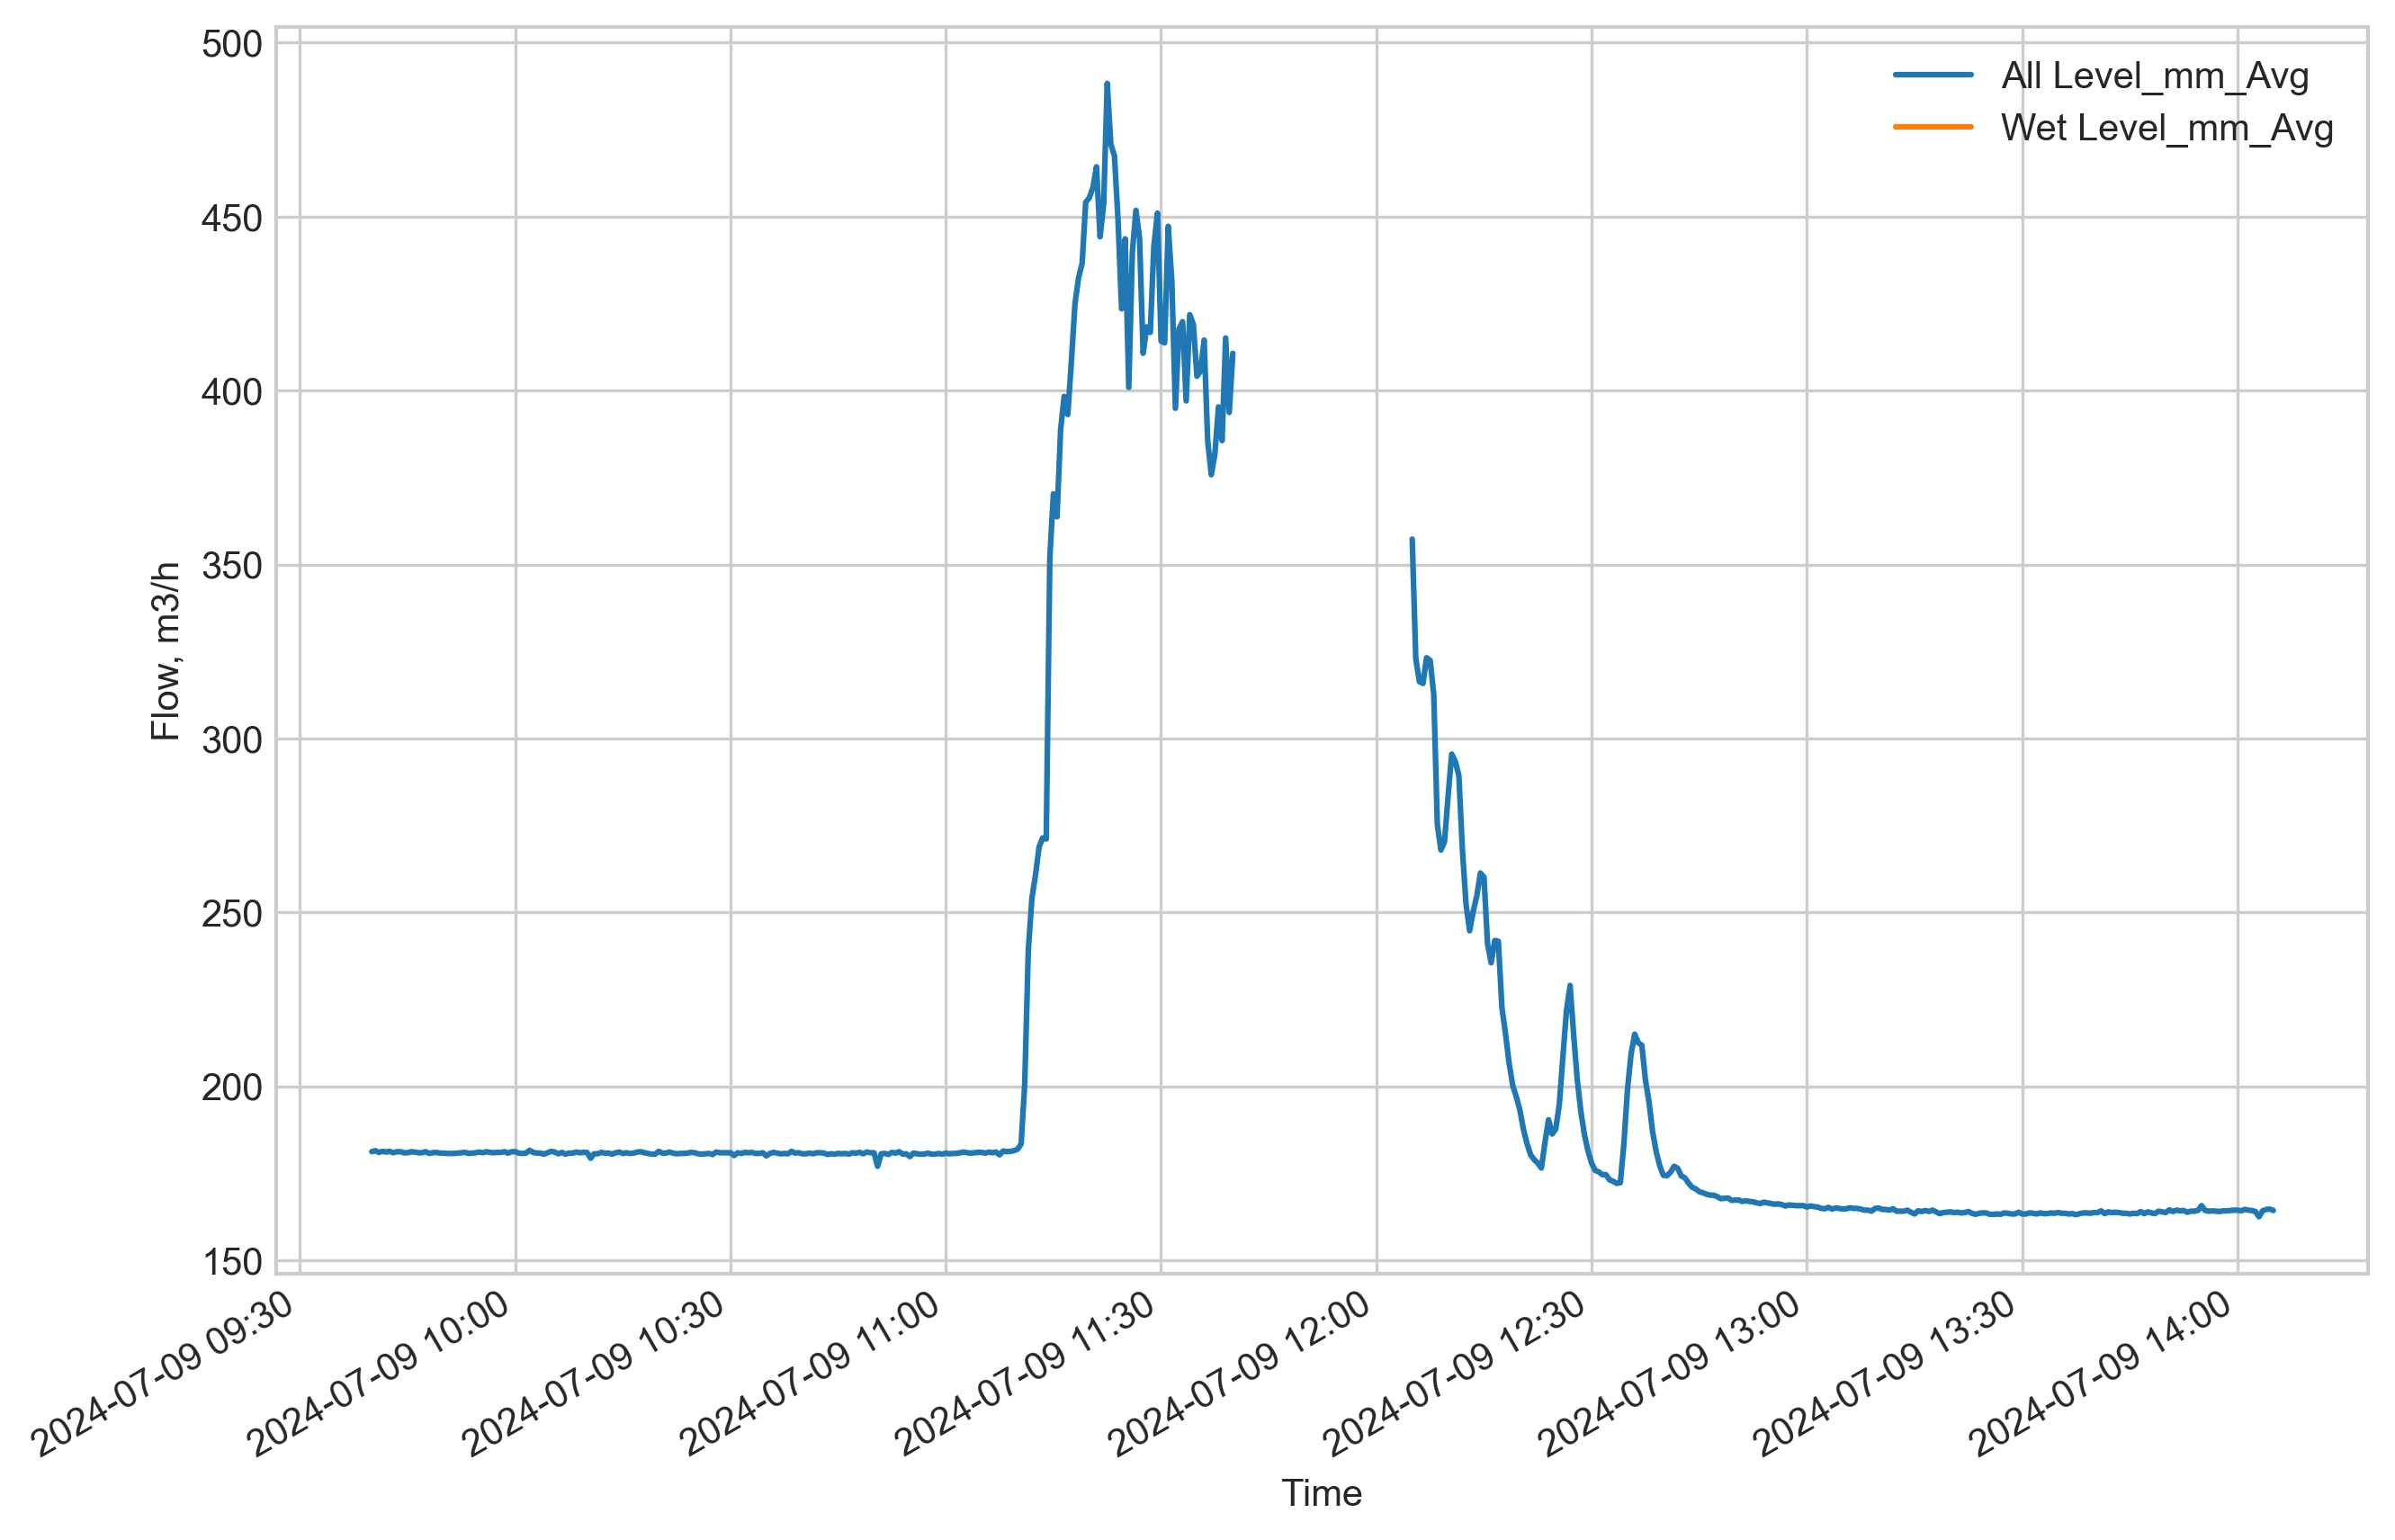

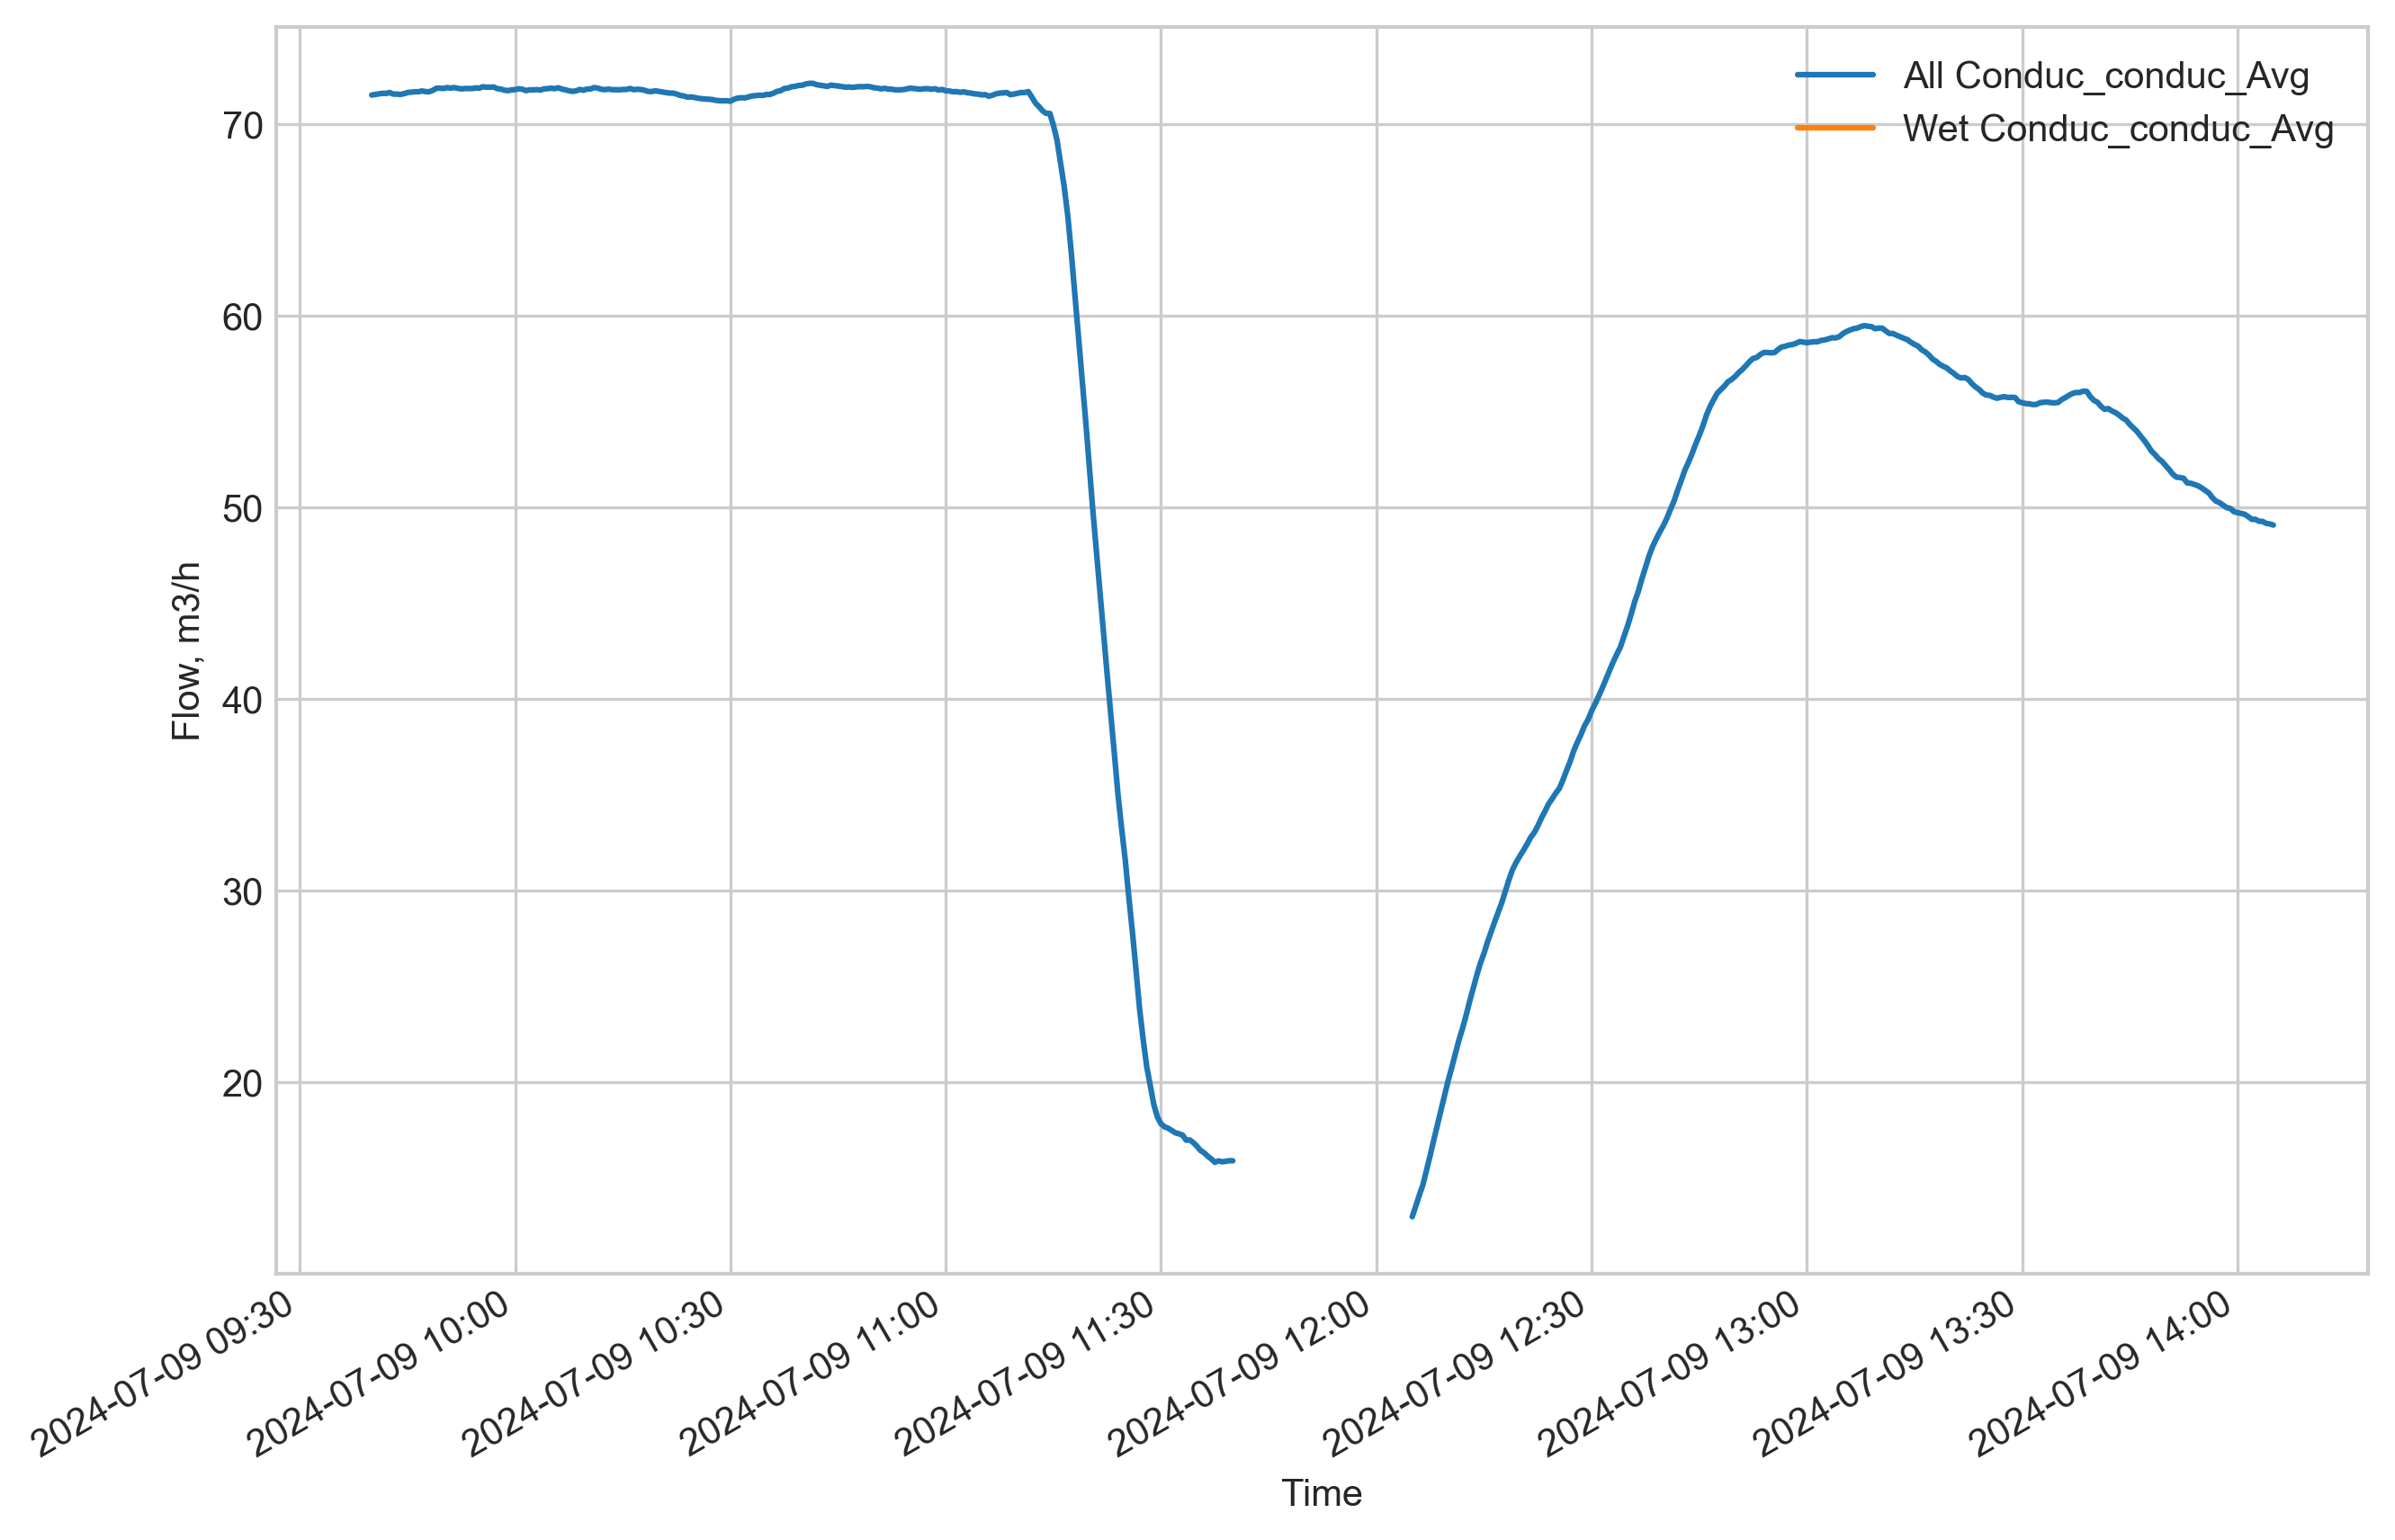

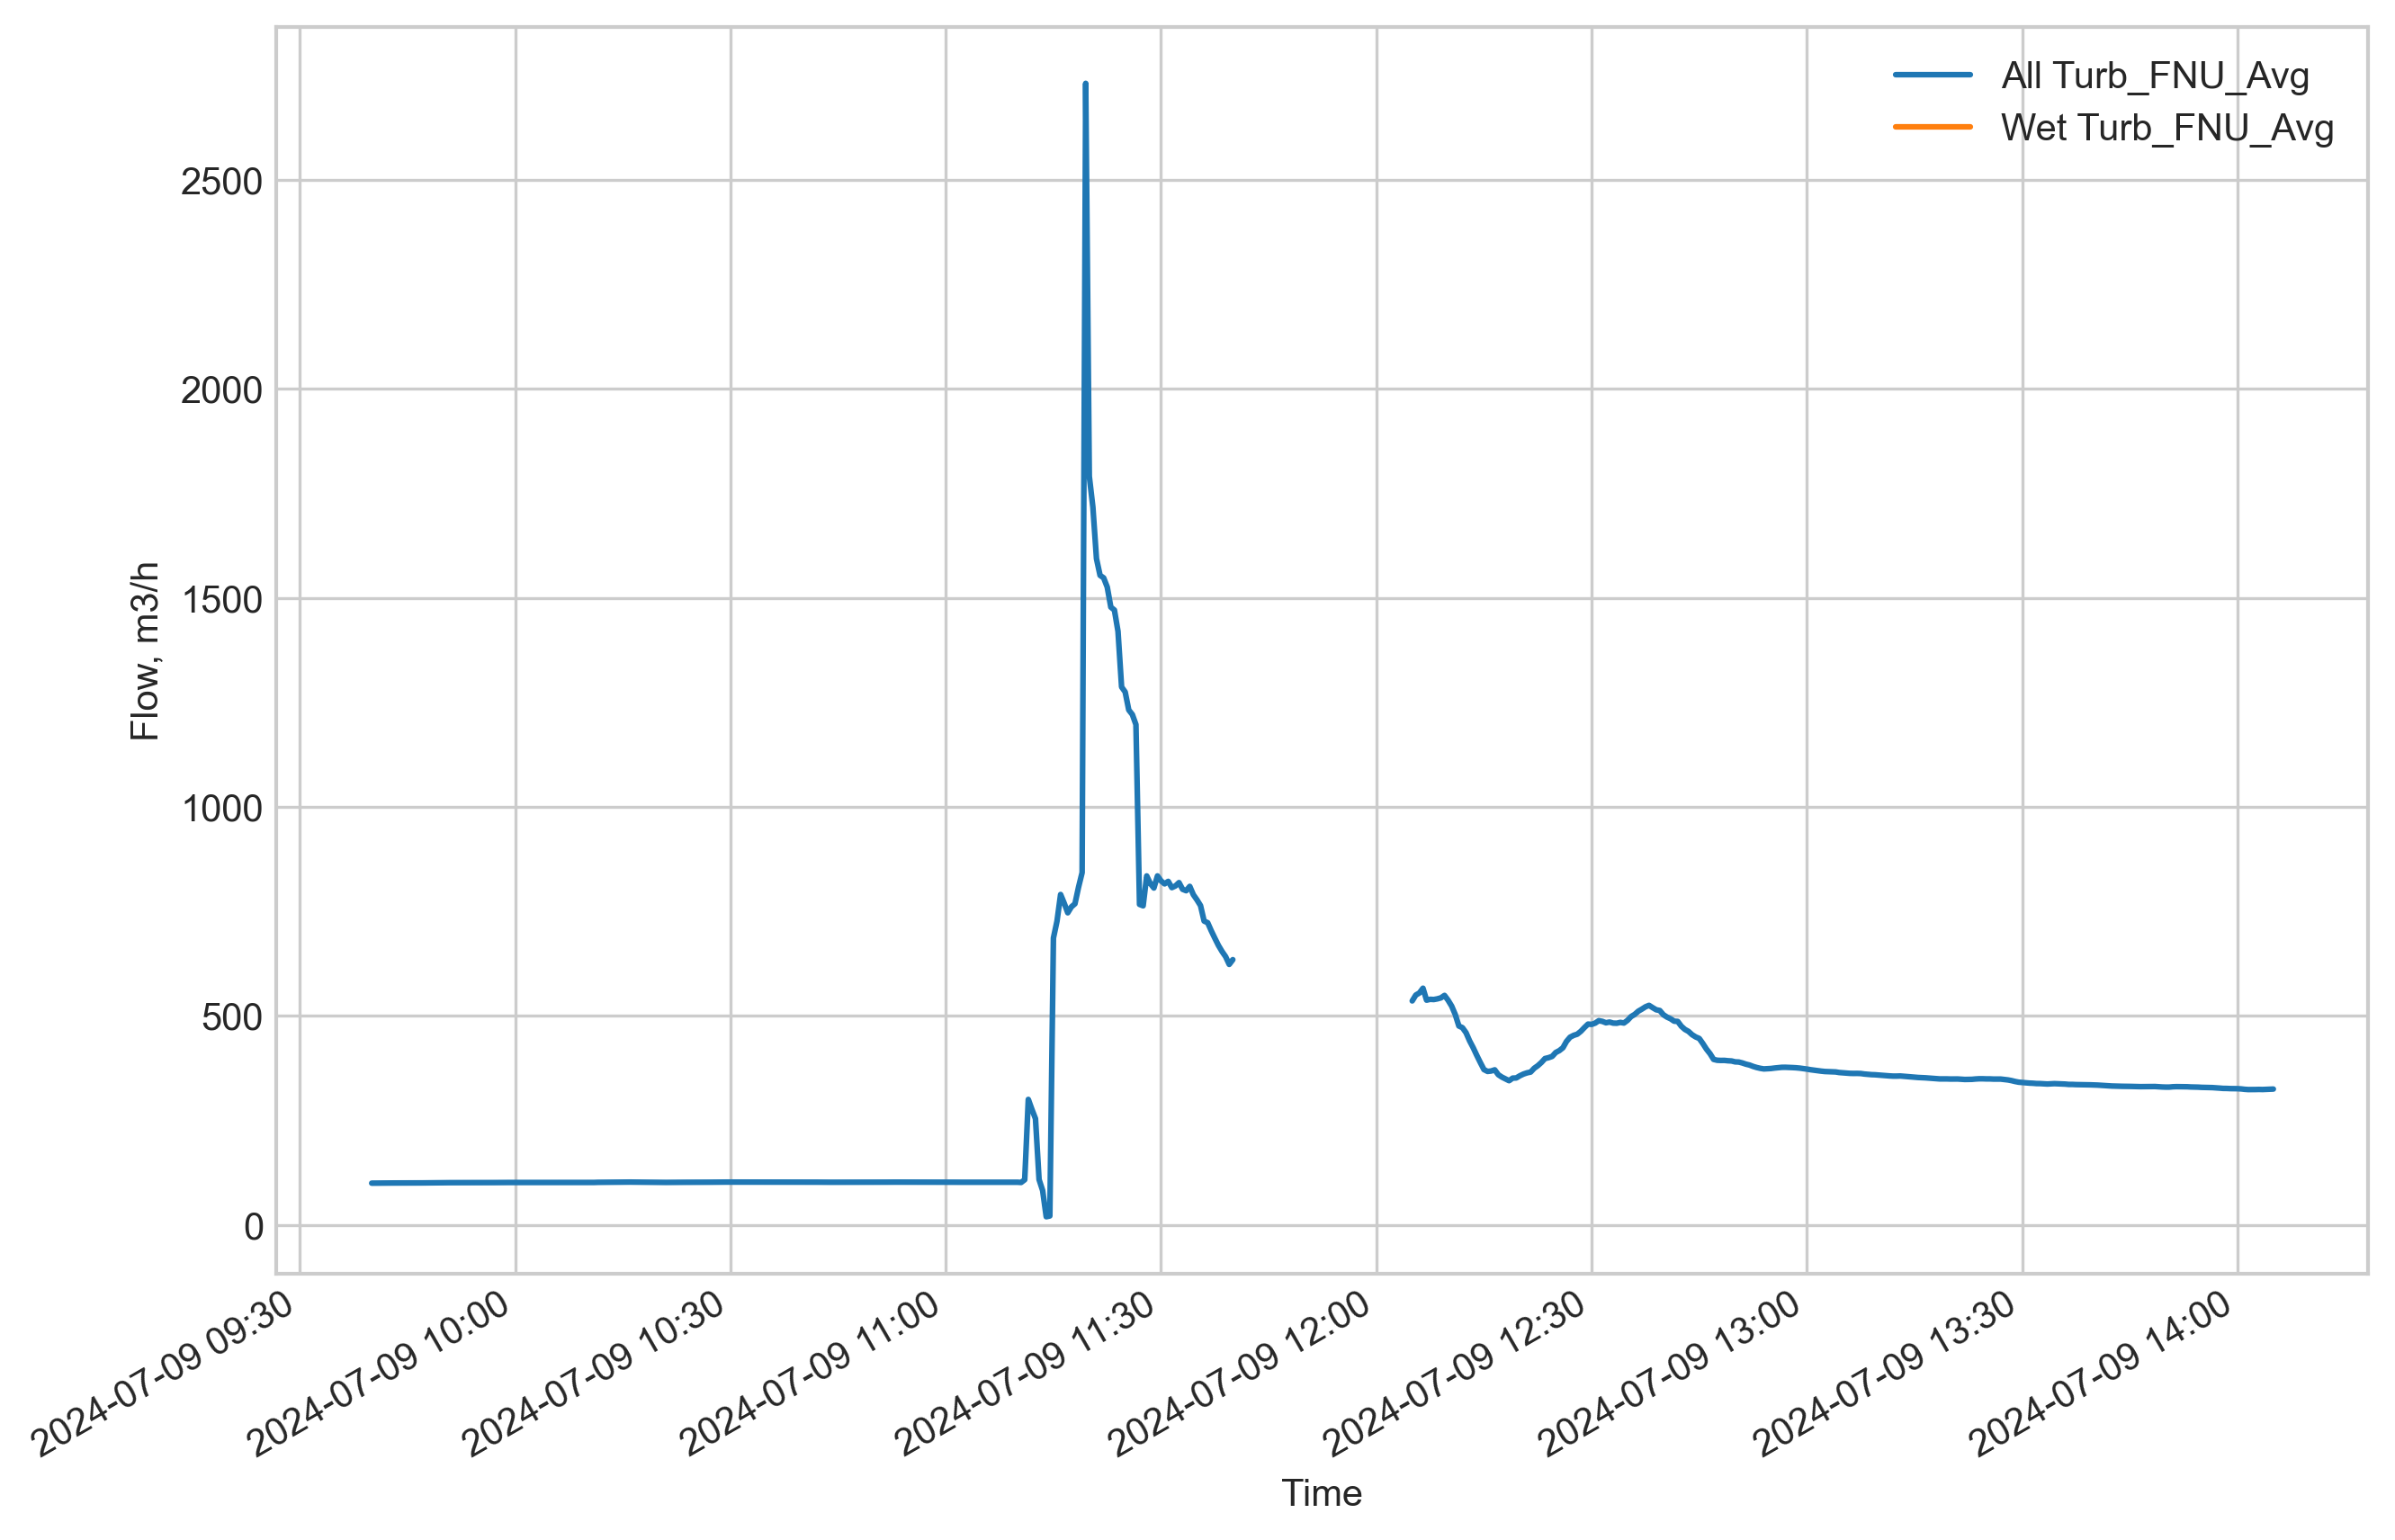

In [31]:
''''''
# Navigating through dataset
# plot_par(data, 'Level_mm_Avg', '2024-05-14 06:00:00', '2024-05-14 09:59:00', 500)
# plot_par(data, 'Turb_temp_Avg', '2024-05-14 06:00:00', '2024-05-14 09:59:00', 30)
# plot_par(data, 'Turb_FNU_Avg', '2024-05-14 06:00:00', '2024-05-14 09:59:00', 8000)

# # Identifying wet-weather flow
# event = identify_wet_flow(data, 'Conduc_conduc_Avg', 0, 0, '2024-07-09 00:00:00', '2024-07-12')
event = identify_wet_flow(data, 'Conduc_conduc_Avg', 0, 0, '2024-07-09 11:40:00', '2024-07-09 12:05:00')
print(event)

plot_wet_event(data, 'Level_mm_Avg', event)
plot_wet_event(data, 'Conduc_conduc_Avg', event)
plot_wet_event(data, 'Turb_FNU_Avg', event)



''''''

In [32]:
events = [

    identify_wet_flow(data, 'Flow_m3h_Avg', 0.009, 0.01, '2021-10-02 04:00', '2021-10-02 13:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.014, 0.35, '2021-10-04 00:00', '2021-10-04 18:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.014, 0.19, '2021-10-04 18:00', '2021-10-05 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.18, 0.017, '2021-10-06 11:30', '2021-10-07 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.017, '2021-10-08 10:40', '2021-10-09 13:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.011, 0.019, '2021-10-14 11:00', '2021-10-14 21:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.013, 0.02, '2021-10-14 22:00', '2021-10-16 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.023, 0.013, '2021-10-16 00:00', '2021-10-18 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.023, 0.01, '2021-10-20 09:00', '2021-10-20 22:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.012, 0.012, '2021-10-21 11:00', '2021-10-21 18:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.01, '2021-10-22 00:00', '2021-10-22 18:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.032, 0.026, '2021-10-24 17:00', '2021-10-25 10:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.027, 0.023, '2021-10-28 03:10', '2021-10-28 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.035, 0.013, '2021-10-30 18:00', '2021-10-31 05:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.019, 0.015, '2021-10-31 15:00', '2021-11-01 06:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.018, 0.025, '2021-11-03 00:00', '2021-11-04 06:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.018, 0.033, '2021-11-04 06:00', '2021-11-05 06:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.05, 0.062, '2021-11-09 10:00', '2021-11-09 20:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.05, 0.062, '2021-11-17 18:00', '2021-11-18 08:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.022, '2022-03-21 09:13', '2022-03-21 17:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.01, '2022-03-25 07:14', '2022-03-25 11:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.01, '2022-03-26 11:22', '2022-03-26 15:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.01, '2022-04-09 16:00', '2022-04-09 23:25'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.01, '2022-04-11 08:12', '2022-04-11 18:20'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.095, 0.01, '2022-04-25 19:55', '2022-04-25 21:40'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.006, 0.015, '2022-05-15 21:40', '2022-05-19 19:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.015, '2022-05-27 00:00', '2022-05-28 06:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.015, '2022-05-28 12:00', '2022-05-28 14:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.015, 0.015, '2022-05-31 21:00', '2022-06-01 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.015, 0.015, '2022-06-01 12:00', '2022-06-02 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.011, 0.005, '2022-06-02 12:00', '2022-06-03 13:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.038, 0.13, '2022-06-14 12:00', '2022-06-15 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.098, 0.13, '2022-06-15 14:00', '2022-06-15 17:50'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.12, 0.17, '2022-06-18 00:00', '2022-06-18 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.138, 0.17, '2022-06-18 12:00', '2022-06-21 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.15, 0.17, '2022-06-21 12:00', '2022-06-23 09:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.15, 0.023, '2022-07-01 12:00', '2022-07-05 03:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.03, 0.05, '2022-07-05 02:00', '2022-07-05 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.03, 0.3, '2022-07-10 02:00', '2022-07-10 15:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.24, 0.27, '2022-07-10 18:00', '2022-07-11 15:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.24, 0.45, '2022-07-14 10:00', '2022-07-14 15:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.35, '2022-07-16 02:58', '2022-07-16 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.025, 0.035, '2022-07-19 00:00', '2022-07-19 20:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.025, 0.035, '2022-07-19 20:00', '2022-07-26 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.03, 0.1, '2022-07-26 12:00', '2022-07-26 22:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.05, 0.06, '2022-07-31 12:00', '2022-08-02 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.065, 0.075, '2022-08-03 00:00', '2022-08-04 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.065, 0.2, '2022-08-04 00:00', '2022-08-07 08:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.02, 0.03, '2022-09-12 00:00', '2022-09-13 18:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.023, 0.035, '2022-09-14 08:00', '2022-09-14 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.04, 0.035, '2022-09-14 12:00', '2022-09-14 20:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.04, 0.035, '2022-09-15 00:00', '2022-09-15 13:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.08, 0.063, '2022-09-15 18:00', '2022-09-16 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.08, 0.09, '2022-09-16 00:00', '2022-09-16 08:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.08, 0.09, '2022-09-16 08:00', '2022-09-16 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.06, 0.06, '2022-09-16 12:00', '2022-09-16 18:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.055, 0.045, '2022-09-16 18:00', '2022-09-16 23:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.055, 0.06, '2022-09-17 00:00', '2022-09-17 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.05, 0.075, '2022-09-17 12:00', '2022-09-18 13:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.07, 0.075, '2022-09-19 00:00', '2022-09-20 13:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.07, 0.075, '2022-09-22 00:00', '2022-09-25 13:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.066, 0.068, '2022-09-25 00:00', '2022-09-30 13:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.066, 0.065, '2022-10-05 00:00', '2022-10-05 22:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.08, 0.08, '2022-10-05 22:00', '2022-10-06 22:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.06, 0.055, '2022-10-07 12:00', '2022-10-08 03:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.06, 0.07, '2022-10-08 12:00', '2022-10-11 16:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.07, 0.07, '2022-10-15 08:00', '2022-10-15 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.07, 0.09, '2022-10-15 18:00', '2022-10-16 02:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.07, 0.1, '2022-10-16 11:00', '2022-10-17 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.07, 0.08, '2022-10-21 00:00', '2022-10-21 10:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.09, 0.13, '2022-10-25 00:00', '2022-10-26 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.1, 0.125, '2022-10-26 00:00', '2022-10-27 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.13, 0.125, '2022-10-27 00:00', '2022-10-28 02:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.13, 0.125, '2022-10-28 08:00', '2022-10-29 02:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.08, '2022-10-29 00:00', '2022-10-30 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.13, '2023-02-27 00:00', '2023-03-20 19:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.08, 0.13, '2023-03-21 09:00', '2023-03-23 19:00'),
    (pd.Timestamp('2023-03-31 12:20'), pd.Timestamp('2023-03-31 16:51')),
    (pd.Timestamp('2023-04-01 11:22'), pd.Timestamp('2023-04-01 16:15')),
    (pd.Timestamp('2023-04-02 10:45'), pd.Timestamp('2023-04-02 17:46')),
    (pd.Timestamp('2023-04-03 10:52'), pd.Timestamp('2023-04-03 18:00')),
    (pd.Timestamp('2023-04-04 08:21'), pd.Timestamp('2023-04-04 17:20')),
    (pd.Timestamp('2023-04-05 10:33'), pd.Timestamp('2023-04-05 17:04')),
    (pd.Timestamp('2023-04-06 11:05'), pd.Timestamp('2023-04-06 15:48')),
    (pd.Timestamp('2023-04-07 14:07'), pd.Timestamp('2023-04-07 16:52')),
    (pd.Timestamp('2023-04-08 11:41'), pd.Timestamp('2023-04-08 12:48')),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.04, '2023-04-21 13:00', '2023-04-23 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.04, '2023-04-25 17:00', '2023-04-25 22:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.07, 0.02, '2023-04-25 22:00', '2023-04-26 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0, 0.06, '2023-04-26 12:00', '2023-04-27 06:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.05, 0.083, '2023-04-27 06:00', '2023-04-27 13:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.08, 0.08, '2023-04-27 13:00', '2023-04-28 08:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.09, '2023-04-28 08:00', '2023-04-29 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.075, 0.075, '2023-04-29 16:00', '2023-04-30 04:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.09, 0.08, '2023-05-03 00:00', '2023-05-03 16:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.07, 0.06, '2023-05-03 20:00', '2023-05-04 04:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.11, 0.06, '2023-05-15 20:00', '2023-05-18 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.055, 0.06, '2023-05-23 10:00', '2023-05-24 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.06, 0.17, '2023-05-28 00:00', '2023-05-28 15:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.13, 0.175, '2023-05-31 00:00', '2023-05-31 23:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.17, 0.21, '2023-06-21 12:00', '2023-06-21 18:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.29, 1.7, '2023-06-21 18:00', '2023-06-23 10:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.29, 1.7, '2023-06-23 12:00', '2023-06-24 15:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.17, 1.48, '2023-06-25 12:00', '2023-07-02 15:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.03, '2023-08-11 12:00', '2023-08-11 23:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.04, 0.4, '2023-08-12 04:00', '2023-08-12 12:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.25, 0.5, '2023-08-13 04:00', '2023-08-14 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.25, 0.45, '2023-08-14 00:00', '2023-08-14 03:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.45, 0.6, '2023-08-14 12:00', '2023-08-15 03:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.45, 0.6, '2023-08-15 12:00', '2023-08-16 20:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.6, 1.8, '2023-08-16 20:00', '2023-08-17 04:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 1, 1.43, '2023-08-22 02:00', '2023-08-22 08:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 1.5, 1.55, '2023-08-25 06:00', '2023-08-27 08:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 1.3, 1.55, '2023-08-28 06:00', '2023-08-28 20:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 1.5, 1.6, '2023-08-28 20:00', '2023-08-30 20:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.82, 1.5, '2023-08-31 16:00', '2023-09-02 01:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.59, 0.89, '2023-09-01 07:00', '2023-09-01 10:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.75, 1.5, '2023-09-02 05:00', '2023-09-02 21:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 1.52, 2, '2023-09-02 21:00', '2023-09-03 07:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 1.6, 0.9, '2023-09-03 08:00', '2023-09-03 18:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.63, 0.69, '2023-09-04 01:00', '2023-09-04 13:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.00001, 0.024, '2023-09-04 20:28', '2023-09-05 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.11, 0.11, '2023-09-12 19:00', '2023-09-13 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.03, '2023-09-28 23:30:00', '2023-09-29 08:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.04, 0.03, '2023-09-30 23:00:00', '2023-10-01 07:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.01, 0.03, '2023-10-01 20:53:45', '2023-10-02 00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.033, 0.052, '2023-10-02 20:00:00', '2023-10-03 04:00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.06, 0.052, '2023-10-04 18:00:00', '2023-10-05 00:00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.02, 0.02, '2023-10-06 16:00:00', '2023-10-07 08:00:00'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.04, 0.06, '2023-10-10 18:00:00', '2023-10-12 16:37'),
    identify_wet_flow(data, 'Flow_m3h_Avg', 0.04, 0.052, '2023-10-14 00:00', '2023-10-15 16:00'),
    identify_wet_flow(data, 'Conduc_conduc_Avg', 103, 115, '2024-04-13 12:00:00', '2024-04-13 16:00'),
    identify_wet_flow(data, 'Conduc_conduc_Avg', 110, 200, '2024-04-13 19:09', '2024-04-14 01:00'),
    identify_wet_flow(data, 'Conduc_conduc_Avg', 110, 231.8, '2024-04-16 21:15', '2024-04-17 21:00'),
    identify_wet_flow(data, 'Level_mm_Avg', 110, 192, '2024-04-23 11:00', '2024-04-23 18:00'),
    identify_wet_flow(data, 'Level_mm_Avg', 191, 193, '2024-04-23 18:00', '2024-04-24 18:00'),
    identify_wet_flow(data, 'Level_mm_Avg', 190.8, 189, '2024-04-24 18:00', '2024-04-25 01:20'),
    identify_wet_flow(data, 'Level_mm_Avg', 187, 189, '2024-04-25 07:30', '2024-04-25 17:30'),
    identify_wet_flow(data, 'Level_mm_Avg', 185, 180, '2024-04-26 18:00', '2024-04-27 17:00'),
    identify_wet_flow(data, 'Level_mm_Avg', 185, 180, '2024-04-28 06:00', '2024-04-28 15:00'),
    identify_wet_flow(data, 'Level_mm_Avg', 185, 180, '2024-04-29 12:00', '2024-04-30 03:00'),
    identify_wet_flow(data, 'Level_mm_Avg', 180, 185, '2024-05-14 07:30:00', '2024-05-14 08:30:00'),
    identify_wet_flow(data, 'Conduc_conduc_Avg', 0, 0, '2024-05-24 15:40:30', '2024-05-24 18:05'),
    identify_wet_flow(data, 'Conduc_conduc_Avg', 0, 0, '2024-06-03 22:08:00', '2024-06-04 04:00'),
    identify_wet_flow(data, 'Conduc_conduc_Avg', 0, 0, '2024-06-09 23:20:00', '2024-06-10 01:40'),
    identify_wet_flow(data, 'Conduc_conduc_Avg', 0, 0, '2024-07-05 00:00:00', '2024-07-05 02:00'),
    identify_wet_flow(data, 'Conduc_conduc_Avg', 0, 0, '2024-07-05 23:38:00', '2024-07-06 03:00:00'),
    identify_wet_flow(data, 'Conduc_conduc_Avg', 0, 0, '2024-07-07 10:00:00', '2024-07-07 16:00:00'),
    identify_wet_flow(data, 'Conduc_conduc_Avg', 0, 0, '2024-07-08 00:45:00', '2024-07-08 04:00:00'),
    identify_wet_flow(data, 'Conduc_conduc_Avg', 0, 0, '2024-07-09 11:10:00', '2024-07-09 12:55:00'),
    identify_wet_flow(data, 'Conduc_conduc_Avg', 0, 0, '2024-07-11 04:00:00', '2024-07-12 00:00:00')

]

# Making a df of wet flow event periods
start_w = []
end_w = []

for i in range(0, len(events)):
    S = events[i][0]
    E = events[i][1]
    start_w.append(S)
    end_w.append(E)

events_df = pd.DataFrame({'Start_w': start_w,
                          'End_w': end_w})

<br>Dry flow<br><br>

In [33]:
# Making a df of dry flow periods - they are in between wet flow events
start_d = []
end_d = []

for i in range(0, len(events_df) - 1):
    S = events_df.End_w[i] + pd.Timedelta('30 sec')
    E = events_df.Start_w[i + 1] - pd.Timedelta('30 sec')
    start_d.append(S)
    end_d.append(E)

# Period before the very first wet flow - NOT USED IN DF
dry_0 = pd.Timestamp('2021-10-01 20:41:00'), events_df.Start_w.loc[0] - pd.Timedelta('30 sec')

# Last dry period
dry_last = events_df.End_w.loc[events_df.index[-1]] + pd.Timedelta('30 sec'), data.index[-1]

# Adding last dry period
start_d.append(dry_last[0])
end_d.append(dry_last[1])

dry_df = pd.DataFrame({'Start_d': start_d,
                       'End_d': end_d})

# Merging wet and dry periods in one df
data_split = pd.concat([events_df, dry_df], axis=1)

In [34]:
data_split.tail(3)

,Start_w,End_w,Start_d,End_d
148,2024-07-08 00:45:00,2024-07-08 04:00:00,2024-07-08 04:00:30,2024-07-09 11:09:30
149,2024-07-09 11:10:00,2024-07-09 12:55:00,2024-07-09 12:55:30,2024-07-11 03:59:30
150,2024-07-11 04:00:00,2024-07-12 00:00:00,2024-07-12 00:00:30,2024-07-15 15:15:30


## Flow correction (level sensor calibration correction)
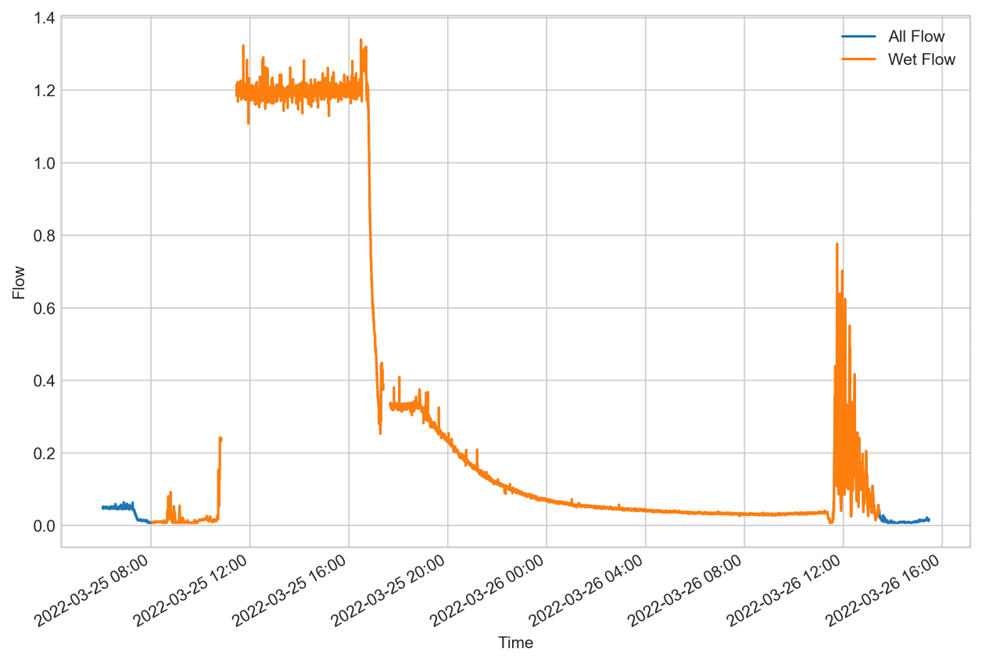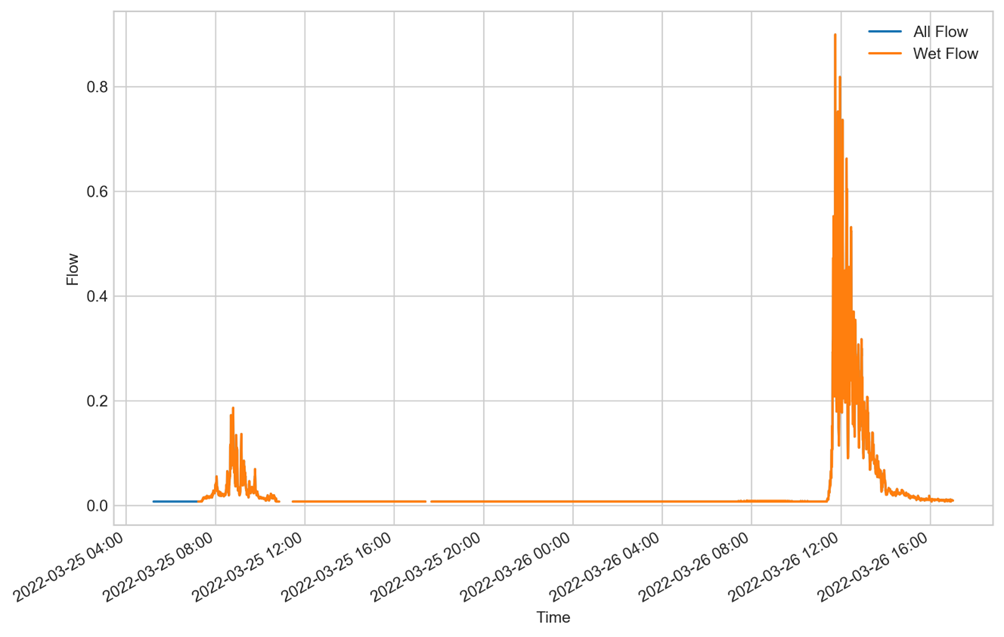!

Emperically derived formula for my specific weir notch:<br>
***Flow_ls = 0.000000001596009 * Weir_head^4 – 0.000000486660527 * Weir_head^3 + 0.000053713000175 * Weir_head^2 – 0.000130677930688 * Weir_head + 0.001898943322345***

Where:

***Weir_head = Level_mm - Weir_bottom***<br>
***Level_mm*** – measured by sensor<br>
***Weir_bottom*** – constant that defines dead volume of the weir<br>

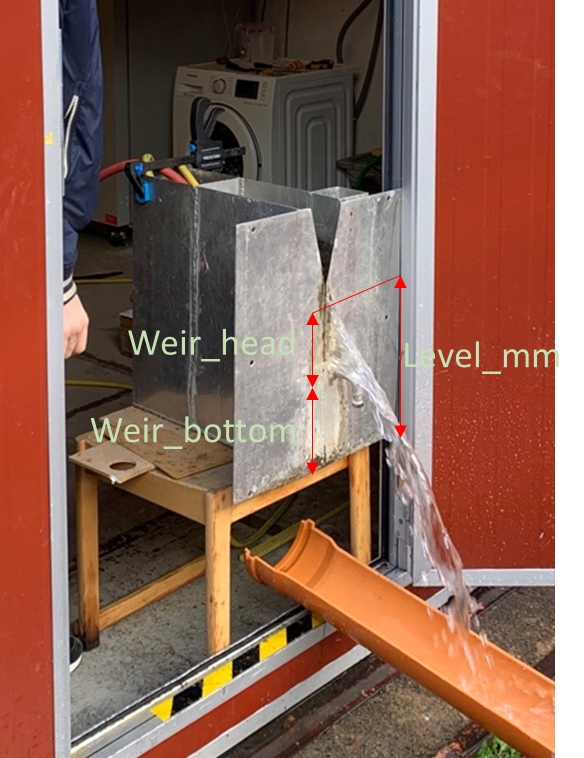


Correcting Level_mm. As we know Weir_head should be 0 between events<br>

0. Clearly identify rain events and dry periods<br>
a. Make a list of all identified rain events<br>
1. Find drift of the level sensor successive dry period, as 1% percentile of all level measurements in order to account for noise
2. For periods with debris – use antecedent dry periods
3. Set it as a weir bottom and correct level in accordance with new bottom for wet and dry periods


### 1. Estimating weir bottom for each event

In [35]:
weir_bottom_1 = []

for i in range(0, len(data_split)):
    # Level for each dry period
    level_period = data.Level_mm_Avg[str(data_split.Start_d[i]):str(data_split.End_d[i])].dropna()
    # Condition for the events without consequent dry period
    if level_period.empty:
        weir_b_1 = weir_bottom_1[-1]
    else:
        # Weir bottom assumed as 1% percentile for the dry period, to account
        # for outliers and reduce noise
        weir_b_1 = np.percentile(level_period, 1)
    # Making an array
    weir_bottom_1.append(weir_b_1)

# Adding weir bottom to the data_split df
data_split['Weir_bottom'] = weir_bottom_1

In [36]:
data_split.head(3)

,Start_w,End_w,Start_d,End_d,Weir_bottom
0,2021-10-02 04:43:00,2021-10-02 12:17:00,2021-10-02 12:17:30,2021-10-04 04:35:30,191.350
1,2021-10-04 04:36:00,2021-10-04 16:14:00,2021-10-04 16:14:30,2021-10-04 17:59:30,240.800
2,2021-10-04 18:00:00,2021-10-05 08:54:00,2021-10-05 08:54:30,2021-10-06 12:27:30,227.451


### 2. Taking weir bottom for the period from antecedent dry period because of debis or there is no dry period after wet-flow period

In [37]:
# Debris
data_split.at[119, 'Weir_bottom'] = data_split.at[118, 'Weir_bottom']
data_split.at[118, 'Weir_bottom'] = data_split.at[117, 'Weir_bottom']
data_split.at[117, 'Weir_bottom'] = data_split.at[116, 'Weir_bottom']
data_split.at[116, 'Weir_bottom'] = data_split.at[115, 'Weir_bottom']
data_split.at[115, 'Weir_bottom'] = data_split.at[114, 'Weir_bottom']
data_split.at[114, 'Weir_bottom'] = data_split.at[113, 'Weir_bottom']
data_split.at[113, 'Weir_bottom'] = data_split.at[112, 'Weir_bottom']
data_split.at[112, 'Weir_bottom'] = data_split.at[111, 'Weir_bottom']
data_split.at[111, 'Weir_bottom'] = data_split.at[110, 'Weir_bottom']
data_split.at[110, 'Weir_bottom'] = data_split.at[109, 'Weir_bottom']
data_split.at[109, 'Weir_bottom'] = data_split.at[108, 'Weir_bottom']
data_split.at[108, 'Weir_bottom'] = data_split.at[107, 'Weir_bottom']
data_split.at[103, 'Weir_bottom'] = data_split.at[102, 'Weir_bottom']
data_split.at[102, 'Weir_bottom'] = data_split.at[101, 'Weir_bottom']
data_split.at[101, 'Weir_bottom'] = data_split.at[100, 'Weir_bottom']

# No dry period after wet period
data_split.at[76, 'Weir_bottom'] = data_split.at[75, 'Weir_bottom']
data_split.at[73, 'Weir_bottom'] = data_split.at[72, 'Weir_bottom']

# Debris
data_split.at[42, 'Weir_bottom'] = data_split.at[46, 'Weir_bottom']
data_split.at[41, 'Weir_bottom'] = data_split.at[40, 'Weir_bottom']
data_split.at[35, 'Weir_bottom'] = data_split.at[34, 'Weir_bottom']
data_split.at[21, 'Weir_bottom'] = data_split.at[20, 'Weir_bottom']
data_split.at[14, 'Weir_bottom'] = data_split.at[13, 'Weir_bottom']
data_split.at[3, 'Weir_bottom'] = data_split.at[2, 'Weir_bottom']
data_split.at[2, 'Weir_bottom'] = data_split.at[1, 'Weir_bottom']
data_split.at[1, 'Weir_bottom'] = data_split.at[0, 'Weir_bottom']

In [38]:
data_split.tail(4)

,Start_w,End_w,Start_d,End_d,Weir_bottom
147,2024-07-07 10:00:00,2024-07-07 16:00:00,2024-07-07 16:00:30,2024-07-08 00:44:30,180.8
148,2024-07-08 00:45:00,2024-07-08 04:00:00,2024-07-08 04:00:30,2024-07-09 11:09:30,180.2
149,2024-07-09 11:10:00,2024-07-09 12:55:00,2024-07-09 12:55:30,2024-07-11 03:59:30,163.7
150,2024-07-11 04:00:00,2024-07-12 00:00:00,2024-07-12 00:00:30,2024-07-15 15:15:30,136.4


### 3. Correcting level, and then using it together with estimated weir_bottom to calculate flow

In [39]:
new_level = []
new_flow_ls = []
new_flow_m3h = []

for i in range(0, len(data_split)):
    weir_bottom = data_split['Weir_bottom'][i]
    level_wet = data.Level_mm_Avg[str(data_split.Start_w[i]):str(data_split.End_w[i])]
    level_dry = data.Level_mm_Avg[str(data_split.Start_d[i]):str(data_split.End_d[i])]
    # Replacing level bellow threshold
    new_l_wet = np.where(level_wet < weir_bottom, weir_bottom, level_wet)
    # Correcting dry flow when debris
    if i not in [1, 2, 13, 34, 40, 46, 99, 100, 101, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117]:
        new_l_dry = np.where(level_dry < weir_bottom, weir_bottom, level_dry)
    else:
        new_l_dry = level_dry

        # Create a mask to identify non-NaN values
        mask = ~np.isnan(new_l_dry)

        # Make it equal to the first value of the next wet period
        new_l_dry[mask] = data_split.Weir_bottom[i]
    
    # Merging wet and dry flow
    new_l = np.concatenate((new_l_wet, new_l_dry))
    
    # Calculating weir head with new flow
    weir_head = new_l - weir_bottom
    # Calculating new flow l/s - equation for the weir notch
    flow_ls = 0.000000001596009 * weir_head ** 4 - 0.000000486660527 * weir_head ** 3 + 0.000053713000175 * weir_head\
        ** 2 - 0.000130677930688 * weir_head + 0.001898943322345
    flow_m3h = flow_ls * 3.6

    # Transforming arrays into pd.Series
    new_l = pd.Series(new_l, index=data[str(data_split.Start_w[i]):str(data_split.End_d[i])].index)
    flow_ls = pd.Series(flow_ls, index=data[str(data_split.Start_w[i]):str(data_split.End_d[i])].index)
    flow_m3h = pd.Series(flow_m3h, index=data[str(data_split.Start_w[i]):str(data_split.End_d[i])].index)

    # Merging periods
    new_level.append(new_l)
    new_flow_ls.append(flow_ls)
    new_flow_m3h.append(flow_m3h)

# Making one dataset
new_level = pd.concat(new_level)
new_flow_ls = pd.concat(new_flow_ls)
new_flow_m3h = pd.concat(new_flow_m3h)

# Adding first dry period, assuming that there was no much data drift
new_level = pd.concat([data[str(dry_0[0]):str(dry_0[1])].Level_mm_Avg, new_level], axis=0)
new_flow_ls = pd.concat([data[str(dry_0[0]):str(dry_0[1])].Flow_ls_Avg, new_flow_ls], axis=0)
new_flow_m3h = pd.concat([data[str(dry_0[0]):str(dry_0[1])].Flow_m3h_Avg, new_flow_m3h], axis=0)

# Making new df for corrected flow
corr_flow = pd.DataFrame({'Level_mm_Avg': new_level,
                          'Flow_ls_Avg': new_flow_ls.round(3),
                          'Flow_m3h_Avg': new_flow_m3h.round(3)}, index=new_level.index)

# Adding corrected flow to the data df
# Dropping recorded level and flow
data_corr = data.drop(columns=['Level_mm_Avg', 'Flow_ls_Avg', 'Flow_m3h_Avg'])
# Adding corrected
data_corr = pd.concat([data_corr, corr_flow], axis=1)

In [40]:
data_corr.head(3)

,RECORD,Conduc_temp_Avg,Conduc_conduc_Avg,DO_temp_Avg,DO_mg_L_Avg,Turb_temp_Avg,Turb_FNU_Avg,pH_temp_Avg,pH_pH_Avg,Level_mm_Avg,Flow_ls_Avg,Flow_m3h_Avg
TIMESTAMP,,,,,,,,,,,,
2021-10-01 20:41:00,1.5,9.610000,416.200000,9.95,8.985,9.78,548.500000,10.04,7.374000,196.200000,0.002,0.007
2021-10-01 20:41:30,3.5,9.610000,416.300000,9.95,8.985,9.78,548.350000,10.04,7.373000,195.750000,0.002,0.007
2021-10-01 20:42:00,6.0,9.613333,416.433333,9.95,8.980,9.78,550.666667,10.04,7.374333,196.366667,0.002,0.007


## Merging events that have less than 6 h between them 

We decided that in order to define an event there should be an antecedent period of at least 6h of dry flow

Merging:

In [41]:
data_split

,Start_w,End_w,Start_d,End_d,Weir_bottom
0,2021-10-02 04:43:00,2021-10-02 12:17:00,2021-10-02 12:17:30,2021-10-04 04:35:30,191.350000
1,2021-10-04 04:36:00,2021-10-04 16:14:00,2021-10-04 16:14:30,2021-10-04 17:59:30,191.350000
2,2021-10-04 18:00:00,2021-10-05 08:54:00,2021-10-05 08:54:30,2021-10-06 12:27:30,240.800000
3,2021-10-06 12:28:00,2021-10-07 09:01:30,2021-10-07 09:02:00,2021-10-08 10:46:00,227.451000
4,2021-10-08 10:46:30,2021-10-08 12:48:30,2021-10-08 12:49:00,2021-10-14 12:01:00,192.600000
5,2021-10-14 12:01:30,2021-10-14 19:29:30,2021-10-14 19:30:00,2021-10-14 23:12:30,200.322500
6,2021-10-14 23:13:00,2021-10-15 22:01:00,2021-10-15 22:01:30,2021-10-16 02:03:30,203.628000
7,2021-10-16 02:04:00,2021-10-17 17:39:00,2021-10-17 17:39:30,2021-10-20 09:58:00,194.137667
8,2021-10-20 09:58:30,2021-10-20 20:56:30,2021-10-20 20:57:00,2021-10-21 12:18:00,193.921000
9,2021-10-21 12:18:30,2021-10-21 17:31:00,2021-10-21 17:31:30,2021-10-22 02:05:30,193.100000


In [42]:
# This code will run an error if the last dry period in th edataset is shorter than 6 h

# Calculating duration of every dry period in data_split
duration_dry = data_split.End_d - data_split.Start_d
# Dry periods that are shorter than 6 hours
dry_less_than_6_h = duration_dry[duration_dry < pd.Timedelta(hours=6)]

used_i = []
st_i = []
end_i = []

# Identifying start and end of wet periods that comprise one precipitation event
for i in range(len(dry_less_than_6_h)):
    # Indexes of dry periods shorter than 6 hours
    index_dry = dry_less_than_6_h.index

    # Original i
    original_i = i
    # Checking if this "i" was accounted for in the previous loop
    if i in used_i:
        continue

    # Index start
    st_ind = index_dry[i]
    # Start of the event
    st = data_split.loc[st_ind].Start_w

    # Loop to check if the next "i" also belongs to the same event
    while index_dry[i] + 1 in index_dry:
        i += 1
        # Logging "i"'s that has already been used
        used_i.append(i)

    # Index end
    end_ind = index_dry[i] + 1
    # End of the event
    end = data_split.loc[end_ind].End_w

    st_i.append(st_ind)
    end_i.append(end_ind)

    # Plotting all merged events
    # plot_wet_event(corr_flow, 'Flow_m3h_Avg', [st, end])
    # plt.gca().set_title(f'Events {index_dry[original_i]} through {index_dry[i]+1}\n', fontsize = 16)

<br>Restructuring and reindexing data_split df in accordance with new merged events and adding a column indicating which events were merged<br><br>

In [43]:
# Making a df of precipitation events and dry periods
data_split_event = data_split.copy()
# Dropping weir_bottom column, as not true for combined periods and not needed
data_split_event = data_split_event.drop(columns='Weir_bottom')

# Adding new starting time to periods to combine them
for i in range(len(st_i)):
    data_split_event.loc[end_i[i], 'Start_w'] = data_split_event.loc[st_i[i], 'Start_w']

# Dropping combined periods
# Identifying indexes: start through the end, end index not included
drop_i = []
for i in range(len(st_i)):
    drop_ind = np.array(data_split_event[st_i[i]:end_i[i]].index)
    drop_i.append(drop_ind)

# Making one array
drop_i = np.concatenate(drop_i)
# Dropping indexes
data_split_event = data_split_event.drop(drop_i)

# Adding column of the event duration
data_split_event['Event_duration'] = data_split_event.End_w - data_split_event.Start_w
data_split_event['Dry_period_duration'] = data_split_event.End_d - data_split_event.Start_d

# Adding a column to mark merged events
data_split_event['Merged_event'] = ' '

# Using indexes of the events that have been merged - end_i
for i in end_i:
    data_split_event.loc[i, 'Merged_event'] = '+'

# Resetting index
data_split_event = data_split_event.reset_index(drop=True)

# Here manually add dry periods, as some of the automatically calculated include gaps - refer to SMHI (would be nice to automate)
data_split_event.loc[21, 'Dry_period_duration'] = pd.Timedelta(minutes=388*60)
data_split_event.loc[44, 'Dry_period_duration'] = pd.Timedelta(minutes=307*60)
data_split_event.loc[90, 'Dry_period_duration'] = pd.Timedelta(minutes=32*60)
data_split_event.loc[107, 'Dry_period_duration'] = pd.Timedelta(minutes=25*60)
data_split_event.loc[127, 'Dry_period_duration'] = pd.Timedelta(minutes=30*60) # Here I have data about when the rain was, I just excluded that period from the dataset

In [44]:
data_split_event.tail(3)

,Start_w,End_w,Start_d,End_d,Event_duration,Dry_period_duration,Merged_event
131,2024-07-08 00:45:00,2024-07-08 04:00:00,2024-07-08 04:00:30,2024-07-09 11:09:30,0 days 03:15:00,1 days 07:09:00,
132,2024-07-09 11:10:00,2024-07-09 12:55:00,2024-07-09 12:55:30,2024-07-11 03:59:30,0 days 01:45:00,1 days 15:04:00,
133,2024-07-11 04:00:00,2024-07-12 00:00:00,2024-07-12 00:00:30,2024-07-15 15:15:30,0 days 20:00:00,3 days 15:15:00,


In [45]:
# Wet and dry flows dfs
flow_wet = []
# Adding the very first period of dry flow
flow_dry_0 = data['Flow_m3h_Avg'][str(dry_0[0]):str(dry_0[1])]
flow_dry = [flow_dry_0]

for i in range(0, len(data_split_event)):
    flow_w = data_corr['Flow_m3h_Avg'][str(data_split_event.Start_w[i]):str(data_split_event.End_w[i])]
    flow_d = data_corr['Flow_m3h_Avg'][str(data_split_event.Start_d[i]):str(data_split_event.End_d[i])]

    flow_wet.append(flow_w)
    flow_dry.append(flow_d)

# Concatenating lists to make two pd.Series
flow_wet = pd.concat(flow_wet)
flow_dry = pd.concat(flow_dry)

# Converting to dfs
flow_wet = pd.DataFrame({'Flow_m3h_Avg': flow_wet})
flow_dry = pd.DataFrame({'Flow_m3h_Avg': flow_dry})

# Find gaps between wet weather events
gaps_flow_wet = find_nan_periods(flow_wet, new_interval)
gaps_flow_dry = find_nan_periods(flow_dry, new_interval)

# Putting NaN values in to separate wet weather events on the graph
for i in range(0, len(gaps_flow_wet)):
    flow_wet = replace_values_with_nan(flow_wet, gaps_flow_wet.Start[i], gaps_flow_wet.End[i])

for i in range(0, len(gaps_flow_dry)):
    flow_dry = replace_values_with_nan(flow_dry, gaps_flow_dry.Start[i], gaps_flow_dry.End[i])

In [46]:
len(flow_dry)+len(flow_wet)

2424478

In [47]:
len(data)

2424478

### Plotting data distribution after correction

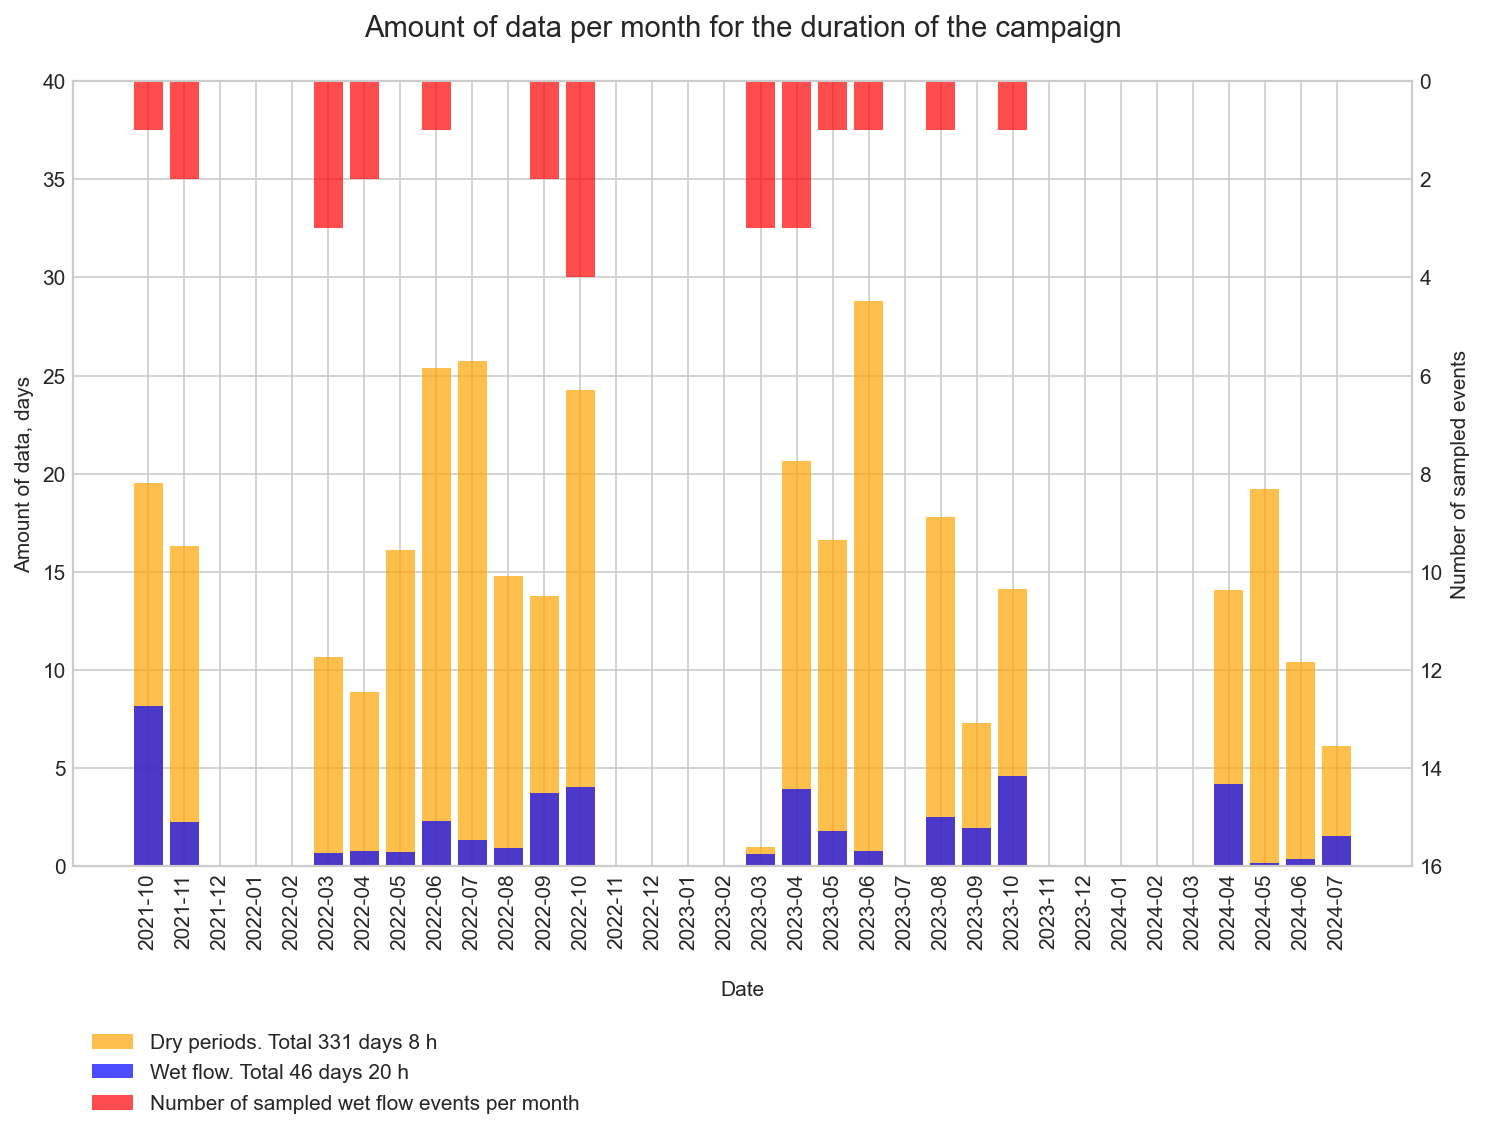

In [48]:
plot_m_corr(flow_wet.dropna(), flow_dry.dropna(), sampled_events_month)

Checking balances again

In [49]:
dataset_len_reduction(data_corr)

Monitoring campaign length: 2153775 datapoints / 747 days 20:09:36
Current dataset length (non-NaN values): 818619 datapoints / 284 days 05:45:36


### Graph of frequency of datapoints occuring in the range of parameter
<div class="alert-warning">
    Move it to the end, after making a dataset
</div> 

In order to make it nice for a few parameters at once use sns.pairplot: https://www.youtube.com/watch?v=-vHQub0NXI4&list=PLQY2H8rRoyvyK5aEDAI3wUUqC_F0oEroL&index=6&ab_channel=TensorFlow

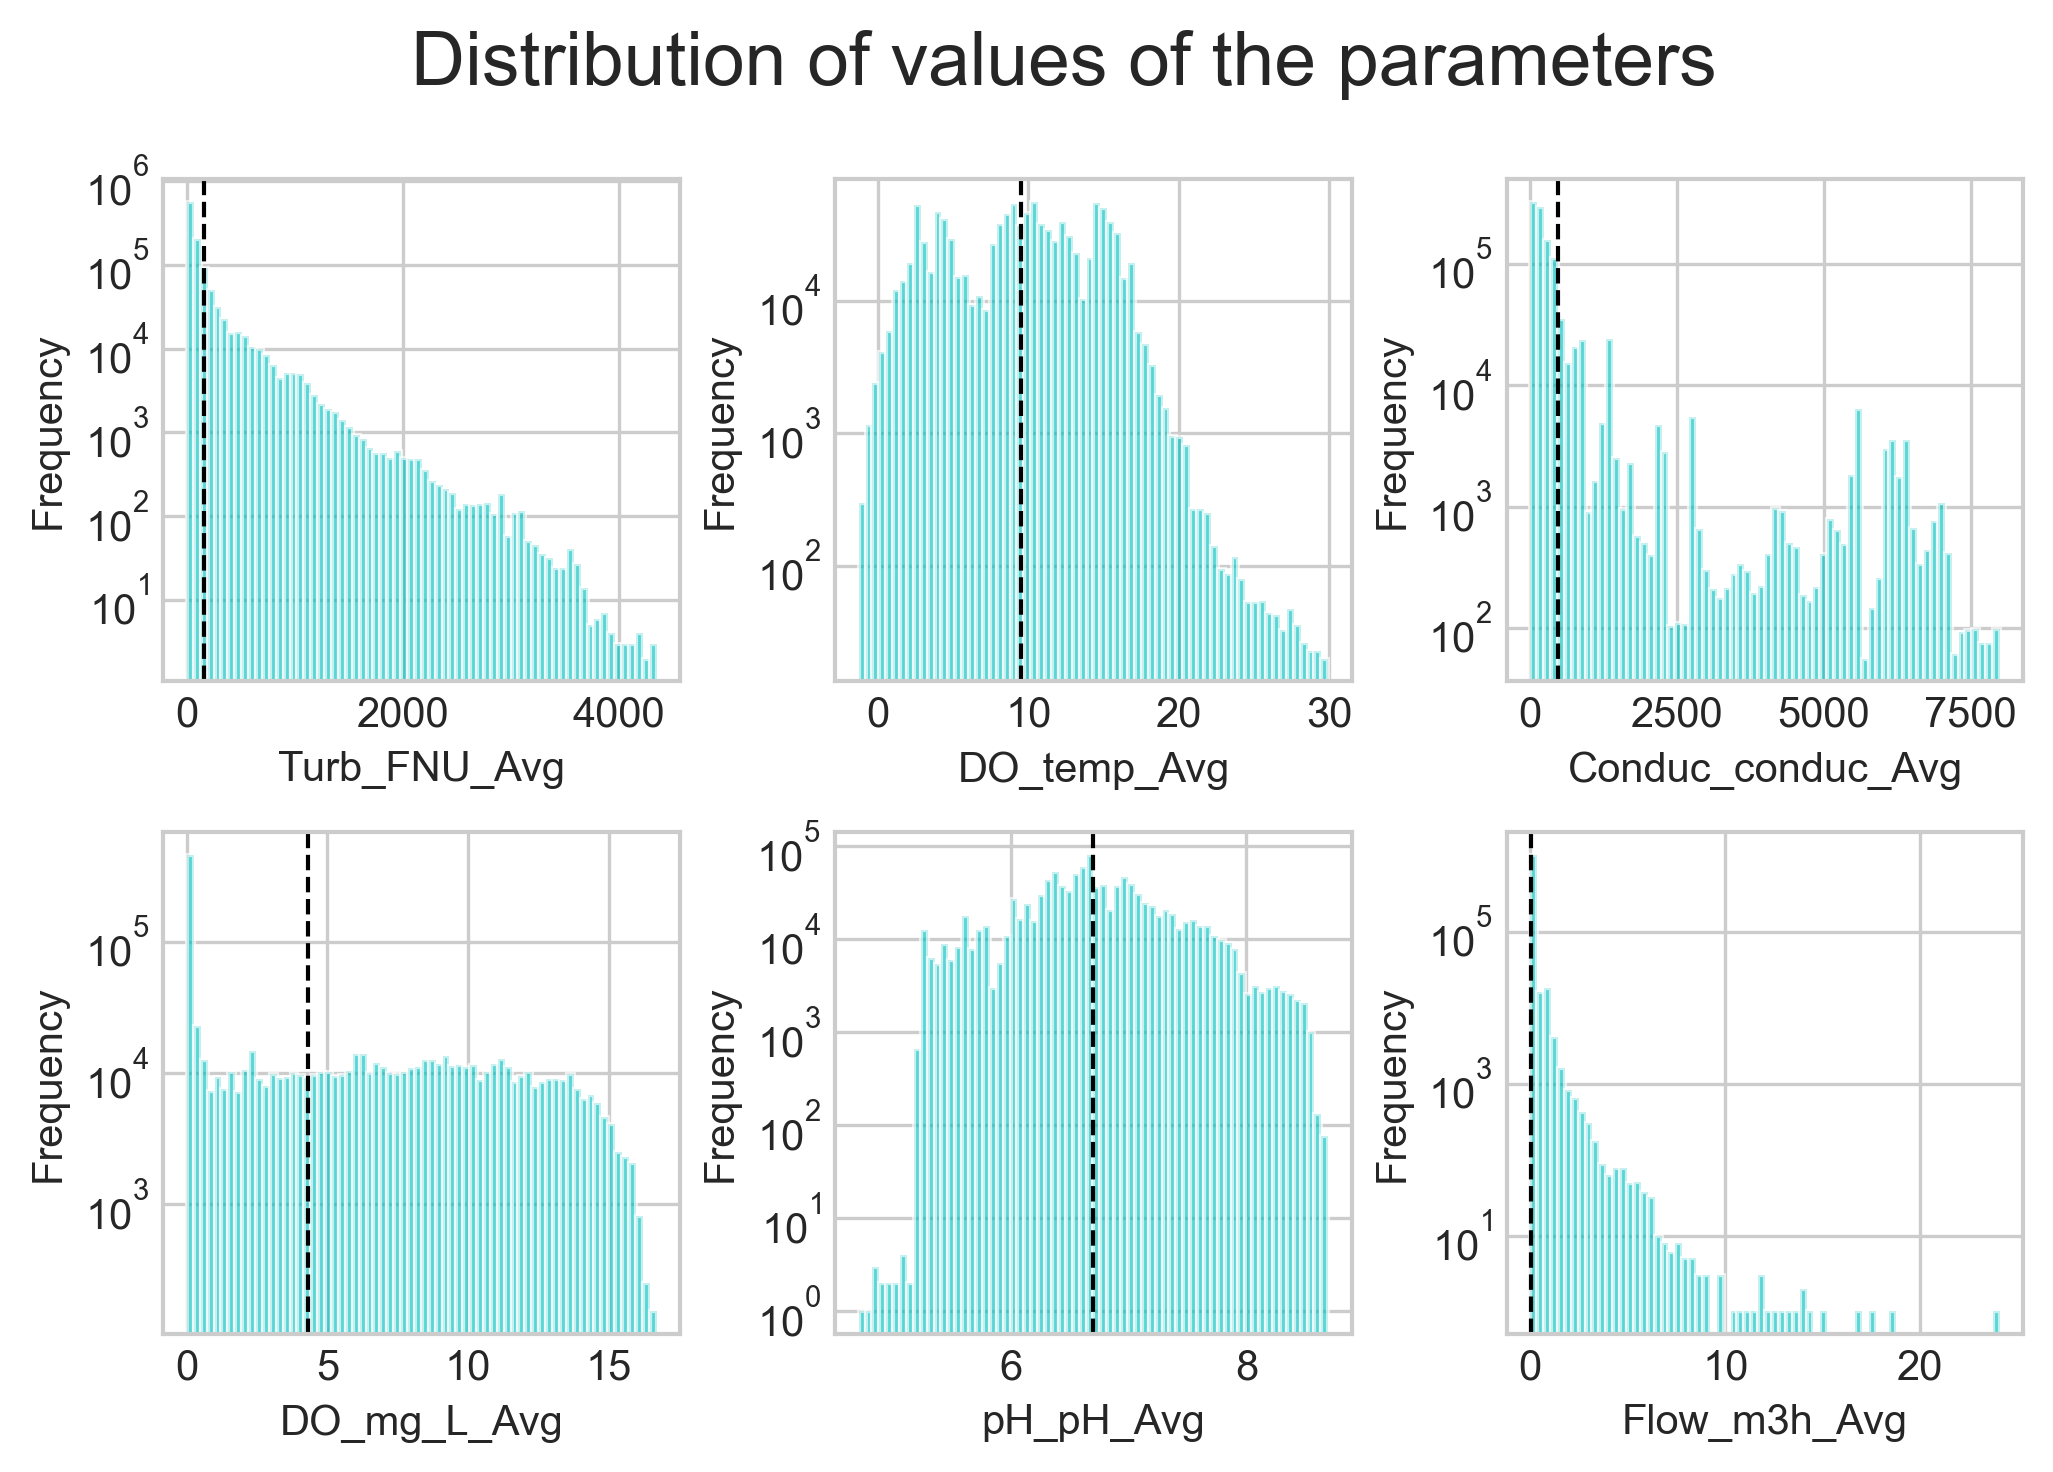

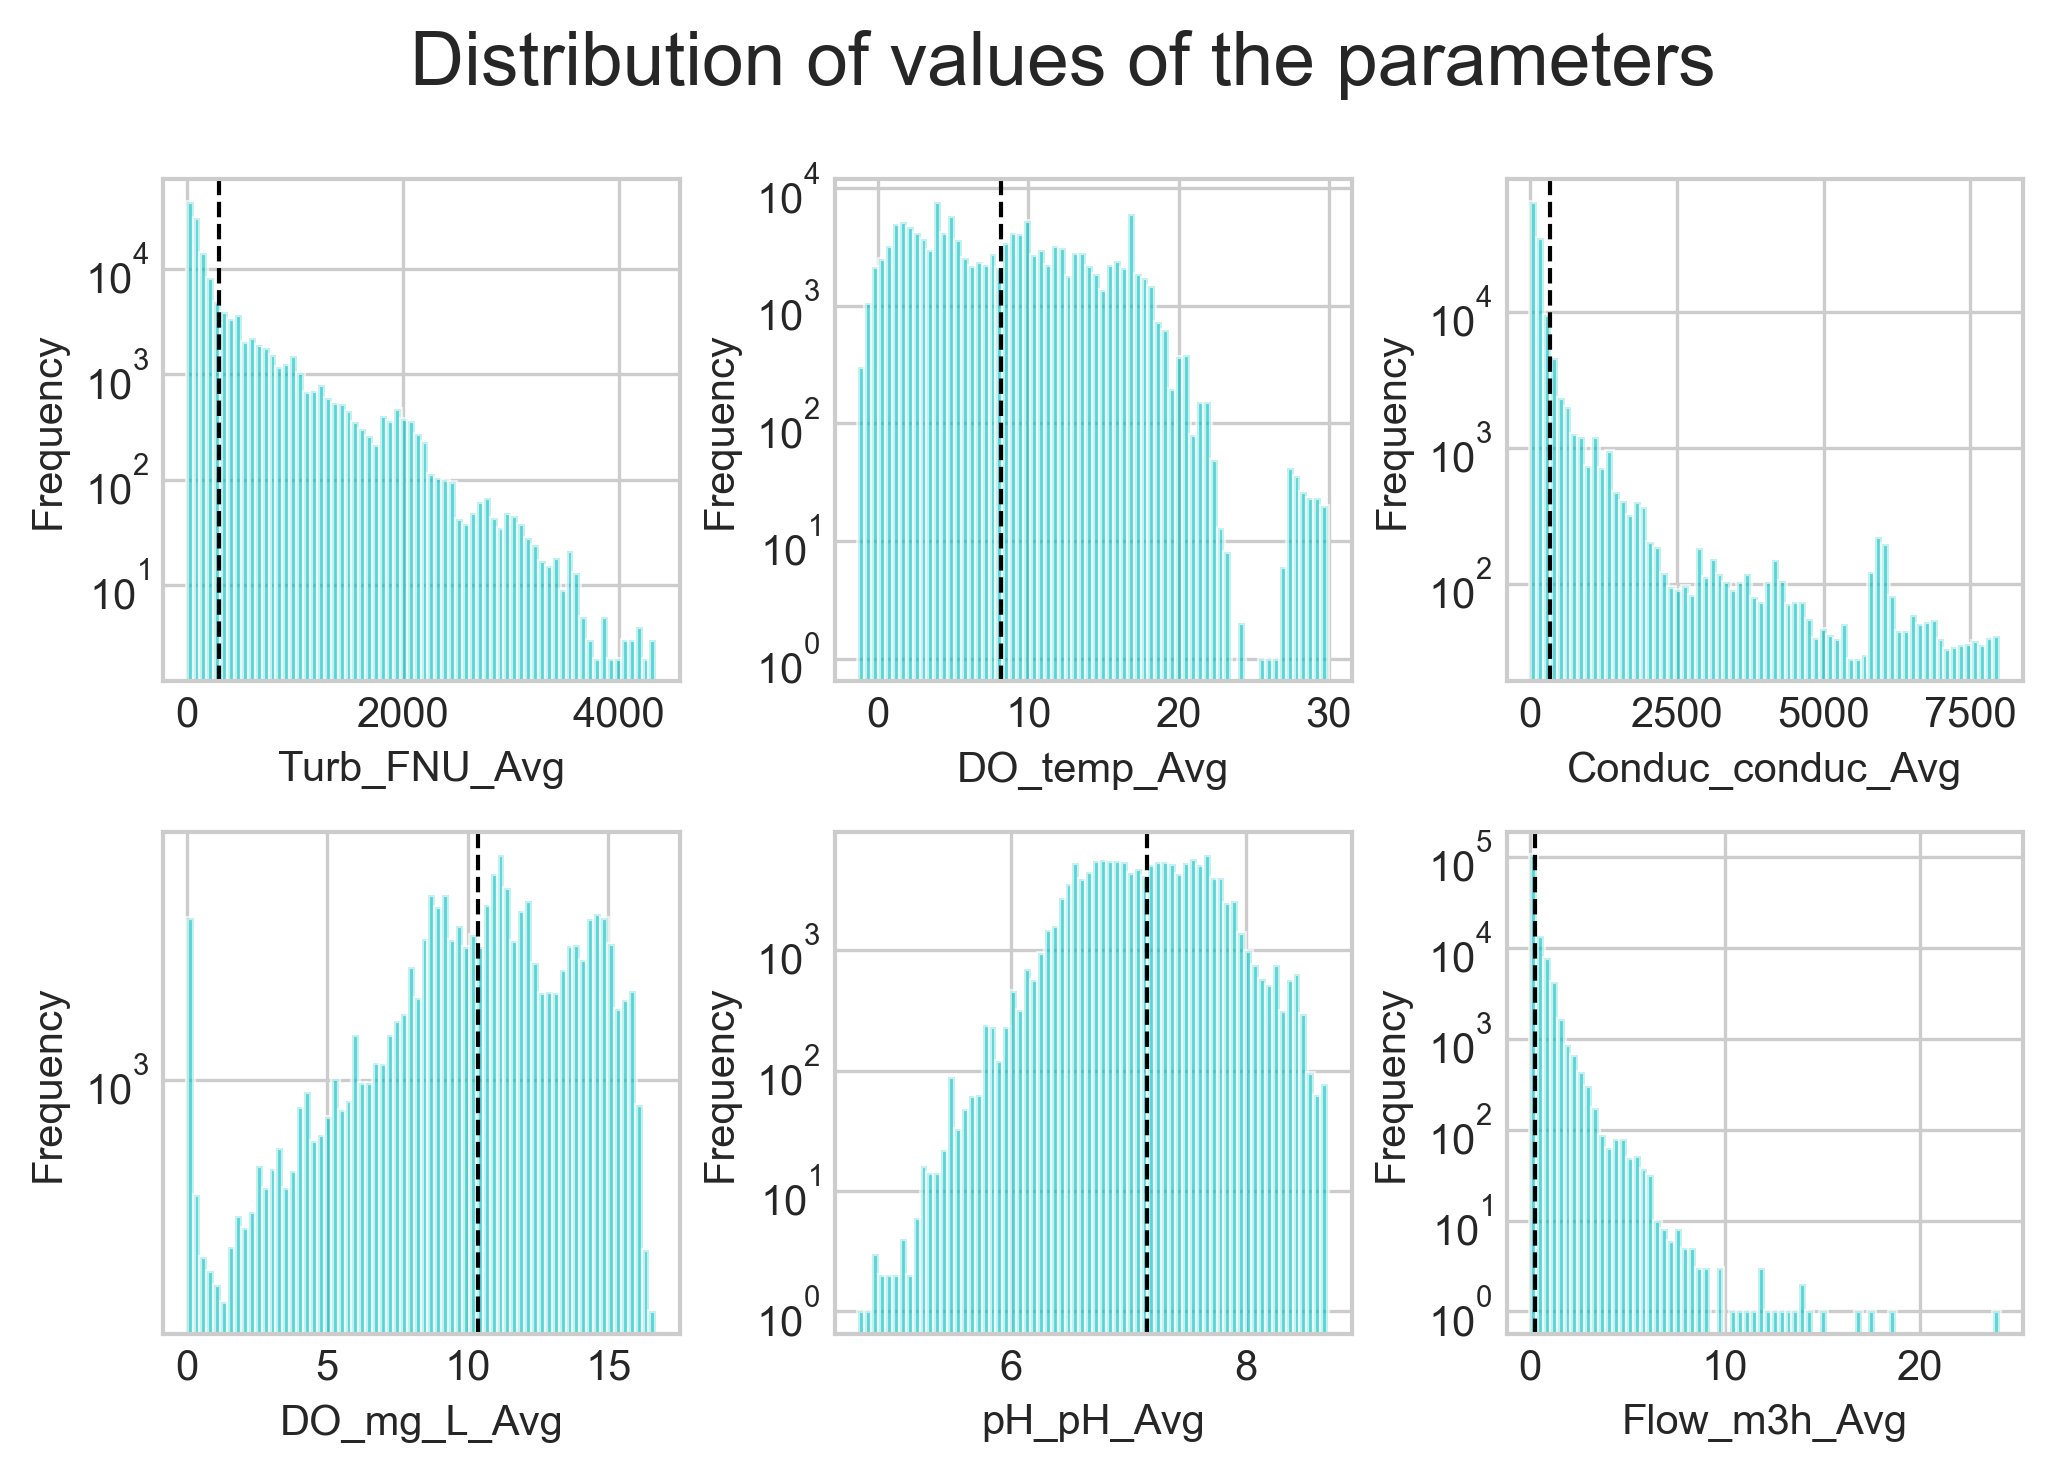

In [50]:
# All data
graph_par_range(data_corr)

# Only for wet flow periods
mask = data_corr.index.isin(flow_wet.index)
data_wet = data_corr[mask]
graph_par_range(data_wet)

# Making datasets for ML
This part includes a few steps:
1. Making a table of events and different corresponding markers that are used for informed decision making, in order to see which events will be included into the final selection
2. Automatic procedures using markers to make a selection
3. Manual check
4. Distribution of the events included into the selection (total dataset) between TRAIN/VAL/TEST datasets

## 1.1 Marking precipitation events that were sampled
I do it through:
1. identifying hours of every day when samples were taken from ***sd*** DataFrame
2. identifying every hour of every day when there was precipitation event from ***data_split_event***
3. comparing these two series
4. adding indexes of the elements from first series to mark event numbers

In [51]:
# Number of the event
sample_s = []
for i in range(len(sd)):
    sample_st = sd[i].Start.groupby(sd[i].Start.dt.strftime('%Y-%m-%d %H').values).first().index.values
    sample_st = pd.Series(sample_st, index = [i]*len(sample_st), dtype = str)
    sample_s.append(sample_st)
# Turn it into series of strings
sample_s = pd.concat(sample_s)


# Making a list of days when it was wet and splitting it by events
# in data_split_events
wet_events_day = []
for i in range(len(data_split_event)):
    st = data_split_event.at[i, 'Start_w']
    end = data_split_event.at[i, 'End_w']
    # Grouping values by day
    wet_events_d = flow_wet[st:end].groupby(flow_wet[st:end].index.strftime('%Y-%m-%d %H')).first().index.values
    wet_events_day.append(wet_events_d)
wet_events_day = pd.Series(wet_events_day)
# Changing dtype of the days to str
for i in range(len(wet_events_day)):
    wet_events_day[i] = [str(date) for date in wet_events_day[i]]


# Comparing two lists to see where I sampled
sampled_indices = []
indexes_of_found = []
for i in range(len(data_split_event)):
    # Use .isin() to check for elements in list1 and get their indexes in list2
    indexes_of_found_elements = (sample_s[sample_s.isin(pd.Series(wet_events_day[i]))].index+1).tolist()
    indexes_of_found.append(set(indexes_of_found_elements))

# Formatting
indexes_of_found = [' ' if not sublist else sublist for sublist in indexes_of_found]

# Adding these to the data_split_event
data_split_event['Sampling_event'] = indexes_of_found

data_split_event.head(6)

,Start_w,End_w,Start_d,End_d,Event_duration,Dry_period_duration,Merged_event,Sampling_event
0,2021-10-02 04:43:00,2021-10-02 12:17:00,2021-10-02 12:17:30,2021-10-04 04:35:30,0 days 07:34:00,1 days 16:18:00,,
1,2021-10-04 04:36:00,2021-10-05 08:54:00,2021-10-05 08:54:30,2021-10-06 12:27:30,1 days 04:18:00,1 days 03:33:00,+,
2,2021-10-06 12:28:00,2021-10-07 09:01:30,2021-10-07 09:02:00,2021-10-08 10:46:00,0 days 20:33:30,1 days 01:44:00,,
3,2021-10-08 10:46:30,2021-10-08 12:48:30,2021-10-08 12:49:00,2021-10-14 12:01:00,0 days 02:02:00,5 days 23:12:00,,
4,2021-10-14 12:01:30,2021-10-17 17:39:00,2021-10-17 17:39:30,2021-10-20 09:58:00,3 days 05:37:30,2 days 16:18:30,+,
5,2021-10-20 09:58:30,2021-10-20 20:56:30,2021-10-20 20:57:00,2021-10-21 12:18:00,0 days 10:58:00,0 days 15:21:00,,{1}


## Event type
I decided to add events separately for when **I was at the site (sampling)**, as I had more metadata on those ocasions and **events when I wasn't at the site**

Here I simply assign types of the events from ***event_type*** document to the marked events in ***data_split_event*** df
Types of the events were identifyed manually and marked in the *Event types* excel file. For that I used mostly pictures and notes, sometimes I had to use pictures from previous or following days, also sensor data, weather historical forecast and even conversations with Kelsey from those days where I reported how the conditions are on site. At that stage I also identifyed a few periods of missing data and reasons for missigness and added those to the earlier stages of my analyses<br><br>

In [52]:
# Type of the event
event_type = pd.read_excel(event_type_path,
                      sheet_name="Event type",
                      header = 0, 
                      usecols = [0, 1, 2],
                      index_col = "Date")

In [53]:
# Type of the event
# Switching to strings to make columns comparable
event_type['Sampling_event_n'] = event_type['Sampling_event_n'].astype(str)
data_split_event['Sampling_event'] = data_split_event['Sampling_event'].astype(str)

# Setting event type near sampling events
data_split_event['Event_type'] = ' '

# Use map for setting the event type based on sampling events
event_type_mapping = dict(zip(event_type['Sampling_event_n'], event_type['Event_type']))
data_split_event['Event_type'] = data_split_event['Sampling_event'].map(event_type_mapping).fillna(' ')

data_split_event

,Start_w,End_w,Start_d,End_d,Event_duration,Dry_period_duration,Merged_event,Sampling_event,Event_type
0,2021-10-02 04:43:00,2021-10-02 12:17:00,2021-10-02 12:17:30,2021-10-04 04:35:30,0 days 07:34:00,1 days 16:18:00,,,
1,2021-10-04 04:36:00,2021-10-05 08:54:00,2021-10-05 08:54:30,2021-10-06 12:27:30,1 days 04:18:00,1 days 03:33:00,+,,
2,2021-10-06 12:28:00,2021-10-07 09:01:30,2021-10-07 09:02:00,2021-10-08 10:46:00,0 days 20:33:30,1 days 01:44:00,,,
3,2021-10-08 10:46:30,2021-10-08 12:48:30,2021-10-08 12:49:00,2021-10-14 12:01:00,0 days 02:02:00,5 days 23:12:00,,,
4,2021-10-14 12:01:30,2021-10-17 17:39:00,2021-10-17 17:39:30,2021-10-20 09:58:00,3 days 05:37:30,2 days 16:18:30,+,,
5,2021-10-20 09:58:30,2021-10-20 20:56:30,2021-10-20 20:57:00,2021-10-21 12:18:00,0 days 10:58:00,0 days 15:21:00,,{1},Rain-on-snow
6,2021-10-21 12:18:30,2021-10-21 17:31:00,2021-10-21 17:31:30,2021-10-22 02:05:30,0 days 05:12:30,0 days 08:34:00,,,
7,2021-10-22 02:06:00,2021-10-22 18:00:30,2021-10-22 18:01:00,2021-10-24 18:59:00,0 days 15:54:30,2 days 00:58:00,,,
8,2021-10-24 18:59:30,2021-10-25 07:31:30,2021-10-25 07:32:00,2021-10-28 05:20:30,0 days 12:32:00,2 days 21:48:30,,,
9,2021-10-28 05:21:00,2021-10-28 09:34:00,2021-10-28 09:34:30,2021-10-30 18:35:30,0 days 04:13:00,2 days 09:01:00,,,


Here I manually set the types of the events in the ***data_split_event*** df, with judjement mostly based on time of the year and sometimes pictures. For some of the events I don't have any information so I mark them with ***?*** mark

<div class="alert-danger">
    SHOULD ADD PRECIPITATION FROM SMHI TO SEE WHICH EVENTS WERE SNOWMELT AND WHICH LIKELY WERE RAIN-ON-SNOW
</div>

In [54]:
# Adding types of the rest of the precipitation events

data_split_event.loc[range(0, 4+1), 'Event_type'] = 'Rain'
data_split_event.loc[range(6, 11+1), 'Event_type'] = 'Rain-on-snow'
data_split_event.loc[12, 'Event_type'] = 'Rain'
data_split_event.loc[15, 'Event_type'] = 'Rain'
data_split_event.loc[16, 'Event_type'] = 'Snowmelt'
data_split_event.loc[18, 'Event_type'] = 'Snowmelt'
data_split_event.loc[range(21, 26+1), 'Event_type'] = 'Rain'
data_split_event.loc[range(28, 44+1), 'Event_type'] = 'Rain'
data_split_event.loc[range(46, 49+1), 'Event_type'] = 'Rain'
data_split_event.loc[range(51, 52+1), 'Event_type'] = 'Rain'
data_split_event.loc[53, 'Event_type'] = 'Rain'
data_split_event.loc[range(55, 58+1), 'Event_type'] = 'Rain'
data_split_event.loc[range(60, 63+1), 'Event_type'] = 'Rain'
data_split_event.loc[range(68, 70+1), 'Event_type'] = 'Snowmelt'
data_split_event.loc[range(72, 75+1), 'Event_type'] = 'Snowmelt'
data_split_event.loc[76, 'Event_type'] = 'Rain'
data_split_event.loc[78, 'Event_type'] = 'Rain-on-snow'
data_split_event.loc[80, 'Event_type'] = 'Snowmelt'
data_split_event.loc[81, 'Event_type'] = 'Rain-on-snow'
data_split_event.loc[82, 'Event_type'] = 'Rain'
data_split_event.loc[range(84, 88+1), 'Event_type'] = 'Rain'
data_split_event.loc[range(90, 94+1), 'Event_type'] = 'Rain'
data_split_event.loc[range(96, 104+1), 'Event_type'] = 'Rain'
data_split_event.loc[range(105, 107+1), 'Event_type'] = 'Rain'
data_split_event.loc[range(108, 113+1), 'Event_type'] = 'Rain'
data_split_event.loc[114, 'Event_type'] = 'Rain-on-snow'
data_split_event.loc[115, 'Event_type'] = 'Snowmelt'
data_split_event.loc[range(116, 120+1), 'Event_type'] = 'Snowmelt'
data_split_event.loc[121, 'Event_type'] = 'Rain-on-snow'
data_split_event.loc[range(122, 133+1), 'Event_type'] = 'Rain'

data_split_event

,Start_w,End_w,Start_d,End_d,Event_duration,Dry_period_duration,Merged_event,Sampling_event,Event_type
0,2021-10-02 04:43:00,2021-10-02 12:17:00,2021-10-02 12:17:30,2021-10-04 04:35:30,0 days 07:34:00,1 days 16:18:00,,,Rain
1,2021-10-04 04:36:00,2021-10-05 08:54:00,2021-10-05 08:54:30,2021-10-06 12:27:30,1 days 04:18:00,1 days 03:33:00,+,,Rain
2,2021-10-06 12:28:00,2021-10-07 09:01:30,2021-10-07 09:02:00,2021-10-08 10:46:00,0 days 20:33:30,1 days 01:44:00,,,Rain
3,2021-10-08 10:46:30,2021-10-08 12:48:30,2021-10-08 12:49:00,2021-10-14 12:01:00,0 days 02:02:00,5 days 23:12:00,,,Rain
4,2021-10-14 12:01:30,2021-10-17 17:39:00,2021-10-17 17:39:30,2021-10-20 09:58:00,3 days 05:37:30,2 days 16:18:30,+,,Rain
5,2021-10-20 09:58:30,2021-10-20 20:56:30,2021-10-20 20:57:00,2021-10-21 12:18:00,0 days 10:58:00,0 days 15:21:00,,{1},Rain-on-snow
6,2021-10-21 12:18:30,2021-10-21 17:31:00,2021-10-21 17:31:30,2021-10-22 02:05:30,0 days 05:12:30,0 days 08:34:00,,,Rain-on-snow
7,2021-10-22 02:06:00,2021-10-22 18:00:30,2021-10-22 18:01:00,2021-10-24 18:59:00,0 days 15:54:30,2 days 00:58:00,,,Rain-on-snow
8,2021-10-24 18:59:30,2021-10-25 07:31:30,2021-10-25 07:32:00,2021-10-28 05:20:30,0 days 12:32:00,2 days 21:48:30,,,Rain-on-snow
9,2021-10-28 05:21:00,2021-10-28 09:34:00,2021-10-28 09:34:30,2021-10-30 18:35:30,0 days 04:13:00,2 days 09:01:00,,,Rain-on-snow


## Ambient temperature (SMHI)

We are interested in data for the period of our monitoring:

In [55]:
campaign_start = str(data_corr.index[0])
campaign_end = str(data_corr.index[-1])

print(f'\nWe need ambient temperature data between: {campaign_start} and {campaign_end}\n')


We need ambient temperature data between: 2021-10-01 20:41:00 and 2024-07-15 15:15:30



In [56]:
# Pre-process ambient temperature data:
ambient_temp = pd.read_csv(ambient_temperature_path)
ambient_temp['Local_time'] = pd.to_datetime(ambient_temp['Local_time'])
ambient_temp.set_index('Local_time', inplace=True)

<br>**Plotting temperature both full and only positive:**<br><br>

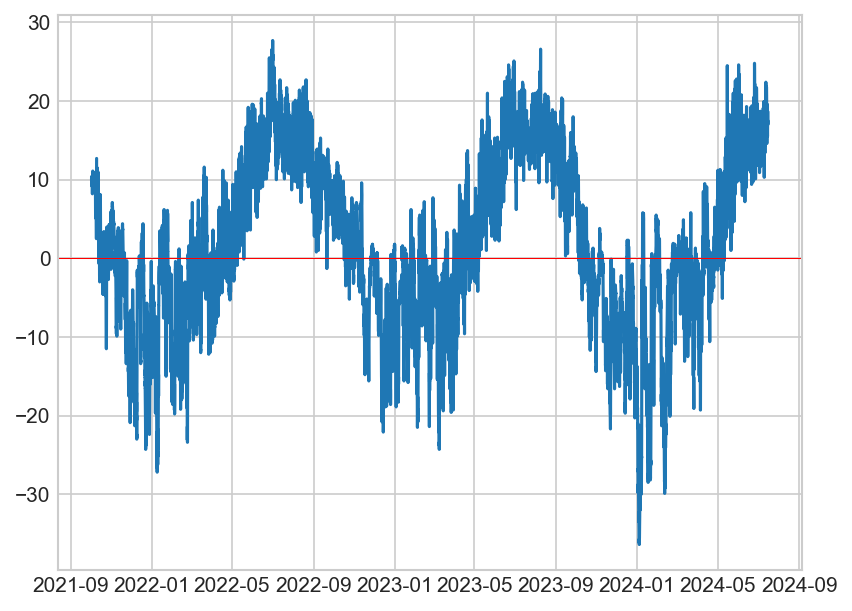

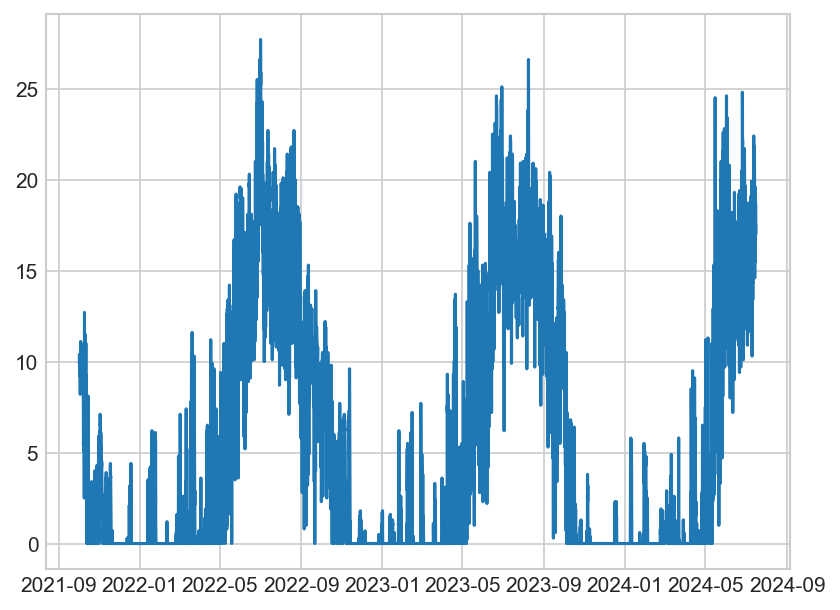

In [57]:
# Temperature plot
plt.plot(ambient_temp.index, ambient_temp)
plt.gca().axhline(y = 0, xmin = 0, xmax = 1, color = "r", linewidth = 0.5)
plt.show()

# Plot of the temperature when it is over 0
amb_temp_mask = ambient_temp.index[np.where(ambient_temp.Ambient_air_temp < 0)]
ambient_temp_posetive_only = ambient_temp.copy()
# I use 0 instead of NaN, so I don't mix the gaps that were there from the start with temperature =< 0
ambient_temp_posetive_only.loc[amb_temp_mask, 'Ambient_air_temp'] = 0
plt.plot(ambient_temp_posetive_only.index, ambient_temp_posetive_only)
plt.show()

<br>**Adding markers for ambient temperature during each event:**<br><br>

In [58]:
# List of datapoints with temperature is above 0 (when only this column is NaN)
list_of_dates_ambient_temp_posetive_only = ambient_temp_posetive_only[ambient_temp_posetive_only['Ambient_air_temp'] != 0]

# Formatting
amb_temp_pos = list_of_dates_ambient_temp_posetive_only.index.strftime('%Y-%m-%d %H')

# Comparing two lists to see events which wet-weather events are FULLY included into POSITIVE temperature list
amb_temp_pos_events_ind = [i for i, sublist in enumerate(wet_events_day.to_list()) if all(elem in amb_temp_pos.to_list() for elem in sublist)]

# Markers for the data_split_event df
data_split_event['SMHI_amb_temp'] = '< or ~ 0'  
data_split_event.loc[amb_temp_pos_events_ind, 'SMHI_amb_temp'] = '+'

<br>**Adding a column with *min_amb_temp* for the event:**<br><br>

In [59]:
# List of series for each event, each series contains H indexes
wet_weather_H = [pd.Series(wet_events_day[i]) for i in range(len(data_split_event))]

# Defyning average amb. temp. for each event
data_split_event['Min_amb_temp'] = [round(ambient_temp['Ambient_air_temp'].loc[index_series].min(), 1) for index_series in wet_weather_H]

<br>**Here I add a column showing number of missing datapoints from original SMHI data for each event, if any:**<br><br>

In [60]:
# Gaps in temperature
# List of datapoints with that were absent in original dataset downloaded from SMHI and marking events with such gaps in temperature
list_of_dates_ambient_temp_gaps = ambient_temp[ambient_temp['Ambient_air_temp'].isna()]

# Formatting
ambient_temp_gaps = pd.Series(pd.to_datetime(list_of_dates_ambient_temp_gaps.index).strftime('%Y-%m-%d %H').to_list())

# These are the indexes of the wet-weather events which have gaps in corresponding SMHI ambient temperature data
ind_of_found_ambient_temp_gaps = [ambient_temp_gaps[ambient_temp_gaps.isin(pd.Series(wet_events_day[i]))].index.tolist() for i in range(len(data_split_event))]

# Adding the number of missing hours in ambient temperature data for each event to the data_split_event
data_split_event['Amb_temp_gaps'] = [len(sublist) for sublist in ind_of_found_ambient_temp_gaps]

# Checking if some events don't have any amb temp data
for index, row in data_split_event.iterrows():
    event_duration = row['Event_duration']
    missing_hours = row['Amb_temp_gaps']
    
    n_hours_event = str(int(np.ceil(event_duration / np.timedelta64(1, 'h'))))
    
    if n_hours_event == missing_hours:
        # Modify the original DataFrame
        data_split_event.at[index, 'Amb_temp_gaps'] = 'No data'

# Formatting
data_split_event['Amb_temp_gaps'] = data_split_event['Amb_temp_gaps'].replace(0, ' ')

data_split_event.head(6)

,Start_w,End_w,Start_d,End_d,Event_duration,Dry_period_duration,Merged_event,Sampling_event,Event_type,SMHI_amb_temp,Min_amb_temp,Amb_temp_gaps
0,2021-10-02 04:43:00,2021-10-02 12:17:00,2021-10-02 12:17:30,2021-10-04 04:35:30,0 days 07:34:00,1 days 16:18:00,,,Rain,+,9.2,
1,2021-10-04 04:36:00,2021-10-05 08:54:00,2021-10-05 08:54:30,2021-10-06 12:27:30,1 days 04:18:00,1 days 03:33:00,+,,Rain,+,9.3,2
2,2021-10-06 12:28:00,2021-10-07 09:01:30,2021-10-07 09:02:00,2021-10-08 10:46:00,0 days 20:33:30,1 days 01:44:00,,,Rain,+,8.8,1
3,2021-10-08 10:46:30,2021-10-08 12:48:30,2021-10-08 12:49:00,2021-10-14 12:01:00,0 days 02:02:00,5 days 23:12:00,,,Rain,+,5.7,
4,2021-10-14 12:01:30,2021-10-17 17:39:00,2021-10-17 17:39:30,2021-10-20 09:58:00,3 days 05:37:30,2 days 16:18:30,+,,Rain,< or ~ 0,-0.1,1
5,2021-10-20 09:58:30,2021-10-20 20:56:30,2021-10-20 20:57:00,2021-10-21 12:18:00,0 days 10:58:00,0 days 15:21:00,,{1},Rain-on-snow,+,0.6,


## Possible road salt
Here we arbitrary identify threshold (1010 mkS/cm) over which we consider there were some deicing activities on the road.<br>
Justification: significant part of the values of the event should be over threshold, if it is just a few values - threshold is probably wrong or event has a few outliers because of the first flush or something like this. 

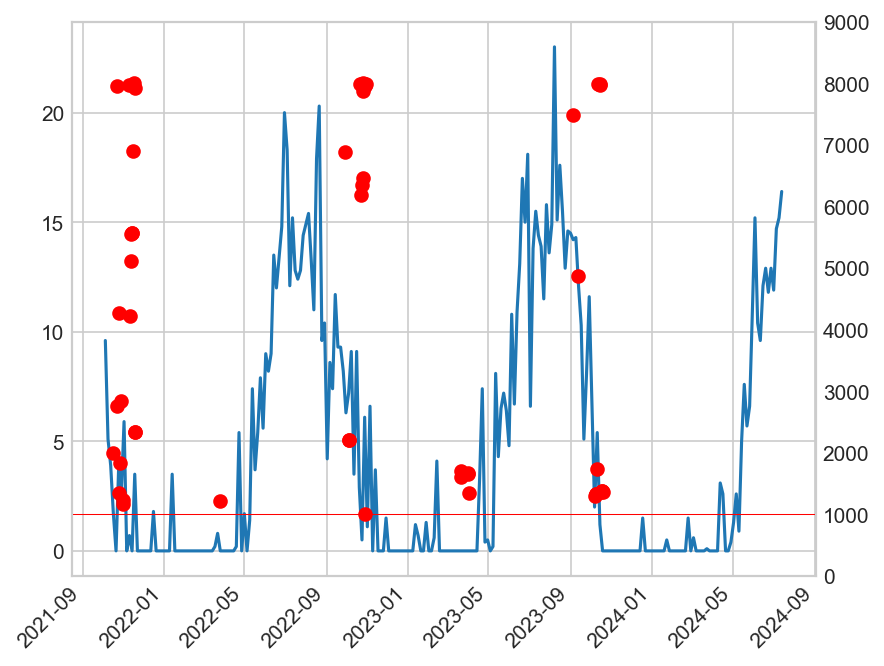

TIMESTAMP
2021-10-16     770
2021-10-22    1131
2021-10-23    2880
2021-10-24    2294
2021-10-25       1
2021-10-26     422
2021-10-28     215
2021-10-30      25
2021-10-31     177
2021-11-09     553
2021-11-10    2039
2021-11-11    2880
2021-11-12    2880
2021-11-13    2880
2021-11-14    2880
2021-11-15    2880
2021-11-16    1948
2021-11-17     578
2021-11-18    1991
2021-11-19    1588
2022-03-25     268
2022-09-28     485
2022-10-03    2879
2022-10-04    1543
2022-10-21    2377
2022-10-22    2880
2022-10-23    2880
2022-10-24    2880
2022-10-25    1408
2022-10-26    2225
2022-10-27    2260
2022-10-28       8
2022-10-29     134
2023-03-20    1234
2023-03-21    1454
2023-03-31    1400
2023-04-01    2633
2023-04-02    1343
2023-09-04      14
2023-09-12     109
2023-10-07    2244
2023-10-08    2880
2023-10-09    2880
2023-10-10    2574
2023-10-12      40
2023-10-14     241
2023-10-15    2335
2023-10-16    2880
2023-10-17    2880
2023-10-18    2880
2023-10-19    2017
Freq: D, dtype: int64

In [61]:
# Arbitrary I define threshgold for salt 
threshhold = 1010

# I identify dates where conductivity if over the threshhold
list_of_dates_cond_salt = data_corr[data_corr['Conduc_conduc_Avg'] > threshhold]
# I group them by day for the visual evaluation and plotting it in the graph
groupped_list_cond_salt = list_of_dates_cond_salt.groupby(list_of_dates_cond_salt.index.to_period('D')).size()

# Plotting
# ax1 - temperature axis
fig, ax1 = plt.subplots(dpi=150)
# ax2 - conductivity axis
ax2 = ax1.twinx()

# I resample temperature for once in 4 days interval for less noize in the graph, I just want to see seasonal trend of temperature
ambient_temp_posetive_only
ax1.plot(ambient_temp_posetive_only.resample('4D').interpolate(method='linear').index, ambient_temp_posetive_only.resample('4D').interpolate(method='linear'))


# Plotting conductivity
for date in groupped_list_cond_salt.index:
    # I plot only the maximum value per day in order to see which events are certainly over threshhold
    y = data_corr['Conduc_conduc_Avg'][f'{date}'].max()
    x = data_corr['Conduc_conduc_Avg'][f'{date}'][data_corr['Conduc_conduc_Avg'][f'{date}'] == y].index[0]
    ax2.scatter(x, y, color = 'r')
# Plotting threshhold
ax2.axhline(y = threshhold, xmin = 0, xmax = 1, color = "r", linewidth = 0.5)

# Formatting the plot
ax2.set_ylim(0, 9000)
plt.grid(False)

# Rotating lables of X axis
plt.setp(ax1.get_xticklabels(), 
          rotation=45, 
          horizontalalignment='right')

plt.show()

# Visual examination of the number of the datapoints that are over the threshhold
print(groupped_list_cond_salt)

In [62]:
# Hours where conductivity is over threshhold
cond_over_thr = pd.Series(list_of_dates_cond_salt.index.strftime('%Y-%m-%d %H'))
# These are the indexes of the wet-weather events which have conductivity data over throshhold, which is considered as indication of road deicing activities
ind_of_found_cond_over_thr = [cond_over_thr[cond_over_thr.isin(pd.Series(wet_events_day[i]))].index.tolist() for i in range(len(data_split_event))]

# Adding markers of where conductivity excided threshhold for each event to the data_split_event
data_split_event['Pot_salt'] = [' ' if not sublist else 'Pot. salt' for sublist in ind_of_found_cond_over_thr]

<br>**Finding max conductivity values for each corresponding wet-weather event**<br><br>

In [63]:
# Resampling conductivity for 1H interval and keep the max value, as we are interested if some of the actual values exceed the threshhold
cond_H = data_corr['Conduc_conduc_Avg'].resample('1 h').max()

# Defyning max conductivity for each event
data_split_event['Max_cond'] = [cond_H.loc[index_series].max() for index_series in wet_weather_H]

<br>**Finding the last conductivity value for each corresponding wet-weather event in order to see if all salt was gone by then**<br><br>

In [64]:
'''
# Resampling conductivity for 1H interval and keep the max value, as we are interested if some of the actual values exceed the threshhold
final_event_cond = [data_corr.loc[event_end, 'Conduc_conduc_Avg'] for event_end in data_split_event['End_w']]

# Defyning max conductivity for each event
data_split_event['Final_event_cond'] = final_event_cond
'''

"\n# Resampling conductivity for 1H interval and keep the max value, as we are interested if some of the actual values exceed the threshhold\nfinal_event_cond = [data_corr.loc[event_end, 'Conduc_conduc_Avg'] for event_end in data_split_event['End_w']]\n\n# Defyning max conductivity for each event\ndata_split_event['Final_event_cond'] = final_event_cond\n"

## Dataset with gaps

Here I automatically check distributions of gaps in conductivity and mark events that are having them in ***data_split_event*** df. I will need it later for choosing which events comprise my dataset for ML paper.
<div class="alert-warning">
    FUTURE IMPROVEMENT:
</div> 

Add ***max flow*** and maybe ***final cond measurement*** to see if salt was mostly flushed away during the event

In [65]:
# Gaps in conductivity
# List of datapoints with conductivity errors (when only this column is NaN)
list_of_dates_cond = data_corr[data_corr['Conduc_conduc_Avg'].isna() & data_corr.drop(columns='Conduc_conduc_Avg').notna().all(axis=1)]

cond_gaps = list_of_dates_cond.groupby(list_of_dates_cond.index.strftime('%Y-%m-%d %H')).size().index
cond_gaps = pd.Series(cond_gaps)


# Comparing two lists to see events with missing conductivity data
indexes_of_found_cond_gaps = []
for i in range(len(data_split_event)):
    # Use .isin() to check for elements in list1 and get their indexes in list2
    indexes_of_cond_gaps = cond_gaps[cond_gaps.isin(pd.Series(wet_events_day[i]))].index.tolist()
    indexes_of_found_cond_gaps.append(indexes_of_cond_gaps)


# Formatting
indexes_of_found_cond_gaps = ['o' if sublist else sublist for sublist in indexes_of_found_cond_gaps]
indexes_of_found_cond_gaps = [' ' if not sublist else sublist for sublist in indexes_of_found_cond_gaps]


# Adding these to the data_split_event
data_split_event['Cond_gaps'] = indexes_of_found_cond_gaps

## Final table
<div class="alert-warning">
    FUTURE IMPROVEMENT:
</div> 

We should consider excluding events that go after first salt events in autumn, as they are considered as transition events - cars already have studded tires. This can be important for working with turbidity. **Event 13**

In [66]:
data_split_event

,Start_w,End_w,Start_d,End_d,Event_duration,Dry_period_duration,Merged_event,Sampling_event,Event_type,SMHI_amb_temp,Min_amb_temp,Amb_temp_gaps,Pot_salt,Max_cond,Cond_gaps
0,2021-10-02 04:43:00,2021-10-02 12:17:00,2021-10-02 12:17:30,2021-10-04 04:35:30,0 days 07:34:00,1 days 16:18:00,,,Rain,+,9.2,,,600.650000,
1,2021-10-04 04:36:00,2021-10-05 08:54:00,2021-10-05 08:54:30,2021-10-06 12:27:30,1 days 04:18:00,1 days 03:33:00,+,,Rain,+,9.3,2,,395.333333,
2,2021-10-06 12:28:00,2021-10-07 09:01:30,2021-10-07 09:02:00,2021-10-08 10:46:00,0 days 20:33:30,1 days 01:44:00,,,Rain,+,8.8,1,,182.200000,
3,2021-10-08 10:46:30,2021-10-08 12:48:30,2021-10-08 12:49:00,2021-10-14 12:01:00,0 days 02:02:00,5 days 23:12:00,,,Rain,+,5.7,,,135.400000,
4,2021-10-14 12:01:30,2021-10-17 17:39:00,2021-10-17 17:39:30,2021-10-20 09:58:00,3 days 05:37:30,2 days 16:18:30,+,,Rain,< or ~ 0,-0.1,1,Pot. salt,1998.500000,o
5,2021-10-20 09:58:30,2021-10-20 20:56:30,2021-10-20 20:57:00,2021-10-21 12:18:00,0 days 10:58:00,0 days 15:21:00,,{1},Rain-on-snow,+,0.6,,,1005.500000,
6,2021-10-21 12:18:30,2021-10-21 17:31:00,2021-10-21 17:31:30,2021-10-22 02:05:30,0 days 05:12:30,0 days 08:34:00,,,Rain-on-snow,< or ~ 0,-0.9,1,,535.033333,o
7,2021-10-22 02:06:00,2021-10-22 18:00:30,2021-10-22 18:01:00,2021-10-24 18:59:00,0 days 15:54:30,2 days 00:58:00,,,Rain-on-snow,< or ~ 0,-1.1,,Pot. salt,7959.000000,o
8,2021-10-24 18:59:30,2021-10-25 07:31:30,2021-10-25 07:32:00,2021-10-28 05:20:30,0 days 12:32:00,2 days 21:48:30,,,Rain-on-snow,+,2.0,,Pot. salt,4273.000000,o
9,2021-10-28 05:21:00,2021-10-28 09:34:00,2021-10-28 09:34:30,2021-10-30 18:35:30,0 days 04:13:00,2 days 09:01:00,,,Rain-on-snow,+,0.8,,Pot. salt,2850.000000,


## Dataset for the first ML paper

**Conditions:**
* only RAIN EVENTS 
* during POSITIVE AMBIENT TEMPERATURES
* with NO GAPS in CONDUCTIVITY 
* with NO SALT

**Let's make automatic conditions for selecting events for ML paper dataset based on markers in the *data_split_event***<br>

In [67]:
def slice_dataset_ML(df, wet_events_indexes):
    '''
    This function uses the number of the event in the data_split_event to slice dataframe

    Parameters
    ----------
    wet_events_indexes : list
        Number of the event.

    Returns
    -------
    events_data : pd.DataFrame
        Slice of the dataframe.

    '''
    # Identifying their beginning and end
    ev_st = data_split_event.loc[wet_events_indexes, 'Start_w']
    ev_end = data_split_event.loc[wet_events_indexes, 'End_w']
    
    # Making a new df with data only during wet events
    events_data = None
    for i in wet_events_indexes:
        interval = df[ev_st[i]:ev_end[i]]
        if events_data is None:
            events_data = interval
        elif events_data is not None:
            events_data = pd.concat([events_data, interval])
    return events_data

<br>*Here I distribute events accross datasets and make actual datasets and also add 2 parameters: cumulative volume and time since last event*<br><br>

In [68]:
def extended_datasets_ML(df, dataset_ind):
    '''
    This function uses the number of the event in the data_split_event to slice dataframe and add new calculated parameters: Cumulative_discharged_volume_L and Time_since_last_event_min

    Parameters
    ----------
    dataset_ind : list
        Indeces of the events that should be included in the collection.

    Returns
    -------
    datasets_list_multi : list of pd.DataFrame
        Slices of the total dataset arranged into a list.

    '''
    datasets_list_multi = []
    for event_ind in dataset_ind:
        # Slice of the dataset
        df_extended = slice_dataset_ML(df, [event_ind]).copy()

        # Smoothening flow
        df_extended_for_smooth = df_extended.Flow_ls_Avg.dropna()
        # Apply Butterworth filter
        order = 3  # Filter order
        cutoff = 0.2  # Cutoff frequency
        b, a = butter(order, cutoff, btype='low', analog=False)
        butter_smoothed = filtfilt(b, a, df_extended_for_smooth)
        butter_smoothed = pd.Series(butter_smoothed, index = df_extended_for_smooth.index)
        df_extended.loc[:, 'Flow_ls_Avg'] = butter_smoothed

        
        # Cumulative volume FOR 30 SECONDS INTERVAL DATASET
        df_extended.loc[:, 'Cumulative_discharged_volume_L'] = np.cumsum(slice_dataset_ML(df.fillna(0), [event_ind])['Flow_ls_Avg'].values*30, axis=0)

        # As I don't have information about dry period precceeding the first (0) event in my dataset, I define this from SMHI data
        if event_ind == 0:
            # 9 and 12 h before there was little drizzle but likely didn't create any runoff, bigger rain was 159 h before, I will use this number
            dry_period_duration_minutes = 159*60
        else:
            # Finding duration of preciding dry period for the event and converting in number of minutes
            dry_period_duration_minutes = data_split_event.loc[event_ind-1, 'Dry_period_duration'].total_seconds() / 60
        # Making a df of ever rising value
        # time_since_last_event = np.arange(dry_period_duration_minutes, dry_period_duration_minutes + 0.5 * len(df_extended), 0.5)
        # Making a df of constant
        time_since_last_event = [dry_period_duration_minutes] * len(df_extended)
        # Adding df to the ML dataset
        df_extended.loc[:, 'Time_since_last_event_min'] = time_since_last_event

        # Time since the beginning of rain
        wet_period_duration_minutes = data_split_event.loc[event_ind, 'Event_duration'].total_seconds() / 60
        df_extended.loc[:, 'Time_since_beginning_of_rain_min'] = -np.arange(0, wet_period_duration_minutes + 0.5, 0.5)
        
        # Turning pH upside down for the model easier to lear the pattern and easier visualization
        # df_extended.loc[:, '-pH'] = -1 * df_extended.loc[:, 'pH_pH_Avg']
        # Keeping original values for now
        df_extended.loc[:, 'pH'] = df_extended.loc[:, 'pH_pH_Avg']
        
        # Absolute gradient of flow to amplify the strength of change
        df_extended.loc[:, 'Absolute_gradient_of_flow_ls'] = np.abs(np.gradient(df_extended.Flow_ls_Avg))
        
        datasets_list_multi.append(df_extended)
    return datasets_list_multi

In [69]:
# Rain events
rain_events_ind = data_split_event[data_split_event['Event_type'].str.contains(r'(?i)Rain$')].index

print(f'\nNumber of rain events: {len(rain_events_ind)}/{len(data_split_event)}')
print(f'\nIndices: {rain_events_ind.to_list()}\n')


Number of rain events: 96/134

Indices: [0, 1, 2, 3, 4, 12, 13, 15, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 76, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133]



In [70]:
# # Rain events without salt
# rain_events_no_salt_ind = data_split_event.iloc[rain_events_ind][data_split_event.iloc[rain_events_ind]['Pot_salt'].str.contains(r'Pot. salt') == False].index

# print(f'\nNumber of rain events without salt: {len(rain_events_no_salt_ind)}/{len(data_split_event)}')
# print(f'\nIndices: {rain_events_no_salt_ind.to_list()}\n')

In [71]:
# # Rain events without salt and without gaps in conductivity
# rain_events_no_salt_no_gaps_ind = data_split_event.iloc[rain_events_no_salt_ind][data_split_event.iloc[rain_events_no_salt_ind]['Cond_gaps'].str.contains(r'o') == False].index

# print(f'\nNumber of rain events without salt and witout gaps in conductivity: {len(rain_events_no_salt_no_gaps_ind)}/{len(data_split_event)}')
# print(f'\nIndices: {rain_events_no_salt_no_gaps_ind.to_list()}\n')

In [72]:
# Skipping events that have too low flow

# First creating dataset for this purpose
events_indeces = rain_events_ind.to_list()
reduced_dataset = extended_datasets_ML(data_corr, events_indeces)

# Arbitrary flow threshhold (l/s) below which it makes no sence to predict turbidity
fl_threshhold = 0.19

# Checking events
low_fl_ev = []
for i in range(len(reduced_dataset)):
    if reduced_dataset[i].Flow_ls_Avg.max() < fl_threshhold:
        low_fl_ev.append(i)

# Intense enough events        
sufficient_fl_ev = [events_indeces[i] for i in [x for x in np.arange(len(events_indeces)) if x not in low_fl_ev]]

print(f'\nNumber of rain events without salt and witout gaps in conductivity: {len(sufficient_fl_ev)}/{len(data_split_event)}')
print(f'\nIndices: {sufficient_fl_ev}\n')


Number of rain events without salt and witout gaps in conductivity: 60/134

Indices: [0, 1, 2, 4, 12, 25, 26, 27, 28, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44, 46, 47, 48, 49, 50, 52, 54, 56, 58, 59, 62, 63, 83, 85, 88, 89, 90, 91, 92, 93, 94, 95, 96, 98, 100, 103, 104, 105, 107, 108, 112, 123, 125, 126, 127, 130, 132, 133]



In [73]:
data_split_event.loc[sufficient_fl_ev, :]

,Start_w,End_w,Start_d,End_d,Event_duration,Dry_period_duration,Merged_event,Sampling_event,Event_type,SMHI_amb_temp,Min_amb_temp,Amb_temp_gaps,Pot_salt,Max_cond,Cond_gaps
0,2021-10-02 04:43:00,2021-10-02 12:17:00,2021-10-02 12:17:30,2021-10-04 04:35:30,0 days 07:34:00,1 days 16:18:00,,,Rain,+,9.2,,,600.650000,
1,2021-10-04 04:36:00,2021-10-05 08:54:00,2021-10-05 08:54:30,2021-10-06 12:27:30,1 days 04:18:00,1 days 03:33:00,+,,Rain,+,9.3,2,,395.333333,
2,2021-10-06 12:28:00,2021-10-07 09:01:30,2021-10-07 09:02:00,2021-10-08 10:46:00,0 days 20:33:30,1 days 01:44:00,,,Rain,+,8.8,1,,182.200000,
4,2021-10-14 12:01:30,2021-10-17 17:39:00,2021-10-17 17:39:30,2021-10-20 09:58:00,3 days 05:37:30,2 days 16:18:30,+,,Rain,< or ~ 0,-0.1,1,Pot. salt,1998.500000,o
12,2021-11-03 07:48:30,2021-11-04 02:36:30,2021-11-04 02:37:00,2021-11-04 09:00:00,0 days 18:48:00,0 days 06:23:00,,,Rain,+,4.6,,,966.000000,o
25,2022-05-31 23:25:30,2022-06-01 06:19:30,2022-06-01 06:20:00,2022-06-01 22:35:30,0 days 06:54:00,0 days 16:15:30,,,Rain,+,11.0,,,373.233333,
26,2022-06-01 22:36:00,2022-06-02 01:00:00,2022-06-02 01:00:30,2022-06-02 18:09:30,0 days 02:24:00,0 days 17:09:00,,,Rain,+,9.0,,,189.050000,
27,2022-06-02 18:10:00,2022-06-03 13:00:30,2022-06-03 13:01:00,2022-06-14 19:33:00,0 days 18:50:30,11 days 06:32:00,,{9},Rain,+,10.1,,,286.850000,
28,2022-06-14 19:33:30,2022-06-14 21:04:00,2022-06-14 21:04:30,2022-06-15 14:28:30,0 days 01:30:30,0 days 17:24:00,,,Rain,+,15.7,,,321.200000,
30,2022-06-18 03:03:00,2022-06-18 06:12:30,2022-06-18 06:13:00,2022-06-18 18:27:00,0 days 03:09:30,0 days 12:14:00,,,Rain,+,10.6,,,752.333333,


## Manual check and selection of the events from the list of events selected automatically
Method is based on visual evaluation of the patterns in the data distribution, though part of it could be automated if stable relations are discovered. As now, I tend to completely exclude events with high variation in one parameter and no variation in another, this events are normally events occuring after short dry period or low intensity rains.

In [74]:
# Concatting again
reduced_dataset_df = pd.concat(reduced_dataset)
# Adding engineered features
reduced_dataset_df = extended_datasets_ML(reduced_dataset_df, sufficient_fl_ev)
# Concatting again
reduced_dataset_df = pd.concat(reduced_dataset_df)

# Scalling (normalizing) data
scaler = MinMaxScaler(feature_range=(0,1))
# Fitting scaller to ALL train data, so we have to concat precipitation events in train dataset
scaler = scaler.fit(reduced_dataset_df)
# Transforming (scaling) dataset that has been formed by now
reduced_dataset_norm = scaler.transform(reduced_dataset_df)
reduced_dataset_norm = pd.DataFrame(reduced_dataset_norm, columns = reduced_dataset_df.columns, index=reduced_dataset_df.index)
# Combining two engineered time features
# reduced_dataset_norm.insert(15, 'Combined_time_feature', reduced_dataset_norm.Time_since_last_event_min * reduced_dataset_norm.Time_since_beginning_of_rain_min)

# Adding engineered features
ev_df_list = [slice_dataset_ML(reduced_dataset_norm, [event]) for event in sufficient_fl_ev]

In [75]:
# General widget display settings
item_layout = Layout(display='flex', flex_flow='column', align_items='center', width='100%')

def plot_series(x, y, start=None, end=None, x_name='Time', y_name='Value', title=None, label=None):
    '''
    Visualizes time series data

    Args:
      x (array of int) - contains indeces
      y (array) - contains the measurements for each time step
      start - first time step to plot
      end - last time step to plot
    '''
    # Setup dimensions of the graph figure
    plt.figure(figsize=(10, 6))
    
    n = 0
    plt.plot(x, y, label=label)

    # Legend
    plt.legend()
    
    # Title
    plt.title(title)
    
    # Label the x-axis
    plt.xlabel(x_name)

    # Label the y-axis
    plt.ylabel(y_name)

    # Overlay a grid on the graph
    plt.grid(True)
    
    # For plotting only part of the graph
    if start != None or end != None:
        plt.gca().set_xlim(start, end)
    
    # Draw the graph on screen
    plt.show()


# Define parameters and their corresponding numbers
parameters = {'Conductivity':2, 'Temperature':3, 'DO':4, 'Turbidity':6, 'pH':8, 'pH':15, 'Flow':10, 'Cumulative discharge':12, 'Time since last rain':13, 'Time since rain started':14, 'Absolute gradient of flow l/s':16}

def interactive_plot(n_event, time_axis, selected_params):

    # Choosing event
    dataset = ev_df_list[n_event].values

    # Choosing only parameters that have been chosen
    dataset = dataset[:, selected_params]

    # Labels for chosen parameters from the extended dataset
    labels = [next(key for key, idx in parameters.items() if idx == i) for i in selected_params]

    # Time axis
    if time_axis == 'datapoints':
        t_coeff = 1
        x_name = 'Datapoint index'
    elif time_axis == 'minutes':
        t_coeff = 0.5    # 1 min = 2 datapoints
        x_name = 'Time (min)'
    
    # The whole duration of the event from the test dataset
    time_event = t_coeff * np.arange(len(dataset))

    # Plotting
    plot_series(x = (time_event),
            y = (dataset),
            x_name = x_name,
            y_name = 'Scaled parameters',
            label = (labels),
            title = f'Event № {n_event}')
    plt.show()


# Widgets
# Event number
event = Dropdown(options = [(element, index) for index, element in enumerate(sufficient_fl_ev)], description = 'Event №:')

# Button for switching between time units
time_ax = ToggleButtons(options = ['datapoints', 'minutes'], description = 'Time axis', button_style = 'info')


# Create checkbox widgets for each parameter
checkboxes = {param: widgets.Checkbox(description=param, value=False) for param in parameters}
# Create a button widget to submit the selection
submit_button = widgets.Button(description="Submit")
# Create a fixed widget to hold the selected parameters
selected_parameters_widget = widgets.fixed([])
# Function to collect selected parameters
def collect_selected_parameters(button):
    selected_parameters = [parameters[param] for param, checkbox in checkboxes.items() if checkbox.value]
    # Update the fixed widget
    selected_parameters_widget.value = selected_parameters
# Attach the function to the button's click event
submit_button.on_click(collect_selected_parameters)


print()
# Collecting widgets into HBox for their basic layout configuration
checkbox_widgets = list(checkboxes.values())
wi = widgets.HBox([event, time_ax]+ checkbox_widgets + [submit_button], layout=item_layout)
# Output of the interactive plot
forecast_widget = widgets.interactive_output(interactive_plot, {'n_event': event, 'time_axis': time_ax, 'selected_params': selected_parameters_widget})

# Interactive plot display settings
forecast_widget.layout.display='flex'
forecast_widget.layout.justify_content='center'
display(wi, forecast_widget)

Output(layout=Layout(display='flex', justify_content='center'))

General ideas: (1) **No merging**, (2) **try to minimize flat-curve periods** (3) **turn over pH curve** (4) **No pH?** (5) Get rid of the first flush or lag it, so peaks match? (6) As samples are independant - what matters is correlation of the parameters within each sample. Inventing procedure for maximizing informativeness of each sample? Dropping low correlation samples? Creating diverse samples of flexible length? (6) Carrefully chack if dry periods are actual dry periods known and detected before using them for further in investugation (7) To maximize the use of the parameters use **gradient** not parameter itself<br><br>

0 - Turbidity no peaks, **exclude**<br>
1 - Long dry period between peaks, flow doesn't go to 0 **exclude**<br>
2 - A lot of noise, flow doesn't drop to zero, pH behaves weirdly, **exclude**<br>
4 - Low flow **drop tail peak, drop flat parts**<br>
12 - Low flow **drop flat tail**<br>
22 - Low flow **exclude**<br>
23 - Long dry period, flow generally is low **exclude**<br>
24 - Flow generally is low **exclude**<br>
25 - Fine<br>
26 - Turbidity is low, **drop flat part**<br>
27 - **drop flat part/leave as-is**<br>
28 - Turbidity no peaks - only first flush, **exclude**<br>
30 - Turbidity no peaks, **drop flat parts**<br>
31 - Turbidity is too low, **use with time parameters**<br>
32 - Turbidity is too low, **exclude**<br>
33 - Turbidity is too low **exclude**<br>
34 - Turbidity is too low **exclude**<br>
35 - **Drop flat tail**<br>
36 - Turbidity is too low **Exclude**<br>
37 - Turbidity is too low **Exclude**<br>
38 - Turbidity is too low **Exclude**<br>
39 - Turbidity is too low **Exclude**<br>
40 - Turbidity is too low **Exclude**<br>
41 - Turbidity is too low **Exclude**<br>
42 - Turbidity is too low **Exclude**<br>
44 - Turbidity is too low **Exclude**<br>
46 - **don't merge/drop flat part**<br>
47 - **drop flat parts**<br>
48 - **drop flat parts and the last peak**<br>
49 - **drop flat tail**<br>
50 - **drop flat parts**<br>
52 - **drop flat tail**<br>
54 - **drop flat parts and the last peak**<br>
56 - **drop flat tail**<br>
58 - Turbidity is too low **Exclude**<br>
59 - Turbidity is too low **Exclude**<br>
62 - Turbidity and flow are too low **Exclude**<br>
63 - Turbidity doesn't match flow **exclude**<br>
83 - **drop flat parts**<br>
85 - Rain intensity is probably too low **Exclude**<br>
88 - Flow doesn't get back to 0 **Exclude**<br>
89 - **Fine**<br>
90 - Turbidity is too low **Exclude**<br>
91 - **Fine**<br>
92 - **Fine**<br>
93 - **drop tails**<br>
94 - **Fine/drop flat tail**<br>
95 - Looks like low intensity rain - no pronounced peeks **Exclude**<br>
96 - **drop flat parts**<br>
98 - A lot of noise in both parameters due to trafic, also very low values **Exclude**<br>
100 - **drop the noisy tail**<br>
103 - Turbidity is too low **Exclude**<br>
104 - Fine<br>
105 - Turbidity is too low **Exclude**<br>
107 - Turbidity and flow don't match **Exclude**<br>
108 - **drop flat parts**<br>
112 - **drop flat tail**<br>
123 - Probably gullypot wasn't cleaned properly or it can be streets not swept **exclude**<br>
124 - Very short event with low turbidity **exclude**<br>
125 - Good **drop flat tail**<br>
126 - Fine<br>
127 - **drop flat parts**<br>
130 - **drop flat tail**<br>
132 - Flood in th emiddle of the event - **drop tail**<br>
133 - Data are not reliable due to flood **exclude**<br>


Observations that can help cluster the data both inter- and intra-event: very low turbidity during the summer - check the low turbidity events against **time of the year**. Noise in the flow and turbidity come from the cars splashing the paddles near to the manhole creating local peeks that correspond to the trafic light intervals at the beginning of the road - check against **time of the day**. Lesson to learn here - don't install sensors directly at the road side, instead install them downstream to avoid noise. 3rd role of time as metadata feature for my model - time of the day.

Make a table for characterizing events with following columns: "flow drops back to 0 in the end", "noise in flow and other parameters due to cars - smoothening required", "Low flow/low intensity event", "Low turbidity", "Month", "Time since last event", "Turbidity range"

### Selecting data manually

In [76]:
# Selecting events from the list
selected_events_idx = [4, 12, 25, 26, 27, 30, 31, 35, 46, 47, 48, 49, 50, 52, 54, 56, 58, 83, 89, 91, 92, 93, 94, 96, 98, 100, 104, 108, 112, 125, 126, 127, 130, 132]
selected_events = [slice_dataset_ML(reduced_dataset_norm, [event]) for event in selected_events_idx]

4 - Low flow **drop tail peak, drop flat parts**<br>
12 - Low flow **drop flat tail**<br>
25 - Fine<br>
26 - Turbidity iw low, weird outlier **drop flat part, drop outlier**<br>
27 - **drop flat part/leave as-is**<br>
30 - Turbidity no peaks, **drop flat parts**<br>
31 - Turbidity is too low, **use with time parameters**<br>
35 - **Drop flat tail**<br>
46 - **don't merge/drop flat part**<br>
47 - **drop flat parts**<br>
48 - **drop flat parts and the tail peak**<br>
49 - **drop flat tail**<br>
50 - **drop flat parts**<br>
52 - **drop flat tail**<br>
54 - **drop flat parts and the tail peak**<br>
56 - **drop flat tail**<br>
83 - **drop flat parts**<br>
89 - **Fine**<br>
91 - **Fine**<br>
92 - **Fine**<br>
93 - **drop tails**<br>
94 - **Fine/drop flat tail**<br>
96 - **drop flat parts**<br>
100 - **drop the noisy tail**<br>
104 - **drop flat parts**<br>
108 - **drop flat parts**<br>
112 - **drop flat tail**<br>
123 - Probably gullypot wasn't cleaned properly or it can be streets not swept **exclude**<br>
124 - Very short event with low turbidity **exclude**<br>
125 - Good **drop flat tail**<br>
126 - Fine<br>
127 - **drop flat parts**<br>
130 - **drop flat tail**<br>
132 - Flood in th emiddle of the event - **drop tail**<br>

In [77]:
selected_events[selected_events_idx.index(132)].iloc[0]

RECORD                              0.233417
Conduc_temp_Avg                     0.465001
Conduc_conduc_Avg                   0.008995
DO_temp_Avg                         0.512897
DO_mg_L_Avg                         0.247370
Turb_temp_Avg                       0.619019
Turb_FNU_Avg                        0.037303
pH_temp_Avg                         0.505541
pH_pH_Avg                           0.365502
Level_mm_Avg                        0.123068
Flow_ls_Avg                         0.008452
Flow_m3h_Avg                        0.001868
Cumulative_discharged_volume_L      0.000059
Time_since_last_event_min           0.083018
Time_since_beginning_of_rain_min    1.000000
pH                                  0.365502
Absolute_gradient_of_flow_ls        0.052681
Name: 2024-07-09 11:10:00, dtype: float64

In [78]:
selected_events[selected_events_idx.index(132)].iloc[-1]

RECORD                              0.233613
Conduc_temp_Avg                     0.614793
Conduc_conduc_Avg                   0.007293
DO_temp_Avg                         0.634004
DO_mg_L_Avg                         0.539843
Turb_temp_Avg                       0.793688
Turb_FNU_Avg                        0.136949
pH_temp_Avg                         0.669729
pH_pH_Avg                           0.634357
Level_mm_Avg                        0.078420
Flow_ls_Avg                         0.006306
Flow_m3h_Avg                        0.000000
Cumulative_discharged_volume_L      0.203755
Time_since_last_event_min           0.083018
Time_since_beginning_of_rain_min    0.977456
pH                                  0.634357
Absolute_gradient_of_flow_ls        0.000011
Name: 2024-07-09 12:55:00, dtype: float64

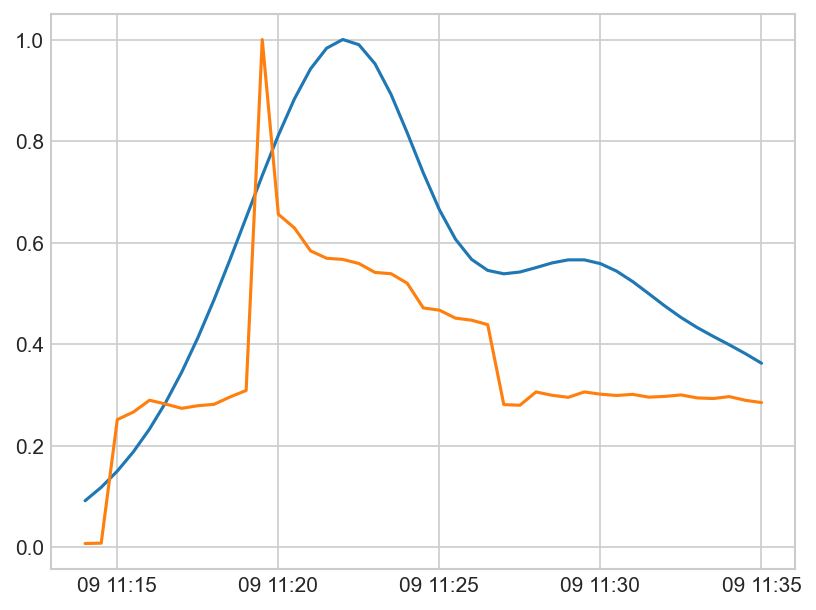

In [79]:
plt.plot(selected_events[selected_events_idx.index(132)]['2024-07-09 11:14:00': '2024-07-09 11:35:00'].Flow_ls_Avg)
plt.plot(selected_events[selected_events_idx.index(132)]['2024-07-09 11:14:00': '2024-07-09 11:35:00'].Turb_FNU_Avg)

# plt.ylim(0, 0.2)

In [80]:
# # Smoothening flow
# # Apply Butterworth filter
# order = 3  # Filter order
# cutoff = 0.2  # Cutoff frequency
# b, a = butter(order, cutoff, btype='low', analog=False)
# butter_smoothed = filtfilt(b, a, selected_events[selected_events_idx.index(83)]['2023-05-17 16:00:00': '2023-05-17 18:30:30'].Flow_ls_Avg.dropna())
# butter_smoothed

In [81]:
# Here I manually select parts of the events that I want to include into the dataset
corrected_selected_events = [
    selected_events[selected_events_idx.index(4)]['2021-10-16 02:00:00': '2021-10-16 17:30:00'],
    selected_events[selected_events_idx.index(12)]['2021-11-03 07:48:30': '2021-11-03 16:00:00'],
    selected_events[selected_events_idx.index(25)],
    selected_events[selected_events_idx.index(26)]['2022-06-01 22:47:30': '2022-06-01 23:30:00'],
    selected_events[selected_events_idx.index(27)]['2022-06-02 18:10:00': '2022-06-02 23:00:00'],
    selected_events[selected_events_idx.index(30)]['2022-06-18 03:30:00': '2022-06-18 04:30:00'],
    selected_events[selected_events_idx.index(31)],
    selected_events[selected_events_idx.index(35)]['2022-07-10 05:00:00': '2022-07-10 10:00:00'],
    selected_events[selected_events_idx.index(46)]['2022-09-14 09:00:00': '2022-09-14 10:00:00'],
    selected_events[selected_events_idx.index(46)]['2022-09-14 14:35:00': '2022-09-14 15:30:00'],
    selected_events[selected_events_idx.index(47)]['2022-09-15 03:30:00': '2022-09-15 09:35:00'],
    selected_events[selected_events_idx.index(48)]['2022-09-15 19:24:30': '2022-09-16 00:00:00'],
    selected_events[selected_events_idx.index(48)]['2022-09-16 01:40:00': '2022-09-16 02:40:00'],
    selected_events[selected_events_idx.index(48)]['2022-09-16 08:40:30': '2022-09-16 10:00:00'],
    selected_events[selected_events_idx.index(49)]['2022-09-17 05:21:30': '2022-09-17 09:15:00'],
    selected_events[selected_events_idx.index(50)],
    selected_events[selected_events_idx.index(52)]['2022-09-24 07:59:30': '2022-09-24 09:17:00'],
    selected_events[selected_events_idx.index(54)]['2022-10-05 12:00:00': '2022-10-05 21:00:00'],
    selected_events[selected_events_idx.index(54)]['2022-10-06 02:30:00': '2022-10-06 06:30:00'],   # 16 - I smoothed flow, but it might be better to drop this period - too low turbidity
    selected_events[selected_events_idx.index(56)]['2022-10-11 09:02:00': '2022-10-11 13:00:00'],
    selected_events[selected_events_idx.index(83)]['2023-05-16 23:30:00': '2023-05-17 00:30:30'],
    selected_events[selected_events_idx.index(83)]['2023-05-17 05:00:00': '2023-05-17 07:30:00'],
    selected_events[selected_events_idx.index(83)]['2023-05-17 16:00:00': '2023-05-17 18:30:30'],
    selected_events[selected_events_idx.index(83)]['2023-05-18 03:40:00': '2023-05-18 07:30:00'],
    selected_events[selected_events_idx.index(89)]['2023-06-23 15:10:00': '2023-06-24 02:19:00'],
    selected_events[selected_events_idx.index(91)]['2023-08-11 17:47:00': '2023-08-11 19:30:00'],
    selected_events[selected_events_idx.index(92)],
    selected_events[selected_events_idx.index(93)]['2023-08-13 16:09:00': '2023-08-13 22:30:00'],
    selected_events[selected_events_idx.index(93)]['2023-08-14 01:15:00': '2023-08-14 02:45:00'],
    selected_events[selected_events_idx.index(94)],
    selected_events[selected_events_idx.index(96)],
    selected_events[selected_events_idx.index(100)]['2023-08-29 01:57:00': '2023-08-29 05:15:00'],
    selected_events[selected_events_idx.index(104)]['2023-09-03 10:40:00': '2023-09-03 13:25:00'],
    selected_events[selected_events_idx.index(108)]['2023-09-28 23:35:30': '2023-09-29 00:30:00'],
    selected_events[selected_events_idx.index(108)]['2023-09-29 03:10:00': '2023-09-29 06:00:00'],
    selected_events[selected_events_idx.index(112)]['2023-10-04 19:03:00': '2023-10-04 20:50:00'],
    selected_events[selected_events_idx.index(125)]['2024-05-24 15:40:30': '2024-05-24 16:45:30'],
    selected_events[selected_events_idx.index(126)]['2024-06-04 00:00:00': '2024-06-04 04:00:30'],
    selected_events[selected_events_idx.index(127)]['2024-06-09 23:20:00': '2024-06-09 23:40:30'],
    selected_events[selected_events_idx.index(127)]['2024-06-10 00:21:00': '2024-06-10 01:40:30'],
    selected_events[selected_events_idx.index(130)]['2024-07-07 10:58:00': '2024-07-07 13:00:00'],
    selected_events[selected_events_idx.index(132)]['2024-07-09 11:14:00': '2024-07-09 11:35:00']
    
]

In [82]:
# Function to split the DataFrame whenever there are NaN values
def split_df_on_nan(df):
    nan_indices = df.index[df.isnull().any(axis=1)].tolist()
    split_dfs = []
    prev_index = 0

    for nan_index in nan_indices:
        nan_index_loc = df.index.get_loc(nan_index)
        segment = df.iloc[prev_index:nan_index_loc].dropna(how='all')
        if not segment.empty:
            split_dfs.append(segment)
        prev_index = nan_index_loc + 1

    # Add the last segment
    segment = df.iloc[prev_index:].dropna(how='all')
    if not segment.empty:
        split_dfs.append(segment)
    
    return split_dfs

# Split the DataFrame
split_dfs = [split_df_on_nan(event) for event in corrected_selected_events]

# Flatten the list of lists
flattened_list = [element for sublist in split_dfs for element in sublist]

<br><br>**The shortest period should be still longer than expected gap+2*lag**

In [83]:
sorted([len(period) for period in flattened_list])

[20,
 42,
 43,
 86,
 110,
 111,
 121,
 121,
 121,
 122,
 131,
 156,
 160,
 160,
 167,
 181,
 196,
 207,
 207,
 212,
 215,
 245,
 272,
 301,
 321,
 341,
 461,
 468,
 477,
 481,
 482,
 552,
 581,
 601,
 731,
 739,
 763,
 829,
 984,
 1081,
 1339,
 1861,
 2165,
 2227]

In [84]:
# The only unreasonably short period is 21 datapoints long, we can work with 109, which is 54.5 min, I arbitrary choose 50 minutes (100 datapoints) as maximum window length
# Maximum gap and lag that I intend to test in my model [min/2] - unit of the interval
# Multiplying by 2 as we have data with 30 sec intervals
max_gap = 45*2

In [85]:
# Shortest datasets
dura = [len(event) for event in flattened_list]

# Finding events below threshhold
shorter_events = [num for num in dura if num < max_gap]
shorter_events_idx = [dura.index(event_duration) for event_duration in shorter_events]

print('Defined threshold:', max_gap/2, 'min')
print('Identifyed indeces of periods in flattened_list that are shorter than that:', shorter_events_idx)

# Dropping shorter events
eddited_list_of_selected_periods = [element for i, element in enumerate(flattened_list) if i not in shorter_events_idx]

Defined threshold: 45.0 min
Identifyed indeces of periods in flattened_list that are shorter than that: [3, 33, 40, 43]


<br><br>**Complementing every period with tails for windowing**<br>
1. Transform back
2. ~~Add tails where possible for the existing data, if data are missing - add straight line~~ Add tails masked with the value ***"-111"***, so only previously selected data takes part in model training
3. For engineered features add negative values for the beginning of the rain and actual values for "since last event"
4. In the model code change how windows are created by moving the beginning of the first instance forward

In [86]:
original_data = [pd.DataFrame(scaler.inverse_transform(period), columns=period.columns, index=period.index) for period in eddited_list_of_selected_periods]

<br><br>**Extend every period for chosen maximum tail length**<br>

In [87]:
# While maximum gap size can't exceed the size of the window, lag size - can, as we ADD lag as tails to each window
# I arbitrary choose it the same length as the maximum duration of the gap

# The longest possible lag
max_lag = max_gap
print('\nThe longest time of context before or after the gap', max_lag/2, 'minutes,')
print('which I will, accordingly, use for the max_lag to add tails to the windows\n')


The longest time of context before or after the gap 45.0 minutes,
which I will, accordingly, use for the max_lag to add tails to the windows



In [88]:
# Extend the slice by max_lag rows before and after
def extend_slice(df, n=max_lag):
    # Calculated with assumption that interval is 30s, so n convertion into minutes:
    n_min=n/2
    # Make an extended list of indeces
    new_start = df.index[0] - pd.Timedelta(minutes=n_min)
    new_end = df.index[-1] + pd.Timedelta(minutes=n_min)
    extended_index = pd.date_range(start=new_start, end=new_end, freq='30s')
    
    # Extended df
    extended_df = df.reindex(extended_index)

    return extended_df

# Loop it and fill the NaNs with masking value "-111"
extended_dataset = [extend_slice(period).fillna(-111) for period in original_data]

<br><br>**Add engineered features and extend them to the tails**<br>

In [89]:
# Propagating engineered features
for period in extended_dataset:
    # Time since last event
    ant_time_since_last_event_list = []
    con_time_since_last_event_list = []
    ant_time_since_last_event = period.iloc[max_lag, period.columns.get_loc('Time_since_last_event_min')]
    con_time_since_last_event = period.iloc[-max_lag-1, period.columns.get_loc('Time_since_last_event_min')]
    for i in np.arange(max_lag, 0, -1):
        ant_time_since_last_event -= 0.5
        con_time_since_last_event += 0.5
        ant_time_since_last_event_list.append(ant_time_since_last_event)
        con_time_since_last_event_list.append(con_time_since_last_event)
    # Make antecedent values ascend
    ant_time_since_last_event_list.sort()


    # Time since beginning of rain
    ant_time_since_beginning_of_event_list = []
    con_time_since_beginning_of_event_list = []
    ant_time_since_beginning_of_event = period.iloc[max_lag, period.columns.get_loc('Time_since_beginning_of_rain_min')]
    con_time_since_beginning_of_event = period.iloc[-max_lag-1, period.columns.get_loc('Time_since_beginning_of_rain_min')]
    for i in np.arange(max_lag, 0, -1):
        ant_time_since_beginning_of_event -= 0.5
        con_time_since_beginning_of_event += 0.5
        ant_time_since_beginning_of_event_list.append(ant_time_since_beginning_of_event)
        con_time_since_beginning_of_event_list.append(con_time_since_beginning_of_event)
    # Make antecedent values ascend
    ant_time_since_beginning_of_event_list.sort()

    # Time since last event
    period.iloc[:max_lag, period.columns.get_loc('Time_since_last_event_min')] = ant_time_since_last_event_list
    period.iloc[-max_lag:, period.columns.get_loc('Time_since_last_event_min')] = con_time_since_last_event_list
    # Time since beginning of rain
    period.iloc[:max_lag, period.columns.get_loc('Time_since_beginning_of_rain_min')] = ant_time_since_beginning_of_event_list
    period.iloc[-max_lag:, period.columns.get_loc('Time_since_beginning_of_rain_min')] = con_time_since_beginning_of_event_list

<br><br>**Choosing parameters to include into the dataset**

In [90]:
extended_dataset = [period.loc[:, ['Conduc_conduc_Avg', 
                                   'DO_temp_Avg', 
                                   'DO_mg_L_Avg', 
                                   'Turb_FNU_Avg', 
                                   'pH', 
                                   'Flow_ls_Avg', 
                                   'Cumulative_discharged_volume_L', 
                                   'Time_since_last_event_min', 
                                   'Time_since_beginning_of_rain_min',
                                   'Absolute_gradient_of_flow_ls']] for period in extended_dataset]

### Distributing events in such order that events included into training dataset have the highest total correlation across them

<br>**Checking correlations of the parameters**

<br>This function below finds the best combination of evetnts in ***train_dataset*** by calculating the highest combined non-parameteric monotonicity correlation score across all parameters

<br>*Distributing indeces*

In [91]:
def resampling_datasets(dataset, interval):
    '''
    This function resamples every event in the collection of events

    Parameters
    ----------
    dataset : list of pd.DataFrames
        Collection of events
    interval: str
        TimeDelta str to resample data
        
    Returns
    -------
    resampled_dataset : list of pd.DataFrames
        Initial list of events but resampled
    '''
    df = dataset.copy()
    # data is taken like this - [)
    resampled_dataset = [event.resample(interval, label = 'right').mean() for event in df]
    return resampled_dataset

In [114]:
# def corr_events_distribution(df, num_iter, interval='30s', num_drop_events=[0], n_events_test=8, n_events_val=8):
#     '''
#     This function finds the best combination of evetnts in train dataset by calculating the highest combined non-parameteric monotonicity correlation score across all parameters

#     Parameters
#     ----------
#     num_iter : int
#         Number of combinations to try in order to find an optimal score.
#     num_drop_events : list
#         A list of number of events to drop, if any
#     interval: str
#         TimeDelta str to resample data
#     n_events_test : int
#         How many events from the total number of events comprising dataset should be included into test dataset
#     n_events_val : int
#         How many events from the total number of events comprising dataset should be included into validation dataset
    
#     Returns
#     -------
#     result_score_df : pd.DataFrame
#         DataFrame containing the best scored combinations.

#     '''
#     # Randomizing indeces in order to check if data recombination accress datasets would have making better model, as it doesn't work now
#     tot_dataset_ind_random = np.arange(len(df))
#     # tot_dataset_ind_random = data_split_ML.index.values.copy()
    
#     result_score = []
#     for n in num_drop_events:
#         score_df = []
#         ind_list = []
#         val_ds_ind_random_list, test_ds_ind_random_list = [], []
#         for seed_num in range(num_iter):
#             # Change the seed number to experiment with different combinations of events in datasets
#             random.seed(seed_num)
#             random.shuffle(tot_dataset_ind_random)
            
#             # Creating datasets
#             train_ds_ind_random = tot_dataset_ind_random.copy()[:-(n_events_val+n_events_test)]
#             val_ds_ind_random = sorted(list(tot_dataset_ind_random.copy()[-(n_events_val+n_events_test):-n_events_test]))
#             test_ds_ind_random = sorted(list(tot_dataset_ind_random.copy()[-n_events_test:]))
            
#             # Here I drop some number of events
#             train_dataset_ind_rand = sorted(train_ds_ind_random[:len(train_ds_ind_random)-n])
#             # List of events
#             train_dataset_random_list = [df[i] for i in train_dataset_ind_rand]
#             # train_dataset_random_list = extended_datasets_ML(train_dataset_ind_rand)
    
#             # Resampling
#             if not interval == '30s' or not interval == '0.5min' or not interval == '30 s' or not interval == '0.5 min':
#                 train_dataset_random_list = resampling_datasets(train_dataset_random_list, interval)
    
#             # Merged
#             train_dataset_random_merged = pd.concat(train_dataset_random_list)
    
#             # Score
#             # Visualize the correlation matrix using a heatmap
#             corr_matrix  = train_dataset_random_merged.corr(method='spearman')
#             # Get the shape of the correlation matrix
#             num_rows, num_cols = corr_matrix.shape
#             # Initialize sum
#             score = 0
#             # Calculate sum of numbers under the diagonal
#             for i in range(num_rows):
#                 for j in range(i + 1, num_cols):
#                     score += abs(corr_matrix.iloc[i, j])
#             score_df.append(score)
    
#             # Indeces
#             ind_list.append(train_dataset_ind_rand)
#             val_ds_ind_random_list.append(val_ds_ind_random)
#             test_ds_ind_random_list.append(test_ds_ind_random)
#         score_df = pd.Series(score_df)
#         # I make a list of [n, best_seed, best_score, list_of_indeces_train, list_of_indeces_val, list_of_indeces_test] for all combinations of events
#         result_score.append([int(n), score_df.idxmax(), score_df.max(), str(ind_list[score_df.idxmax()]), str(val_ds_ind_random_list[score_df.idxmax()]), str(test_ds_ind_random_list[score_df.idxmax()])])
#     result_score_df = pd.DataFrame(np.array(result_score), columns = ['num_of_dropped_events', 'best_seed', 'score', 'train_ind', 'val_ind', 'test_ind'])
    
#     # Formatting df
#     result_score_df['num_of_dropped_events'] = result_score_df['num_of_dropped_events'].astype(int)
#     result_score_df['best_seed'] = result_score_df['best_seed'].astype(int)
#     result_score_df['score'] = result_score_df['score'].astype(float)
#     result_score_df.set_index('num_of_dropped_events', inplace=True)
    
#     # Saving result into a dedicated folder
#     result_score_df.to_csv(f'{data_path}/prepared_datasets/events_distribution_across_datasets/corr_score-{result_score_df["score"][0]:.6f}_{num_iter}iter_{interval}.csv')
    
#     return result_score_df






# To preserve the distribution of the events found at the beginning of the models training we download file created back then
event_distr = pd.read_csv(f'{data_path}/prepared_datasets/events_distribution_across_datasets/corr_score-22.349031_1000iter_30s.csv')

In [117]:
def stats_datasets(train_df, val_df, test_df, tot_df):
    print('New total length of the dataset:', len(np.concatenate(tot_df)), '\n\n')
    print('Length of the train dataset:', len(np.concatenate(train_df)), '\n\n')
    print('Shares of the total dataset (%):')
    print('Train: ', round(len(np.concatenate(train_df))/(len(np.concatenate(tot_df)))*100, 2), f'({len(train_df)}/{len(tot_df)}) periods')
    print('Val: ', round(len(np.concatenate(val_df))/(len(np.concatenate(tot_df)))*100, 2), f'({len(val_df)}/{len(tot_df)}) periods')
    print('Test: ', round(len(np.concatenate(test_df))/len(np.concatenate(tot_df))*100, 2), f'({len(test_df)}/{len(tot_df)}) periods')
    return None

In [118]:
def heatmap_plot_of_corr_matrix(df_list, title):
    '''
    This function plots a heatmap of the spearman correlations between parameters in the dataset across all events

    Parameters
    ----------
    df_list : list of pd.DataFrames
        Collection of events
    title : str
        title of the plot

    Returns
    -------
    None
    '''
    # Merging events in one dataset
    df_list_merged = pd.concat(df_list)
    
    # Visualize the correlation matrix using a heatmap
    corr_matrix  = df_list_merged.corr(method='spearman')
    
    plt.figure(figsize=(7, 7*5/6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(title)
    plt.show()

### Original dataset with a timestep of 30 s split into datasets by length of the periods

In [97]:
# %%time
# # Taking the shortest periods for the test and the rest for val and train
# train_idx = list(pd.Series([len(event) for event in extended_dataset]).sort_values()[14:].index)
# val_test_idx = list(pd.Series([len(event) for event in extended_dataset]).sort_values()[:14].index)

# # Set the seed for reproducibility
# random.seed(42)
# # Shuffle the list
# random.shuffle(val_test_idx)

# val_idx = val_test_idx[:7]
# test_idx = val_test_idx[7:]


# # Datasets
# train_datasets_30s = [extended_dataset[i] for i in train_idx]
# val_datasets_30s = [extended_dataset[i] for i in val_idx]
# test_datasets_30s = [extended_dataset[i] for i in test_idx]
# tot_datasets_30s = extended_dataset

# # Printing out stats of the run
# stats_datasets(train_datasets_30s, val_datasets_30s, test_datasets_30s, tot_datasets_30s)

<br>*Saving datasets*<br>

In [98]:
# # Creating a dictionary to hold all datasets
# multipar_datasets_30s = {
#     'train_datasets': train_datasets_30s,
#     'val_datasets': val_datasets_30s,
#     'test_datasets': test_datasets_30s,
#     'total_datasets': tot_datasets_30s
# }

# # Save the dictionary to a single file
# with open(r'prepared_datasets\multipar_datasets_30s.pkl', 'wb') as f:
#     pickle.dump(multipar_datasets_30s, f)

### Original dataset with a timestep of 30 s

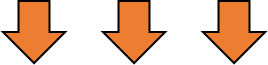

In [119]:
# Number of iterations assigned the same for all datasets
n_iter = 1000
# Specify interval at which data were resampled
interval = '30s'

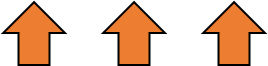

In [120]:
%%time
# Distribution
# event_distr = corr_events_distribution(extended_dataset, num_iter=n_iter, interval=interval)

# Indeces
train_dataset_ind_corr_30s = ast.literal_eval(event_distr.loc[0, 'train_ind'])
val_dataset_ind_corr_30s = ast.literal_eval(event_distr.loc[0, 'val_ind'])
test_dataset_ind_corr_30s = ast.literal_eval(event_distr.loc[0, 'test_ind'])

# Datasets
train_datasets_list_multi_corr_30s = [extended_dataset[i] for i in train_dataset_ind_corr_30s]
val_datasets_list_multi_corr_30s = [extended_dataset[i] for i in val_dataset_ind_corr_30s]
test_datasets_list_multi_corr_30s = [extended_dataset[i] for i in test_dataset_ind_corr_30s]
tot_datasets_list_multi_corr_30s = extended_dataset

# Printing out stats of the run
print('Best score: ', event_distr.loc[0, 'score'], '\n\n')
stats_datasets(train_datasets_list_multi_corr_30s, val_datasets_list_multi_corr_30s, test_datasets_list_multi_corr_30s, tot_datasets_list_multi_corr_30s)

Best score:  22.34903107389582 


New total length of the dataset: 28200 


Length of the train dataset: 12307 


Shares of the total dataset (%):
Train:  43.64 (24/40) periods
Val:  24.84 (8/40) periods
Test:  31.51 (8/40) periods
CPU times: total: 0 ns
Wall time: 6.9 ms


In [121]:
test_dataset_ind_corr_30s

[5, 9, 11, 14, 17, 18, 26, 37]

<br>*Saving datasets*<br>

In [126]:
# # Creating a dictionary to hold all datasets
# multipar_datasets_30s = {
#     'train_datasets': train_datasets_list_multi_corr_30s,
#     'val_datasets': val_datasets_list_multi_corr_30s,
#     'test_datasets': test_datasets_list_multi_corr_30s,
#     'total_datasets': tot_datasets_list_multi_corr_30s
# }

# # Save the dictionary to a single file
# with open(f'{data_path}/prepared_datasets/multipar_datasets_30s.pkl', 'wb') as f:
#     pickle.dump(multipar_datasets_30s, f)

<br><br><br>*Merging datasets*<br>

In [127]:
# Dropping padded tails
test_datasets_list_multi = [period.replace(-111, np.nan).dropna() for period in test_datasets_list_multi_corr_30s]
val_datasets_list_multi = [period.replace(-111, np.nan).dropna() for period in val_datasets_list_multi_corr_30s]
train_datasets_list_multi = [period.replace(-111, np.nan).dropna() for period in train_datasets_list_multi_corr_30s]
tot_datasets_list_multi = [period.replace(-111, np.nan).dropna() for period in tot_datasets_list_multi_corr_30s]

In [128]:
train_datasets_merged_multi = pd.concat(train_datasets_list_multi)
val_datasets_merged_multi = pd.concat(val_datasets_list_multi)
test_datasets_merged_multi = pd.concat(test_datasets_list_multi)
tot_datasets_merged_multi = pd.concat(tot_datasets_list_multi)

In [129]:
# Saving merged datasets for the purposses of visualization
multipar_datasets_merged = {
    'test_datasets_merged': test_datasets_merged_multi,
    'val_datasets_merged': val_datasets_merged_multi,
    'train_datasets_merged': train_datasets_merged_multi,
    'tot_datasets_merged': tot_datasets_merged_multi
}

# Save the dictionary to a single file
with open(f'{data_path}\prepared_datasets\multipar_datasets_merged_{interval}.pkl', 'wb') as f:
    pickle.dump(multipar_datasets_merged, f)

In [131]:
# Checking for nan values, but there is no need really, as we drop all NaN values for every event in the beginnig of the pipeline
# check_nan_merged_data(train_datasets_merged_multi)

### Datascaling

In [132]:
# Normalizing train_valid data
scaler = MinMaxScaler(feature_range=(0,1))
# Fitting scaller to ALL train data, so we have to concat precipitation events in train dataset
scaler = scaler.fit(pd.concat(train_datasets_list_multi))
# Transforming (scaling) events in datasets to the normalized scale of the train dataset
train_dataset_norm = [scaler.transform(event) for event in train_datasets_list_multi]
val_dataset_norm = [scaler.transform(event) for event in val_datasets_list_multi]
test_dataset_norm = [scaler.transform(event) for event in test_datasets_list_multi]

In [133]:
# Adding padded tails back to the normalized dataset
def adding_padded_tails(df_norm, df_without_tails, df_with_tails):
    df_norm = pd.DataFrame(df_norm, columns = df_without_tails.columns, index = df_without_tails.index)
    # Maximum lag, divide by extra 2, because interval is 30 s
    max_lag = (len(df_with_tails)-len(df_norm))/2/2
    # Make an extended list of indeces
    new_start = df_norm.index[0] - pd.Timedelta(minutes=max_lag)
    new_end = df_norm.index[-1] + pd.Timedelta(minutes=max_lag)
    extended_index = pd.date_range(start=new_start, end=new_end, freq='30s')
    
    # Extended df
    extended_df_norm = df_norm.reindex(extended_index)

    return extended_df_norm

# Loop it and fill the NaNs with masking value "-111"
train_dataset_norm = [np.array(adding_padded_tails(train_dataset_norm[i], train_datasets_list_multi[i], train_datasets_list_multi_corr_30s[i]).fillna(-111)) for i in range(len(train_datasets_list_multi))]
val_dataset_norm = [np.array(adding_padded_tails(val_dataset_norm[i], val_datasets_list_multi[i], val_datasets_list_multi_corr_30s[i]).fillna(-111)) for i in range(len(val_datasets_list_multi))]
test_dataset_norm = [np.array(adding_padded_tails(test_dataset_norm[i], test_datasets_list_multi[i], test_datasets_list_multi_corr_30s[i]).fillna(-111)) for i in range(len(test_datasets_list_multi))]

In [134]:
# Saving datasets that were used here
multipar_datasets_norm = {
    'test_datasets': test_dataset_norm,
    'val_datasets': val_dataset_norm,
    'train_datasets': train_dataset_norm
}

# Save the dictionary to a single file
with open(f'{data_path}\prepared_datasets\multipar_datasets_{interval}_norm.pkl', 'wb') as f:
    pickle.dump(multipar_datasets_norm, f)

## A few experimental attempts

### Exponential decay for the first flush engineered feature

In [125]:
# def exponential_decay(n, k=1):
#     # Generate n linearly spaced values between 0 and n
#     x_values = np.linspace(0, n, n)
    
#     # Apply the exponential decay function: y = exp(-kx)
#     y_values = np.exp(-k * x_values)
    
#     return x_values, y_values

# # Parameters
# n = 150  # Number of points
# k = 0.05  # Decay rate, adjust to control the steepness

# # Generate exponential decay values
# x, y = exponential_decay(n, k)

# # # Print the generated values
# # print("X values:", x)
# # print("Y values:", y)

# # Plot the values to visualize the distribution
# plt.plot(x, y, marker='o')
# plt.title("Exponential Decay Distribution")
# plt.xlabel("X Values")
# plt.ylabel("Exponential Decay (Y Values)")
# plt.grid(True)
# plt.show()

### Dataset with a timestep of 1 min

In [126]:
%%time
# Indeces
train_dataset_ind_corr_1min = ast.literal_eval(corr_events_distribution(num_iter=n_iter, interval='1min').loc[0, 'train_ind'])
val_dataset_ind_corr_1min = ast.literal_eval(corr_events_distribution(num_iter=n_iter, interval='1min').loc[0, 'val_ind'])
test_dataset_ind_corr_1min = ast.literal_eval(corr_events_distribution(num_iter=n_iter, interval='1min').loc[0, 'test_ind'])

# Datasets
train_datasets_list_multi_corr_1min = resampling_datasets(extended_datasets_ML(train_dataset_ind_corr_1min), '1min')
val_datasets_list_multi_corr_1min = resampling_datasets(extended_datasets_ML(val_dataset_ind_corr_1min), '1min')
test_datasets_list_multi_corr_1min = resampling_datasets(extended_datasets_ML(test_dataset_ind_corr_1min), '1min')
tot_datasets_list_multi_corr_1min = resampling_datasets(extended_datasets_ML(data_split_ML.copy().index.values), '1min')

# Printing out stats of the run
print('Best score: ', corr_events_distribution(num_iter=n_iter, interval='1min').loc[0, 'score'], '\n\n')
stats_datasets(train_datasets_list_multi_corr_1min, val_datasets_list_multi_corr_1min, test_datasets_list_multi_corr_1min, tot_datasets_list_multi_corr_1min)

TypeError: corr_events_distribution() missing 1 required positional argument: 'df'

<br>*Saving datasets*<br>

In [127]:
# Creating a dictionary to hold all datasets
multipar_datasets_1min = {
    'train_datasets': train_datasets_list_multi_corr_1min,
    'val_datasets': val_datasets_list_multi_corr_1min,
    'test_datasets': test_datasets_list_multi_corr_1min,
    'total_datasets': tot_datasets_list_multi_corr_1min
}

# Save the dictionary to a single file
with open(r'prepared_datasets\multipar_datasets_1min.pkl', 'wb') as f:
    pickle.dump(multipar_datasets_1min, f)

NameError: name 'train_datasets_list_multi_corr_1min' is not defined

In [ ]:
heatmap_plot_of_corr_matrix(train_datasets_list_multi_corr_1min, '1 min')

### Dataset with a timestep of 2 min

In [ ]:
%%time
# Indeces
train_dataset_ind_corr_2min = ast.literal_eval(corr_events_distribution(num_iter=n_iter, interval='2min').loc[0, 'train_ind'])
val_dataset_ind_corr_2min = ast.literal_eval(corr_events_distribution(num_iter=n_iter, interval='2min').loc[0, 'val_ind'])
test_dataset_ind_corr_2min = ast.literal_eval(corr_events_distribution(num_iter=n_iter, interval='2min').loc[0, 'test_ind'])

# Datasets
train_datasets_list_multi_corr_2min = resampling_datasets(extended_datasets_ML(train_dataset_ind_corr_2min), '2min')
val_datasets_list_multi_corr_2min = resampling_datasets(extended_datasets_ML(val_dataset_ind_corr_2min), '2min')
test_datasets_list_multi_corr_2min = resampling_datasets(extended_datasets_ML(test_dataset_ind_corr_2min), '2min')
tot_datasets_list_multi_corr_2min = resampling_datasets(extended_datasets_ML(data_split_ML.copy().index.values), '2min')

# Printing out stats of the run
print('Best score: ', corr_events_distribution(num_iter=n_iter, interval='2min').loc[0, 'score'], '\n\n')
stats_datasets(train_datasets_list_multi_corr_2min, val_datasets_list_multi_corr_2min, test_datasets_list_multi_corr_2min, tot_datasets_list_multi_corr_2min)

<br>*Saving datasets*<br>

In [ ]:
# Creating a dictionary to hold all datasets
multipar_datasets_2min = {
    'train_datasets': train_datasets_list_multi_corr_2min,
    'val_datasets': val_datasets_list_multi_corr_2min,
    'test_datasets': test_datasets_list_multi_corr_2min,
    'total_datasets': tot_datasets_list_multi_corr_2min
}

# Save the dictionary to a single file
with open(r'prepared_datasets\multipar_datasets_2min.pkl', 'wb') as f:
    pickle.dump(multipar_datasets_2min, f)

In [ ]:
heatmap_plot_of_corr_matrix(train_datasets_list_multi_corr_2min, '2 min')

### Dataset with a timestep of 5 min

In [ ]:
%%time
# Indeces
train_dataset_ind_corr_5min = ast.literal_eval(corr_events_distribution(num_iter=n_iter, interval='5min').loc[0, 'train_ind'])
val_dataset_ind_corr_5min = ast.literal_eval(corr_events_distribution(num_iter=n_iter, interval='5min').loc[0, 'val_ind'])
test_dataset_ind_corr_5min = ast.literal_eval(corr_events_distribution(num_iter=n_iter, interval='5min').loc[0, 'test_ind'])

# Datasets
train_datasets_list_multi_corr_5min = resampling_datasets(extended_datasets_ML(train_dataset_ind_corr_5min), '5min')
val_datasets_list_multi_corr_5min = resampling_datasets(extended_datasets_ML(val_dataset_ind_corr_5min), '5min')
test_datasets_list_multi_corr_5min = resampling_datasets(extended_datasets_ML(test_dataset_ind_corr_5min), '5min')
tot_datasets_list_multi_corr_5min = resampling_datasets(extended_datasets_ML(data_split_ML.copy().index.values), '5min')

# Printing out stats of the run
print('Best score: ', corr_events_distribution(num_iter=n_iter, interval='5min').loc[0, 'score'], '\n\n')
stats_datasets(train_datasets_list_multi_corr_5min, val_datasets_list_multi_corr_5min, test_datasets_list_multi_corr_5min, tot_datasets_list_multi_corr_5min)

<br>*Saving datasets*<br>

In [ ]:
# Creating a dictionary to hold all datasets
multipar_datasets_5min = {
    'train_datasets': train_datasets_list_multi_corr_5min,
    'val_datasets': val_datasets_list_multi_corr_5min,
    'test_datasets': test_datasets_list_multi_corr_5min,
    'total_datasets': tot_datasets_list_multi_corr_5min
}

# Save the dictionary to a single file
with open(r'prepared_datasets\multipar_datasets_5min.pkl', 'wb') as f:
    pickle.dump(multipar_datasets_5min, f)

In [ ]:
heatmap_plot_of_corr_matrix(train_datasets_list_multi_corr_5min, '5 min')

### Distributing events just randomly

<br>*Distributing indeces*

In [79]:
# # Randomizing indeces in order to check if data recombination accress datasets would have making better model, as it doesn't work now
# tot_dataset_ind_random = data_split_ML.index.values.copy()
# # Change the seed number to experiment with different combinations of events in datasets
# np.random.seed(40)
# np.random.shuffle(tot_dataset_ind_random)

# # Random indeces
# train_dataset_ind_random = sorted(tot_dataset_ind_random[:-20])
# val_dataset_ind_random = sorted(tot_dataset_ind_random[-20:-10])
# test_dataset_ind_random = sorted(tot_dataset_ind_random[-10:])

<br>*Making datasets*

In [80]:
# # I make lists of dfs instead of a single df, as I want to test my model on individual events
# test_datasets_list_multi_random = extended_datasets_ML(test_dataset_ind_random)
# val_datasets_list_multi_random = extended_datasets_ML(val_dataset_ind_random)
# train_datasets_list_multi_random = extended_datasets_ML(train_dataset_ind_random)
# # All events in one dataset
# tot_dataset_multi = extended_datasets_ML(tot_dataset_ind)

# print('Their shares of the total dataset (%):')
# round(len(np.concatenate(train_datasets_list_multi_random))/(len(np.concatenate(tot_dataset_multi)))*100, 2), round(len(np.concatenate(val_datasets_list_multi_random))/(len(np.concatenate(tot_dataset_multi)))*100, 2), round(len(np.concatenate(test_datasets_list_multi_random))/len(np.concatenate(tot_dataset_multi))*100, 2)

<br>*Saving datasets*

In [135]:
# # Creating a dictionary to hold all datasets
# multipar_datasets_random = {
#     'test_datasets': test_datasets_list_multi_random,
#     'val_datasets': val_datasets_list_multi_random,
#     'train_datasets': train_datasets_list_multi_random
# }

# # Save the dictionary to a single file
# with open('multipar_datasets_resampled_random.pkl', 'wb') as f:
#     pickle.dump(multipar_datasets_random, f)

### Distributing events in accordance with two parameters: duration of the event and conductivity range

**Is it ok to distribute events systematically?**<br>
It might be that we hint the model by doing so. But by doing it we make sure that training takes into account all possible distributions that can be seen both in validation and test, which is the representation of the application to the real world (unseen) data. We want 1. our model being able to perform the best in the specific task, which is filling the gaps in the pollutographs of specific distribution, 2. Being able to generalize. By assuming that data available for training covers all possible scenarious of the experimental design, we also assume that all events with significantly different distribution (or other characteristics, if otherwise chosen for defining the context of the task) are NOT part of the task, so the model is not expected to perform in those. All this justifies that systematic (mindfull) distribution of events benefits performance of the model, while not compromising it through data leakage.  

Here is the list of steps, I developped, that have to be taken in order to get similar distributions across TRAIN/VAL/TEST sets:
1. Find total length of all events in the list
2. Find corresponding share of each event in the total duration
3. Set up the shares of TRAIN/VAL/TEST as a threshhold condition for stacking up the events (e.g.: stack next event if duration is not exceeded). Condition: if duration_of_already_stacked_events + duration_of_the_next_random_event < threshhold stack event, else: don't stack
4. Repeat it some number of times (e.g. 1000): <br>
a. Take events randomly (some randomizer function for indexes of the dataset)<br>
b. Do it for two data sets, the rest of the events data dump into the third (for optimization purposes better stack up datasets that are gonna take lesser share of the total dataset)<br>
c. Compare distributions of the datasets, I do it like in the end of this video https://www.youtube.com/watch?v=okjYjClSjOg&ab_channel=StatQuestwithJoshStarmer: <br>
    * Find a few percentiles (e.g. 90, 50, 10 %, but better more than 3, maybe every 10%) for each compiled dataset (put all events data into one series before calculating percentiles, as we are interested in the total distribution)
    * Compare similarity of the distribution through linear correlation between 3 pairs: TRAIN/VAL; TRAIN/TEST; VAL/TEST
5. Record all trinities over each run of the loop
6. Choose scorring the highest and being closest at the same time (e.g.: ultimate choice is R2 = 99 for each of the three), which will indicate the best placement of the events into TRAIN/VAL/TEST subsets in terms of distribution similarity

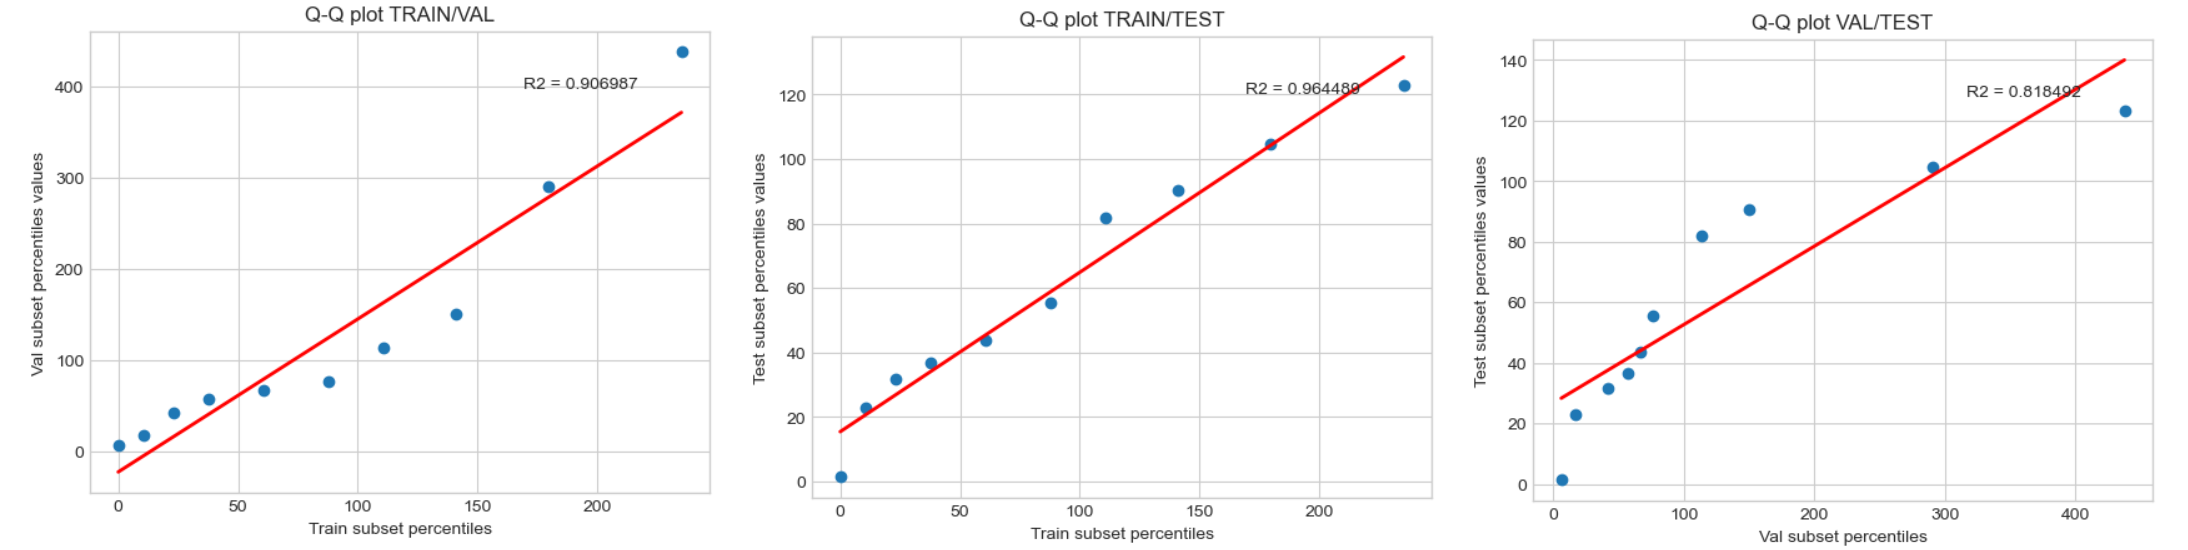

In [127]:
# # Total duration of all events in the selection of events (data_split_ML)
# tot_duration = data_split_ML['Event_duration'].sum()

# # Share of each event in the total duration of the dataset
# event_duration_share = data_split_ML['Event_duration']/tot_duration

In [129]:
# # Setting up the approx subset sizes

# share_test = 0.1
# share_val = 0.1
# share_train = 1 - share_test - share_val
# print(f'Dataset is split into TRAIN/VAL/TEST subsets as following: {int(share_train*100)}/{int(share_val*100)}/{int(share_test*100)} %')

<br>**Randomization of events that go into each subset is performed through shufflind list of indeces of data_split_ML**<br><br>

In [130]:
# seed_value = 42
# repetitions = 60000
# original_list_ind = rain_events_no_salt_no_gaps_ind.to_list()

# # Shuffling and making a list of new sublists
# shuffled_lists_ind = [random.sample(original_list_ind, len(original_list_ind)) for _ in range(repetitions)] if random.seed(seed_value) is None else None

<br>**Creating a randomized collection of different TRAIN/VAL/TEST subsets**<br><br>

In [131]:
# result_test, result_val, result_train = [], [], []

# for sublist_n in range(len(shuffled_lists_ind)):
#     test_set_ind, val_set_ind, train_set_ind = [], [], []
#     stacked_share_test, stacked_share_val, stacked_share_train = 0, 0, 0

#     for event_ind in shuffled_lists_ind[sublist_n]:
#         # Condition to keep the share of the events within close to assigned
#         if stacked_share_test < share_test:
#             stacked_share_test = stacked_share_test + event_duration_share[event_ind]
#             test_set_ind.append(event_ind)
#         elif stacked_share_val < share_val:
#             stacked_share_val = stacked_share_val + event_duration_share[event_ind]
#             val_set_ind.append(event_ind)
#         else:
#             stacked_share_train = stacked_share_train + event_duration_share[event_ind]
#             train_set_ind.append(event_ind)
        
#     result_test.append(test_set_ind)
#     result_val.append(val_set_ind)
#     result_train.append(train_set_ind)

<br>**Making datasets from these indeces and finding their percentiles**<br><br>

In [106]:
# %%time
# percentiles_lists_test = [[round(slice_dataset_ML(data_corr, subset)['Conduc_conduc_Avg'].quantile(perc), 2) for perc in np.arange(0, 1, 0.1)] for subset in result_test]
# percentiles_lists_val = [[round(slice_dataset_ML(data_corr, subset)['Conduc_conduc_Avg'].quantile(perc), 2) for perc in np.arange(0, 1, 0.1)] for subset in result_val]
# percentiles_lists_train = [[round(slice_dataset_ML(data_corr, subset)['Conduc_conduc_Avg'].quantile(perc), 2) for perc in np.arange(0, 1, 0.1)] for subset in result_train]

In [126]:
# %%time
# percentiles_lists_test = [[round(slice_dataset_ML(subset)['Turb_FNU_Avg'].quantile(perc), 2) for perc in np.arange(0, 1, 0.1)] for subset in result_test]
# percentiles_lists_val = [[round(slice_dataset_ML(subset)['Turb_FNU_Avg'].quantile(perc), 2) for perc in np.arange(0, 1, 0.1)] for subset in result_val]
# percentiles_lists_train = [[round(slice_dataset_ML(subset)['Turb_FNU_Avg'].quantile(perc), 2) for perc in np.arange(0, 1, 0.1)] for subset in result_train]

**One loop takes ~1s, which meeans 60000 loops will take (h):**

In [108]:
60000/60/60

16.666666666666668

<br>**Comparing distributions through linear regression R2**<br><br>

In [109]:
# def lin_r_r2(x, y):
#     # Convert lists to numpy arrays
#     x = np.array(x).reshape((-1, 1))
#     y = np.array(y)

#     # Create a linear regression model
#     model = LinearRegression()

#     # Fit the model
#     model.fit(x, y)

#     # Make predictions
#     y_pred = model.predict(x)

#     # Calculate R-squared
#     r2 = r2_score(y, y_pred)
    
#     return r2

In [110]:
# %%time
# # Finding r2 for 3 pairs of subsets
# r2 = np.array([[lin_r_r2(perc_train, perc_val) for perc_train, perc_val in zip(percentiles_lists_train, percentiles_lists_val)],
#                [lin_r_r2(perc_train, perc_test) for perc_train, perc_test in zip(percentiles_lists_train, percentiles_lists_test)],
#                [lin_r_r2(perc_val, perc_test) for perc_val, perc_test in zip(percentiles_lists_val, percentiles_lists_test)]]).T

<br>**Finding the best trinity as criteria of the best distribution of the events across the subsets**<br><br>
I will rank trinities with a score defined as following: avarage of R2 scores

In [111]:
# scores = pd.Series(np.mean(r2, axis=1)).sort_values(ascending=False)

# best_combination = scores.index[0]

# print(f'After running it for {repetitions} times')
# print(f'The best score: {scores.iloc[0]}, with the combination number: {best_combination}')

# print(f'Contributing r2 scores of trinity: {r2[best_combination]}')

After running it for 1000 times<br>
The best score: 0.9922603709831681, with the combination number: 675<br>
Contributing r2 scores of trinity: [0.99710373 0.98939612 0.99028126]

After running it for 100 times<br>
The best score: 0.976018, with the combination number: 96<br>
Contributing r2 scores of trinity: [0.96499715, 0.99100614, 0.97205123]

<br>**Saving results to the file, as it takes really long to run, so I can import it later, without running the whole ranking over again**<br><br>

In [98]:
# results = pd.DataFrame({'scores': scores,
#                         'ind_test': pd.Series(result_test).loc[scores.index],
#                         'percentiles_test': pd.Series(percentiles_lists_test).loc[scores.index],
#                         'ind_val': pd.Series(result_val).loc[scores.index],
#                         'percentiles_val': pd.Series(percentiles_lists_val).loc[scores.index],
#                         'ind_train': pd.Series(result_train).loc[scores.index],
#                         'percentiles_train': pd.Series(percentiles_lists_train).loc[scores.index]})
# # To save
# # results.to_csv(fr'prepared_datasets\events_distribution_across_datasets\distrib_score_{repetitions}iter_30s.csv')

In [117]:
# To load
# results = pd.read_csv('scores_test_val_train_60k.csv', index_col = 0)

<br>**Plotting correlations of the percentiles of the best combination**<br><br>

In [119]:
# # Percentiles lists for the best combination
# best_train_percentiles = np.array(ast.literal_eval(results['percentiles_train'][0]))
# best_val_percentiles = np.array(ast.literal_eval(results['percentiles_val'][0]))
# best_test_percentiles = np.array(ast.literal_eval(results['percentiles_test'][0]))

# # Create a linear regression model
# model = LinearRegression()

# # Create a figure and three subplots
# fig, axs = plt.subplots(1, 3, figsize=(30, 6))

# def plot_Q_Q(x, y, axis):
#     x = x.reshape((-1, 1))
#     # Fit the model
#     model.fit(x, y)

#     # Make predictions
#     y_pred = model.predict(x)

#     # Calculate R-squared
#     r_2 = r2_score(y, y_pred)

#     # Plot the original data
#     axs[axis].scatter(x, y)

#     # Plot the linear regression line
#     axs[axis].plot(x, y_pred, color='red', linewidth=2)

#     # Add R-squared to the plot
#     axs[axis].text(0.7, 0.9, f'R2 = {r_2:.6f}', transform=axs[axis].transAxes, fontsize=10, verticalalignment='top')

# # Add labels and a legend    
# axs[0].set_xlabel('TRAIN subset percentiles')
# axs[0].set_ylabel('VAL subset percentiles')
# axs[0].set_title('Q-Q plot TRAIN/VAL')

# axs[1].set_xlabel('TRAIN subset percentiles')
# axs[1].set_ylabel('TEST subset percentiles')
# axs[1].set_title('Q-Q plot TRAIN/TEST')

# axs[2].set_xlabel('VAL subset percentiles')
# axs[2].set_ylabel('TEST subset percentiles')
# axs[2].set_title('Q-Q plot VAL/TEST')

# plot_Q_Q(best_train_percentiles, best_val_percentiles, axis = 0)
# plot_Q_Q(best_train_percentiles, best_test_percentiles, axis = 1)
# plot_Q_Q(best_val_percentiles, best_test_percentiles, axis = 2)

<br>*Distributing indeces*

In [121]:
# # Indeces
# test_dataset_ind = sorted(ast.literal_eval(results.iloc[0]['ind_test']))
# val_dataset_ind = sorted(ast.literal_eval(results.iloc[0]['ind_val']))
# train_dataset_ind = sorted(ast.literal_eval(results.iloc[0]['ind_train']))
# # All indeces together
# tot_dataset_ind = data_split_ML.index

<br>*Making datasets*

In [134]:
# # I make lists of dfs instead of a single df, as I want to test my model on individual events
# test_datasets_list_multi = extended_datasets_ML(test_dataset_ind)
# val_datasets_list_multi = extended_datasets_ML(val_dataset_ind)
# train_datasets_list_multi = extended_datasets_ML(train_dataset_ind)
# # All events in one dataset
# tot_dataset_multi = extended_datasets_ML(tot_dataset_ind)

# print('Their shares of the total dataset (%):')
# round(len(np.concatenate(train_datasets_list_multi))/(len(np.concatenate(tot_dataset_multi)))*100, 2), round(len(np.concatenate(val_datasets_list_multi))/(len(np.concatenate(tot_dataset_multi)))*100, 2), round(len(np.concatenate(test_datasets_list_multi))/len(np.concatenate(tot_dataset_multi))*100, 2)

<br>*Saving datasets*

In [133]:
# # Creating a dictionary to hold all datasets
# multipar_datasets = {
#     'test_datasets': test_datasets_list_multi,
#     'val_datasets': val_datasets_list_multi,
#     'train_datasets': train_datasets_list_multi
# }

# # Save the dictionary to a single file
# with open('multipar_datasets_resampled.pkl', 'wb') as f:
#     pickle.dump(multipar_datasets, f)